In [263]:
import pandas as pd
import numpy as np

In [264]:

import os

In [38]:
os.getcwd()

'C:\\Users\\marta'

In [265]:
ruta_2021 = r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\raw\demandantes_samur_pc_2021.xlsx"
ruta_2022 = r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\raw\demandantes_samur_pc_2022.xlsx"
ruta_2023 = r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\raw\demandantes_samur_pc_2023.xlsx"

In [40]:
df_2021 = pd.read_excel(ruta_2021)
df_2022 = pd.read_excel(ruta_2022)
df_2023 = pd.read_excel(ruta_2023)

In [266]:
print("2021:", df_2021.shape)
print("2022:", df_2022.shape)
print("2023:", df_2023.shape)

2021: (11013, 31)
2022: (4237, 31)
2023: (15227, 31)


In [267]:
from pathlib import Path

docs = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\docs")
interim = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\interim")
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
outputs = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\outputs")
raw = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\raw")

In [268]:
def resumen_variables(df, year):
    out = pd.DataFrame({
        "variable_original": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "pct_null": df.isna().mean().values * 100,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
        "sample_values": [list(df[c].dropna().astype(str).unique()[:5]) for c in df.columns],
        "year": year
    })
    return out

schema_2021 = resumen_variables(df_2021, 2021)
schema_2022 = resumen_variables(df_2022, 2022)
schema_2023 = resumen_variables(df_2023, 2023)

schema_all = pd.concat([schema_2021, schema_2022, schema_2023], ignore_index=True)
schema_all.to_excel(docs / "inventario_variables.xlsx", index=False)

In [269]:
#variable_original: Nombre original de la columna en el Excel.
#dtype: Tipo de dato detectado por pandas.(object/float64/int64)
#pct_null: % nulos de columna
#n_unique:Número de valores distintos que tiene esa variable.
#sample_values: Lista con algunos valores de ejemplo de esa columna.
#year: Año del dataset al que pertenece esa variable.


In [270]:
#Este análisis me servirá para ebtender la estructura real de los datos, detectar problemas (columnas con muchos nulos, tipos mal leidos, variables con demasiados valores extraños...), comparar los 3 años y empezar el diccionario de datos.

In [271]:
schema_all

,variable_original,dtype,pct_null,n_unique,sample_values,year
0,id_registro,int64,0.000000,11013,"[5511425, 5511642, 5511645, 5513141, 5511718]",2021
1,fecha_inicio,object,0.000000,11013,"[01/01/2021T01:37:31.237000+0100, 01/01/2021T0...",2021
2,fecha_actualizacion,object,0.000000,11013,"[01/01/2021T01:39:42.017024+0100, 01/01/2021T0...",2021
3,tipo_dispositivo,object,0.000000,3,"[Mobile, Desktop, Tablet]",2021
4,asistencia_para_si_mismo,object,0.000000,2,"[NO, SÍ]",2021
...,...,...,...,...,...,...
88,se_quedo_en_el_lugar,object,20.227228,2,"[Si, No]",2023
89,satisfaccion_global,float64,14.533395,10,"[10.0, 9.0, 1.0, 6.0, 8.0]",2023
90,cree_necesaria_formacion_ciudadania,object,13.311880,2,"[Si, No]",2023
91,genero,object,23.786695,3,"[Femenino, Masculino, Otro]",2023


In [272]:
#ESQUEMA CANÓNICO: voy a renombrar las variables de las bbdd

In [273]:
rename_map_2021 = {
    "id": "id_registro",
    "start_date": "fecha_inicio",
    "updated_date": "fecha_actualizacion",
    "completed": "completado",
    "device_type": "tipo_dispositivo",
    "2_La asistencia sanitaria solicitada ¿Fue para atenderle a usted?": "asistencia_para_si_mismo",
    "3_¿ Desde dónde realizó la llamada?__Vía pública": "lugar_via_publica",
    "3_¿ Desde dónde realizó la llamada?__Lugar de trabajo": "lugar_trabajo",
    "3_¿ Desde dónde realizó la llamada?__Domicilio": "lugar_domicilio",
    "3_¿ Desde dónde realizó la llamada?__Transporte público (Metro, taxi, autobús...) ": "lugar_transporte_publico",
    "3_¿ Desde dónde realizó la llamada?__Institución pública no sanitaria": "lugar_institucion_publica_no_sanitaria",
    "3_¿ Desde dónde realizó la llamada?__Centro de enseñanza": "lugar_centro_ensenanza",
    "3_¿ Desde dónde realizó la llamada?__Centro sanitario": "lugar_centro_sanitario",
    "3_¿ Desde dónde realizó la llamada?__Local comercial (Tiendas, bares, restaurantes...)": "lugar_local_comercial",
    "3_¿ Desde dónde realizó la llamada?__Otro": "lugar_otro",
    "4_Tras contactar con el 112 para solicitar nuestra ayuda, ¿recibió un mensaje corto (SMS) en su teléfono confirmando nuestra activación y el lugar del incidente?": "recibio_sms_confirmacion",
    "5_¿Le fue útil la información recibida en el mensaje?": "sms_util",
    "6_¿Cuánto tiempo tardamos en atender su llamada? Indique su percepción en segundos. Si piensa que fueron más de 60 segundos, puede comunicarlo en el apartado de Observaciones": "tiempo_percibido_atencion_seg",
    "7_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Amabilidad e interés": "op1_amabilidad",
    "7_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Rapidez y agilidad": "op1_rapidez",
    "8_¿Contactamos con usted tras su llamada para confirmar los datos?": "hubo_segundo_contacto",
    "9_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Amabilidad e interés": "op2_amabilidad",
    "9_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Rapidez y agilidad": "op2_rapidez",
    "10_Con respecto al tiempo que transcurrió desde que realizó la llamada hasta la llegada del equipo sanitario, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".": "satisfaccion_tiempo_llegada",
    "11_¿Cuánto tiempo calcula que transcurrió hasta que llegó la asistencia?Indique el tiempo en minutos.Si piensa que fueron más de 20 minutos, puede comunicarlo en el apartado de Observaciones": "tiempo_percibido_llegada_min",
    "12_Respecto a la información que usted facilitó al operador, ¿cree que es necesario realizar cursos de formación a la ciudadanía para mejorar este aspecto? ": "cree_necesaria_formacion_ciudadania",
    "13_Con respecto a la gestión global de la llamada por nuestros operadores telefónicos, ¿cuál es su grado de satisfacción?Valorede 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".": "satisfaccion_global",
    "15_Necesitamos algunos datos demográficos (género y edad) que nos permitan ajustarnos a las necesidades de los diferentes perfiles de personas que demandan nuestra asistencia.": "genero",
    "16_Indique su edad en números": "edad",
    "url_parameters__year": "anio_url"
}

In [274]:
rename_map_2022 = {
    "id": "id_registro",
    "start_date": "fecha_inicio",
    "updated_date": "fecha_actualizacion",
    "survey_id": "id_encuesta",
    "email": "email",
    "status": "estado_respuesta",
    "device_type": "tipo_dispositivo",
    "contact_id": "id_contacto",
    "contact_list_id": "id_lista_contacto",
    "1_None": "var_aux_1_none",
    "2_La asistencia sanitaria solicitada ¿Fue para atenderle a usted?": "asistencia_para_si_mismo",
    "3_¿ Desde dónde realizó la llamada?__Vía pública": "lugar_via_publica",
    "3_¿ Desde dónde realizó la llamada?__Lugar de trabajo": "lugar_trabajo",
    "3_¿ Desde dónde realizó la llamada?__Domicilio": "lugar_domicilio",
    "3_¿ Desde dónde realizó la llamada?__Transporte público (Metro, taxi, autobús...) ": "lugar_transporte_publico",
    "3_¿ Desde dónde realizó la llamada?__Institución pública no sanitaria": "lugar_institucion_publica_no_sanitaria",
    "3_¿ Desde dónde realizó la llamada?__Centro de enseñanza": "lugar_centro_ensenanza",
    "3_¿ Desde dónde realizó la llamada?__Centro sanitario": "lugar_centro_sanitario",
    "3_¿ Desde dónde realizó la llamada?__Local comercial (Tiendas, bares, restaurantes...)": "lugar_local_comercial",
    "3_¿ Desde dónde realizó la llamada?__Otro": "lugar_otro",
    "4_Tras contactar con el 112 para solicitar nuestra ayuda, ¿recibió un mensaje corto (SMS) en su teléfono confirmando nuestra activación y el lugar del incidente?": "recibio_sms_confirmacion",
    "5_¿Le fue útil la información recibida en el mensaje?": "sms_util",
    "6_¿Cuánto tiempo tardamos en atender su llamada? Indique su percepción en segundos. Si piensa que fueron más de 60 segundos, puede comunicarlo en el apartado de Observaciones": "tiempo_percibido_atencion_seg",
    "Tiempo en atender llamada": "tiempo_atencion_aux",
    "7_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Amabilidad e interés": "op1_amabilidad",
    "7_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Rapidez y agilidad": "op1_rapidez",
    "8_¿Contactamos con usted tras su llamada para confirmar los datos?": "hubo_segundo_contacto",
    "9_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Amabilidad e interés": "op2_amabilidad",
    "9_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".__Rapidez y agilidad": "op2_rapidez",
    "10_Con respecto al tiempo que transcurrió desde que realizó la llamada hasta la llegada del equipo sanitario, ¿cuál es su grado de satisfacción?Valore de 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".": "satisfaccion_tiempo_llegada",
    "11_¿Cuánto tiempo calcula que transcurrió hasta que llegó la asistencia?Indique el tiempo en minutos.Si piensa que fueron más de 20 minutos, puede comunicarlo en el apartado de Observaciones": "tiempo_percibido_llegada_min",
    "se quedó en el lugar": "se_quedo_en_el_lugar",
    "Con respecto al tiempo grado de satisfaccion": "satisfaccion_tiempo_llegada_aux",
    "Cuanto tiempo transcurrido hasta la llegada del equipo sanitario": "tiempo_llegada_aux_1",
    "Diganos cuanto tiempo transcurrio hasta la llegada del equipo sanitario": "tiempo_llegada_aux_2",
    "13_Con respecto a la gestión global de la llamada por nuestros operadores telefónicos, ¿cuál es su grado de satisfacción?Valorede 1 a 10, siendo 1 \"muy bajo\" y 10 \"muy alto\".": "satisfaccion_global",
    "12_Respecto a la información que usted facilitó al operador, ¿cree que es necesario realizar cursos de formación a la ciudadanía para mejorar este aspecto? ": "cree_necesaria_formacion_ciudadania",
    "15_Necesitamos algunos datos demográficos (género y edad) que nos permitan ajustarnos a las necesidades de los diferentes perfiles de personas que demandan nuestra asistencia.": "genero",
    "16_Indique su edad en números": "edad"
}

In [275]:
rename_map_2023 = {
    "id": "id_registro",
    "start_date": "fecha_inicio",
    "updated_date": "fecha_actualizacion",
    "survey_id": "id_encuesta",
    "status": "estado_respuesta",
    "device_type": "tipo_dispositivo",
    "2_La asistencia sanitaria solicitada ¿Fue para atenderle a usted?": "asistencia_para_si_mismo",
    "3_¿ Desde dónde realizó la llamada?__Vía pública": "lugar_via_publica",
    "3_¿ Desde dónde realizó la llamada?__Lugar de trabajo": "lugar_trabajo",
    "3_¿ Desde dónde realizó la llamada?__Domicilio": "lugar_domicilio",
    "3_¿ Desde dónde realizó la llamada?__Transporte público (Metro, taxi, autobús...) ": "lugar_transporte_publico",
    "3_¿ Desde dónde realizó la llamada?__Institución pública no sanitaria": "lugar_institucion_publica_no_sanitaria",
    "3_¿ Desde dónde realizó la llamada?__Centro de enseñanza": "lugar_centro_ensenanza",
    "3_¿ Desde dónde realizó la llamada?__Centro sanitario": "lugar_centro_sanitario",
    "3_¿ Desde dónde realizó la llamada?__Local comercial (Tiendas, bares, restaurantes...)": "lugar_local_comercial",
    "3_¿ Desde dónde realizó la llamada?__Otro": "lugar_otro",
    "4_Tras contactar con el 112 para solicitar nuestra ayuda, ¿recibió un mensaje corto (SMS) en su teléfono confirmando nuestra activación y el lugar del incidente?": "recibio_sms_confirmacion",
    "5_¿Le fue útil la información recibida en el mensaje?": "sms_util",
    "6_¿Cuánto tiempo tardamos en atender su llamada? Indique su percepción en segundos.": "tiempo_percibido_atencion_seg",
    "7_Díganos cuánto tiempo tardamos en atender su llamada": "tiempo_atencion_tramo",
    "8_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?__Amabilidad e interés": "op1_amabilidad",
    "8_Con respecto a la primera persona que atendió la llamada, ¿cuál es su grado de satisfacción?__Rapidez y agilidad": "op1_rapidez",
    "9_¿Contactamos con usted tras su llamada para confirmar los datos?": "hubo_segundo_contacto",
    "10_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?__Amabilidad e interés": "op2_amabilidad",
    "10_Con respecto a la segunda persona que atendió la llamada, ¿cuál es su grado de satisfacción?__Rapidez y agilidad": "op2_rapidez",
    "11_Con respecto al tiempo que transcurrió desde que realizó la llamada hasta la llegada del equipo sanitario, ¿cuál es su grado de satisfacción?": "satisfaccion_tiempo_llegada",
    "12_¿Cuanto tiempo calcula que pasó hasta que llegó la asistencia?": "tiempo_percibido_llegada_min",
    "13_Díganos cuánto tiempo pasó hasta que llegó la asistencia": "tiempo_llegada_tramo",
    "14_¿Se quedó en el lugar hasta que llegó la asistencia?": "se_quedo_en_el_lugar",
    "18_Teniendo en cuenta todos los aspectos en la gestión de la llamada por nuestros operadores ¿cuál es su grado de satisfacción global?": "satisfaccion_global",
    "19_¿Cree que es necesario realizar cursos de formación a la ciudadanía para mejorar la comunicación con los operadores y dar la información sobre el suceso de forma adecuada? ": "cree_necesaria_formacion_ciudadania",
    "21_Necesitamos algunos datos demográficos (género y edad) que nos permitan ajustarnos a las necesidades de los diferentes perfiles de personas que demandan nuestra asistencia.": "genero",
    "22_Indique su edad en números": "edad"
}

In [276]:
df_2021 = df_2021.rename(columns=rename_map_2021)
df_2022 = df_2022.rename(columns=rename_map_2022)
df_2023 = df_2023.rename(columns=rename_map_2023)

In [277]:
print("Columnas 2021 renombradas:")
print(df_2021.columns.tolist())

print("\nColumnas 2022 renombradas:")
print(df_2022.columns.tolist())

print("\nColumnas 2023 renombradas:")
print(df_2023.columns.tolist())

Columnas 2021 renombradas:
['id_registro', 'fecha_inicio', 'fecha_actualizacion', 'tipo_dispositivo', 'asistencia_para_si_mismo', 'lugar_via_publica', 'lugar_trabajo', 'lugar_domicilio', 'lugar_transporte_publico', 'lugar_institucion_publica_no_sanitaria', 'lugar_centro_ensenanza', 'lugar_centro_sanitario', 'lugar_local_comercial', 'lugar_otro', 'recibio_sms_confirmacion', 'sms_util', 'tiempo_percibido_atencion_seg', 'tiempo_atencion_tramo', 'op1_amabilidad', 'op1_rapidez', 'hubo_segundo_contacto', 'op2_amabilidad', 'op2_rapidez', 'satisfaccion_tiempo_llegada', 'tiempo_percibido_llegada_min', 'tiempo_llegada_tramo', 'se_quedo_en_el_lugar', 'satisfaccion_global', 'cree_necesaria_formacion_ciudadania', 'genero', 'edad']

Columnas 2022 renombradas:
['id_registro', 'fecha_inicio', 'fecha_actualizacion', 'tipo_dispositivo', 'asistencia_para_si_mismo', 'lugar_via_publica', 'lugar_trabajo', 'lugar_domicilio', 'lugar_transporte_publico', 'lugar_institucion_publica_no_sanitaria', 'lugar_centro_

In [278]:
#Se definió un esquema canónico de variables para homogeneizar la estructura de los cuestionarios de 2021, 2022 y 2023. Este proceso permitió unificar nombres de variables equivalentes, preservar la trazabilidad respecto al cuestionario original y facilitar la integración posterior en un único dataset analítico.

In [279]:
#var de identificación: 
#1 id_registro
#2 fecha_inicio
#3 fecha_actualizacion
#4 completado
#5 estado_respuesta
#6 tipo_dispositivo
#7 id_encuesta
#8 id_contacto
#9 id_lista_contacto
#10 email
#11 anio_url
#12 var_aux_1_none

In [280]:
#var sustantivas (núcleo) del análisis: 
#1 asistencia_para_si_mismo
#2 recibio_sms_confirmacion
#3 tiempo_percibido_atencion_seg
#4 tiempo_atencion_tramo
#5 op1_amabilidad
#6 op1_rapidez
#7 hubo_segundo_contacto
#8 op2_amabilidad
#9 op2_rapidez
#9 satisfaccion_tiempo_llegada
#10 tiempo_percibido_llegada_min
#11 tiempo_llegada_tramo
#12 se_quedo_en_el_lugar
#13 satisfaccion_global
#14 cree_necesaria_formacion_ciudadania
#15 genero
#16 edad

In [410]:
#Variables del lugar de llamada (más tarde las fusionarÉ en una sol)

#1 lugar_via_publica
#2 lugar_trabajo
#3 lugar_domicilio
#4 lugar_transporte_publico
#5 lugar_institucion_publica_no_sanitaria
#6 lugar_centro_ensenanza
#7 lugar_centro_sanitario
#8 lugar_local_comercial
#9 lugar_otro


In [62]:
#Variables auxiliares que probablemente luego eliminaré
#1 tiempo_atencion_aux
#2 satisfaccion_tiempo_llegada_aux
#3 tiempo_llegada_aux_1
#4 tiempo_llegada_aux_2

In [63]:
#crear lista de columnas para conservar en el dataset analítico

In [64]:
columnas_base = [
    "id_registro",
    "fecha_inicio",
    "fecha_actualizacion",
    "tipo_dispositivo",
    "asistencia_para_si_mismo",
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro",
    "recibio_sms_confirmacion",
    "sms_util",
    "tiempo_percibido_atencion_seg",
    "tiempo_atencion_tramo",
    "op1_amabilidad",
    "op1_rapidez",
    "hubo_segundo_contacto",
    "op2_amabilidad",
    "op2_rapidez",
    "satisfaccion_tiempo_llegada",
    "tiempo_percibido_llegada_min",
    "tiempo_llegada_tramo",
    "se_quedo_en_el_lugar",
    "satisfaccion_global",
    "cree_necesaria_formacion_ciudadania",
    "genero",
    "edad"
]

In [65]:
for col in columnas_base:
    if col not in df_2021.columns:
        df_2021[col] = pd.NA
    if col not in df_2022.columns:
        df_2022[col] = pd.NA
    if col not in df_2023.columns:
        df_2023[col] = pd.NA

In [66]:
df_2021 = df_2021[columnas_base].copy()
df_2022 = df_2022[columnas_base].copy()
df_2023 = df_2023[columnas_base].copy()

In [67]:
#para que en los 3 años tengan todos exactanmente las mismas columna, aunque alguna no exista en todos

In [68]:
#VAR PRINCIPAL DE TIEMPO DE ATENCIÓN: tiempo_percibido_atencion_seg
#VAR PRINCIAP DE TIEMPO DE LLEGADA: tiempo_percibido_llegada_min
#VAR APOYO PARA 2023: tiempo_atencion_tramo y tiempo_llegada_tramo
#VARIABLES _AUX DE 2022: (A revisar, no son núcleo principal)
#VAR PRINCIPAL OBJETIVO: satisfaccion_global
#VAR SECUNDARIA RELEVANTE: satisfaccion_tiempo_llegada
#VAR PREDICTORAS: op1_amabilidad, op1_rapidez, op2_amabilidad, op2_rapidez
#VAR LUGAR_*: Se convertirá en una sola variable: lugar_llamada

In [69]:
df_2021.columns.tolist()

['id_registro',
 'fecha_inicio',
 'fecha_actualizacion',
 'tipo_dispositivo',
 'asistencia_para_si_mismo',
 'lugar_via_publica',
 'lugar_trabajo',
 'lugar_domicilio',
 'lugar_transporte_publico',
 'lugar_institucion_publica_no_sanitaria',
 'lugar_centro_ensenanza',
 'lugar_centro_sanitario',
 'lugar_local_comercial',
 'lugar_otro',
 'recibio_sms_confirmacion',
 'sms_util',
 'tiempo_percibido_atencion_seg',
 'tiempo_atencion_tramo',
 'op1_amabilidad',
 'op1_rapidez',
 'hubo_segundo_contacto',
 'op2_amabilidad',
 'op2_rapidez',
 'satisfaccion_tiempo_llegada',
 'tiempo_percibido_llegada_min',
 'tiempo_llegada_tramo',
 'se_quedo_en_el_lugar',
 'satisfaccion_global',
 'cree_necesaria_formacion_ciudadania',
 'genero',
 'edad']

In [70]:
#Estos pasos previos me servirán para tener una única tabla coherente, no 3 cuestionarios distintos pegados. 
#De esta manera tendre la homologación de variables entre años

In [72]:
#PASO 6: RESOLUCIÓN DE VARIABLES MULTIRESPUESTA DE "LUGAR DE LLAMADA" 
#convertirlo a una sola variable categórica

In [73]:
lugar_cols = {
    "3_¿ Desde dónde realizó la llamada?__Vía pública": "via_publica",
    "3_¿ Desde dónde realizó la llamada?__Lugar de trabajo": "lugar_trabajo",
    "3_¿ Desde dónde realizó la llamada?__Domicilio": "domicilio",
    "3_¿ Desde dónde realizó la llamada?__Transporte público (Metro, taxi, autobús...) ": "transporte_publico",
    "3_¿ Desde dónde realizó la llamada?__Institución pública no sanitaria": "institucion_publica_no_sanitaria",
    "3_¿ Desde dónde realizó la llamada?__Centro de enseñanza": "centro_ensenanza",
    "3_¿ Desde dónde realizó la llamada?__Centro sanitario": "centro_sanitario",
    "3_¿ Desde dónde realizó la llamada?__Local comercial (Tiendas, bares, restaurantes...)": "local_comercial",
    "3_¿ Desde dónde realizó la llamada?__Otro": "otro"
}

def construir_lugar_llamada(df, cols_map):
    df = df.copy()
    cols_existentes = [c for c in cols_map if c in df.columns]
    
    def detectar(row):
        activos = [cols_map[c] for c in cols_existentes if pd.notna(row[c])]
        if len(activos) == 1:
            return activos[0]
        elif len(activos) == 0:
            return np.nan
        else:
            return "multiple"
    
    df["lugar_llamada"] = df.apply(detectar, axis=1)
    return df

In [79]:
df = df.copy()

In [81]:
import pandas as pd
import numpy as np

lugar_cols = {
    "lugar_via_publica": "via_publica",
    "lugar_trabajo": "lugar_trabajo",
    "lugar_domicilio": "domicilio",
    "lugar_transporte_publico": "transporte_publico",
    "lugar_institucion_publica_no_sanitaria": "institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza": "centro_ensenanza",
    "lugar_centro_sanitario": "centro_sanitario",
    "lugar_local_comercial": "local_comercial",
    "lugar_otro": "otro"
}

def construir_lugar_llamada(df, cols_map):
    df = df.copy()
    cols_existentes = [c for c in cols_map if c in df.columns]

    def detectar(row):
        activos = [cols_map[c] for c in cols_existentes if pd.notna(row[c])]
        if len(activos) == 1:
            return activos[0]
        elif len(activos) == 0:
            return np.nan
        else:
            return "multiple"

    df["lugar_llamada"] = df.apply(detectar, axis=1)
    return df

In [84]:
df_2021_clean = df_2021.copy()
df_2022_clean = df_2022.copy()
df_2023_clean = df_2023.copy()

In [85]:
df_2021_clean = construir_lugar_llamada(df_2021_clean, lugar_cols)
df_2022_clean = construir_lugar_llamada(df_2022_clean, lugar_cols)
df_2023_clean = construir_lugar_llamada(df_2023_clean, lugar_cols)

In [86]:
print(df_2021_clean["lugar_llamada"].value_counts(dropna=False))
print(df_2022_clean["lugar_llamada"].value_counts(dropna=False))
print(df_2023_clean["lugar_llamada"].value_counts(dropna=False))

lugar_llamada
via_publica                         7378
lugar_trabajo                        991
domicilio                            909
local_comercial                      554
otro                                 387
multiple                             292
transporte_publico                   270
centro_ensenanza                     124
institucion_publica_no_sanitaria      74
centro_sanitario                      34
Name: count, dtype: int64
lugar_llamada
via_publica                         2743
lugar_trabajo                        435
local_comercial                      283
domicilio                            219
transporte_publico                   150
multiple                             145
otro                                 127
centro_ensenanza                      86
institucion_publica_no_sanitaria      28
centro_sanitario                      21
Name: count, dtype: int64
lugar_llamada
via_publica                         9805
lugar_trabajo                       1664
loca

In [87]:
df_2021_clean = construir_lugar_llamada(df_2021_clean, lugar_cols)
df_2022_clean = construir_lugar_llamada(df_2022_clean, lugar_cols)
df_2023_clean = construir_lugar_llamada(df_2023_clean, lugar_cols)

In [88]:
df_2021_clean["lugar_llamada"].value_counts(dropna=False)
df_2022_clean["lugar_llamada"].value_counts(dropna=False)
df_2023_clean["lugar_llamada"].value_counts(dropna=False)

lugar_llamada
via_publica                         9805
lugar_trabajo                       1664
local_comercial                     1008
domicilio                            819
transporte_publico                   538
otro                                 506
multiple                             449
centro_ensenanza                     255
institucion_publica_no_sanitaria     132
centro_sanitario                      46
NaN                                    5
Name: count, dtype: int64

In [89]:
lugar_cols = {
    "3_¿ Desde dónde realizó la llamada?__Vía pública": "via_publica",
    "3_¿ Desde dónde realizó la llamada?__Lugar de trabajo": "lugar_trabajo",
    "3_¿ Desde dónde realizó la llamada?__Domicilio": "domicilio",
    "3_¿ Desde dónde realizó la llamada?__Transporte público (Metro, taxi, autobús...) ": "transporte_publico",
    "3_¿ Desde dónde realizó la llamada?__Institución pública no sanitaria": "institucion_publica_no_sanitaria",
    "3_¿ Desde dónde realizó la llamada?__Centro de enseñanza": "centro_ensenanza",
    "3_¿ Desde dónde realizó la llamada?__Centro sanitario": "centro_sanitario",
    "3_¿ Desde dónde realizó la llamada?__Local comercial (Tiendas, bares, restaurantes...)": "local_comercial",
    "3_¿ Desde dónde realizó la llamada?__Otro": "otro"
}

def construir_lugar_llamada(df, cols_map):
    df = df.copy()
    cols_existentes = [c for c in cols_map if c in df.columns]
    
    def detectar(row):
        activos = [cols_map[c] for c in cols_existentes if pd.notna(row[c])]
        if len(activos) == 1:
            return activos[0]
        elif len(activos) == 0:
            return np.nan
        else:
            return "multiple"
    
    df["lugar_llamada"] = df.apply(detectar, axis=1)
    return df

In [90]:
print("2021")
print(df_2021_clean["lugar_llamada"].value_counts(dropna=False))

print("\n2022")
print(df_2022_clean["lugar_llamada"].value_counts(dropna=False))

print("\n2023")
print(df_2023_clean["lugar_llamada"].value_counts(dropna=False))

2021
lugar_llamada
via_publica                         7378
lugar_trabajo                        991
domicilio                            909
local_comercial                      554
otro                                 387
multiple                             292
transporte_publico                   270
centro_ensenanza                     124
institucion_publica_no_sanitaria      74
centro_sanitario                      34
Name: count, dtype: int64

2022
lugar_llamada
via_publica                         2743
lugar_trabajo                        435
local_comercial                      283
domicilio                            219
transporte_publico                   150
multiple                             145
otro                                 127
centro_ensenanza                      86
institucion_publica_no_sanitaria      28
centro_sanitario                      21
Name: count, dtype: int64

2023
lugar_llamada
via_publica                         9805
lugar_trabajo               

#los valores "multiple" significan que en 1 misma fila hay más de una categoría marcada, lo que significaría inchoerencia entre los datos porque el solicitante no puede estar en 2 lugares a l vez. 
#Puede ser debido a repsuestas multiseleccion reales, errores del formulario o marcas residuales

In [91]:
print("2021 multiple:", (df_2021_clean["lugar_llamada"] == "multiple").sum())
print("2022 multiple:", (df_2022_clean["lugar_llamada"] == "multiple").sum())
print("2023 multiple:", (df_2023_clean["lugar_llamada"] == "multiple").sum())

2021 multiple: 292
2022 multiple: 145
2023 multiple: 449


In [92]:
cols_lugar = [
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro",
    "lugar_llamada"
]

df_2021_clean.loc[df_2021_clean["lugar_llamada"] == "multiple", cols_lugar].head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,lugar_llamada
211,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
216,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,multiple
296,NaN,NaN,Domicilio,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
310,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
319,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,multiple
365,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
369,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,multiple
456,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multiple
469,NaN,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,others,multiple
470,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple


In [93]:
cols_lugar = [
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro",
    "lugar_llamada"
]

df_2022_clean.loc[df_2022_clean["lugar_llamada"] == "multiple", cols_lugar].head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,lugar_llamada
27,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
28,NaN,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,Hostal,multiple
37,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
61,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
81,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
122,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Parq,multiple
166,NaN,Lugar de trabajo,NaN,NaN,Institución pública no sanitaria,NaN,NaN,NaN,NaN,multiple
176,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,⁸,multiple
233,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
275,NaN,Lugar de trabajo,NaN,NaN,NaN,Centro de enseñanza,NaN,NaN,NaN,multiple


In [94]:
cols_lugar = [
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro",
    "lugar_llamada"
]

df_2023_clean.loc[df_2023_clean["lugar_llamada"] == "multiple", cols_lugar].head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,lugar_llamada
76,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,En la calle Cava San Miguel n3,multiple
80,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,multiple
83,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
88,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multiple
89,NaN,NaN,NaN,NaN,NaN,Centro de enseñanza,NaN,NaN,Lk,multiple
93,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
104,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
118,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
147,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Parque Olof Palme. Calle San Magín, 21",multiple
156,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple


In [ ]:
#las respuestas marcadas en algun lugar y a su vez en la casilla de "otro" vamos a CAMBIARLAS para que
#ignore lugar_otro cuando ya haya una categoiría principal

In [96]:
df_2021_multiple = df_2021_clean.loc[
    df_2021_clean["lugar_llamada"] == "multiple",
    cols_lugar[:-1]
].copy()

df_2021_multiple["n_campos_rellenos"] = df_2021_multiple.notna().sum(axis=1)
df_2021_multiple.head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,n_campos_rellenos
211,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
216,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,2
296,NaN,NaN,Domicilio,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
310,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,2
319,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,2
365,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
369,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,2
456,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
469,NaN,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,others,2
470,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,2


In [97]:
df_2022_multiple = df_2022_clean.loc[
    df_2022_clean["lugar_llamada"] == "multiple",
    cols_lugar[:-1]
].copy()

df_2022_multiple["n_campos_rellenos"] = df_2022_multiple.notna().sum(axis=1)
df_2022_multiple.head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,n_campos_rellenos
27,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,2
28,NaN,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,Hostal,2
37,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
61,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
81,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
122,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Parq,2
166,NaN,Lugar de trabajo,NaN,NaN,Institución pública no sanitaria,NaN,NaN,NaN,NaN,2
176,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,⁸,2
233,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,2
275,NaN,Lugar de trabajo,NaN,NaN,NaN,Centro de enseñanza,NaN,NaN,NaN,2


In [98]:
df_2023_multiple = df_2023_clean.loc[
    df_2023_clean["lugar_llamada"] == "multiple",
    cols_lugar[:-1]
].copy()

df_2023_multiple["n_campos_rellenos"] = df_2023_multiple.notna().sum(axis=1)
df_2023_multiple.head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,n_campos_rellenos
76,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,En la calle Cava San Miguel n3,2
80,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,2
83,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
88,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
89,NaN,NaN,NaN,NaN,NaN,Centro de enseñanza,NaN,NaN,Lk,2
93,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
104,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2
118,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,2
147,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Parque Olof Palme. Calle San Magín, 21",2
156,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,2


In [99]:
import pandas as pd
import numpy as np

lugar_cols = {
    "lugar_via_publica": "via_publica",
    "lugar_trabajo": "lugar_trabajo",
    "lugar_domicilio": "domicilio",
    "lugar_transporte_publico": "transporte_publico",
    "lugar_institucion_publica_no_sanitaria": "institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza": "centro_ensenanza",
    "lugar_centro_sanitario": "centro_sanitario",
    "lugar_local_comercial": "local_comercial",
    "lugar_otro": "otro"
}

def construir_lugar_llamada(df, cols_map):
    df = df.copy()
    cols_existentes = [c for c in cols_map if c in df.columns]

    def tiene_valor(x):
        if pd.isna(x):
            return False
        if isinstance(x, str) and x.strip() == "":
            return False
        return True

    def detectar(row):
        activos = [c for c in cols_existentes if tiene_valor(row[c])]
        activos_principales = [c for c in activos if c != "lugar_otro"]

        if len(activos_principales) == 1:
            return cols_map[activos_principales[0]]
        elif len(activos_principales) > 1:
            return "multiple"
        elif len(activos) == 1 and activos[0] == "lugar_otro":
            return "otro"
        else:
            return np.nan

    df["lugar_llamada"] = df.apply(detectar, axis=1)
    return df

In [100]:
df_2021_clean = construir_lugar_llamada(df_2021_clean, lugar_cols)
df_2022_clean = construir_lugar_llamada(df_2022_clean, lugar_cols)
df_2023_clean = construir_lugar_llamada(df_2023_clean, lugar_cols)

In [101]:
print("2021")
print(df_2021_clean["lugar_llamada"].value_counts(dropna=False))

print("\n2022")
print(df_2022_clean["lugar_llamada"].value_counts(dropna=False))

print("\n2023")
print(df_2023_clean["lugar_llamada"].value_counts(dropna=False))

2021
lugar_llamada
via_publica                         7417
lugar_trabajo                       1003
domicilio                            912
local_comercial                      557
otro                                 387
transporte_publico                   274
multiple                             224
centro_ensenanza                     124
institucion_publica_no_sanitaria      80
centro_sanitario                      35
Name: count, dtype: int64

2022
lugar_llamada
via_publica                         2756
lugar_trabajo                        436
local_comercial                      283
domicilio                            222
transporte_publico                   151
otro                                 127
multiple                             124
centro_ensenanza                      87
institucion_publica_no_sanitaria      30
centro_sanitario                      21
Name: count, dtype: int64

2023
lugar_llamada
via_publica                         9858
lugar_trabajo               

In [103]:
#si solo está rellena lugar_via_publica → via_publica
#si está lugar_via_publica y también lugar_otro → via_publica
#si solo está lugar_otro → otro
#si hay dos categorías principales a la vez, por ejemplo lugar_domicilio y lugar_trabajo → multiple

In [104]:
# PASO 7 NORMALIZAR TIPOS Y CATEGORÍAS

In [106]:
#copia de seguridad por si algo sale mal
df_2021_norm = df_2021_clean.copy()
df_2022_norm = df_2022_clean.copy()
df_2023_norm = df_2023_clean.copy()

In [107]:
# veo que columnas tengo ahora
print("2021")
print(df_2021_norm.columns.tolist())

print("\n2022")
print(df_2022_norm.columns.tolist())

print("\n2023")
print(df_2023_norm.columns.tolist())

2021
['id_registro', 'fecha_inicio', 'fecha_actualizacion', 'tipo_dispositivo', 'asistencia_para_si_mismo', 'lugar_via_publica', 'lugar_trabajo', 'lugar_domicilio', 'lugar_transporte_publico', 'lugar_institucion_publica_no_sanitaria', 'lugar_centro_ensenanza', 'lugar_centro_sanitario', 'lugar_local_comercial', 'lugar_otro', 'recibio_sms_confirmacion', 'sms_util', 'tiempo_percibido_atencion_seg', 'tiempo_atencion_tramo', 'op1_amabilidad', 'op1_rapidez', 'hubo_segundo_contacto', 'op2_amabilidad', 'op2_rapidez', 'satisfaccion_tiempo_llegada', 'tiempo_percibido_llegada_min', 'tiempo_llegada_tramo', 'se_quedo_en_el_lugar', 'satisfaccion_global', 'cree_necesaria_formacion_ciudadania', 'genero', 'edad', 'lugar_llamada']

2022
['id_registro', 'fecha_inicio', 'fecha_actualizacion', 'tipo_dispositivo', 'asistencia_para_si_mismo', 'lugar_via_publica', 'lugar_trabajo', 'lugar_domicilio', 'lugar_transporte_publico', 'lugar_institucion_publica_no_sanitaria', 'lugar_centro_ensenanza', 'lugar_centro_s

In [108]:
#convierto fechas a date time
columnas_fecha = ["fecha_inicio", "fecha_actualizacion"]

for col in columnas_fecha:
    if col in df_2021_norm.columns:
        df_2021_norm[col] = pd.to_datetime(df_2021_norm[col], errors="coerce")
    if col in df_2022_norm.columns:
        df_2022_norm[col] = pd.to_datetime(df_2022_norm[col], errors="coerce")
    if col in df_2023_norm.columns:
        df_2023_norm[col] = pd.to_datetime(df_2023_norm[col], errors="coerce")

C:\Users\marta\AppData\Local\Temp\ipykernel_8476\2344966699.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_2021_norm[col] = pd.to_datetime(df_2021_norm[col], errors="coerce")
C:\Users\marta\AppData\Local\Temp\ipykernel_8476\2344966699.py:6: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_2021_norm[col] = pd.to_datetime(df_2021_norm[col], errors="coerce")


In [109]:
# para que trate las fechas con zona horaria uniforme y desaparezca el warning
columnas_fecha = ["fecha_inicio", "fecha_actualizacion"]

for col in columnas_fecha:
    if col in df_2021_norm.columns:
        df_2021_norm[col] = pd.to_datetime(df_2021_norm[col], errors="coerce", utc=True)
    if col in df_2022_norm.columns:
        df_2022_norm[col] = pd.to_datetime(df_2022_norm[col], errors="coerce", utc=True)
    if col in df_2023_norm.columns:
        df_2023_norm[col] = pd.to_datetime(df_2023_norm[col], errors="coerce", utc=True)

In [110]:
#comprobamos que ha salido bien
print(df_2021_norm[["fecha_inicio", "fecha_actualizacion"]].dtypes)
print(df_2022_norm[["fecha_inicio", "fecha_actualizacion"]].dtypes)
print(df_2023_norm[["fecha_inicio", "fecha_actualizacion"]].dtypes)

fecha_inicio           datetime64[ns, UTC]
fecha_actualizacion    datetime64[ns, UTC]
dtype: object
fecha_inicio           datetime64[ns, UTC]
fecha_actualizacion    datetime64[ns, UTC]
dtype: object
fecha_inicio           datetime64[ns, UTC]
fecha_actualizacion    datetime64[ns, UTC]
dtype: object


In [111]:
#convierto edad a numerico
for df in [df_2021_norm, df_2022_norm, df_2023_norm]:
    if "edad" in df.columns:
        df["edad"] = pd.to_numeric(df["edad"], errors="coerce")

In [112]:
#compruebo edad
print(df_2021_norm["edad"].dtype)
print(df_2022_norm["edad"].dtype)
print(df_2023_norm["edad"].dtype)

float64
float64
float64


In [114]:
#compruebo edad pàra ver si es numerica y hay edades raras
print(df_2021_norm["edad"].describe())
print(df_2022_norm["edad"].describe())
print(df_2023_norm["edad"].describe())

count    10949.000000
mean        44.111974
std         15.247432
min          0.000000
25%         33.000000
50%         44.000000
75%         54.000000
max        101.000000
Name: edad, dtype: float64
count    3425.000000
mean       45.682920
std        16.321872
min         1.000000
25%        35.000000
50%        47.000000
75%        57.000000
max       173.000000
Name: edad, dtype: float64
count    10733.000000
mean        46.079195
std         16.213312
min          1.000000
25%         35.000000
50%         47.000000
75%         57.000000
max         99.000000
Name: edad, dtype: float64


In [116]:
#definir funcion para si/no Para que luego poder analizar esas variables como binarias.
def limpiar_si_no(x):
    if pd.isna(x):
        return pd.NA
    
    x = str(x).strip().lower()
    
    if x in ["sí", "si", "s", "yes", "1", "true"]:
        return 1
    elif x in ["no", "n", "0", "false"]:
        return 0
    else:
        return pd.NA

In [118]:
#aplicar si/no a las variables binarias ya que muhcas vendrian como texto y asi evito problemas
columnas_binarias = [
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "se_quedo_en_el_lugar",
    "cree_necesaria_formacion_ciudadania"
]

for col in columnas_binarias:
    if col in df_2021_norm.columns:
        df_2021_norm[col] = df_2021_norm[col].apply(limpiar_si_no)
    if col in df_2022_norm.columns:
        df_2022_norm[col] = df_2022_norm[col].apply(limpiar_si_no)
    if col in df_2023_norm.columns:
        df_2023_norm[col] = df_2023_norm[col].apply(limpiar_si_no)

In [120]:
#compruebo binarios 2021
for col in columnas_binarias:
    if col in df_2021_norm.columns:
        print(f"\n2021 - {col}")
        print(df_2021_norm[col].value_counts(dropna=False))


2021 - asistencia_para_si_mismo
asistencia_para_si_mismo
0    9927
1    1086
Name: count, dtype: int64

2021 - recibio_sms_confirmacion
recibio_sms_confirmacion
1    10550
0      463
Name: count, dtype: int64

2021 - sms_util
sms_util
1       9348
<NA>     880
0        785
Name: count, dtype: int64

2021 - hubo_segundo_contacto
hubo_segundo_contacto
0    5853
1    5160
Name: count, dtype: int64

2021 - se_quedo_en_el_lugar
se_quedo_en_el_lugar
<NA>    11013
Name: count, dtype: int64

2021 - cree_necesaria_formacion_ciudadania
cree_necesaria_formacion_ciudadania
1    6001
0    5012
Name: count, dtype: int64


In [121]:
#compruebo binarios 2022
for col in columnas_binarias:
    if col in df_2022_norm.columns:
        print(f"\n2022 - {col}")
        print(df_2022_norm[col].value_counts(dropna=False))


2022 - asistencia_para_si_mismo
asistencia_para_si_mismo
0    3856
1     381
Name: count, dtype: int64

2022 - recibio_sms_confirmacion
recibio_sms_confirmacion
1    4043
0     194
Name: count, dtype: int64

2022 - sms_util
sms_util
1       2842
<NA>    1134
0        261
Name: count, dtype: int64

2022 - hubo_segundo_contacto
hubo_segundo_contacto
0    2309
1    1928
Name: count, dtype: int64

2022 - se_quedo_en_el_lugar
se_quedo_en_el_lugar
1       2905
<NA>     828
0        504
Name: count, dtype: int64

2022 - cree_necesaria_formacion_ciudadania
cree_necesaria_formacion_ciudadania
1    2989
0    1248
Name: count, dtype: int64


In [122]:
#compruebo binarios 2023
for col in columnas_binarias:
    if col in df_2023_norm.columns:
        print(f"\n2023 - {col}")
        print(df_2023_norm[col].value_counts(dropna=False))


2023 - asistencia_para_si_mismo
asistencia_para_si_mismo
0       13651
1        1564
<NA>       12
Name: count, dtype: int64

2023 - recibio_sms_confirmacion
recibio_sms_confirmacion
1       14482
0         727
<NA>       18
Name: count, dtype: int64

2023 - sms_util
sms_util
1       8180
<NA>    6379
0        668
Name: count, dtype: int64

2023 - hubo_segundo_contacto
hubo_segundo_contacto
1       7485
0       7465
<NA>     277
Name: count, dtype: int64

2023 - se_quedo_en_el_lugar
se_quedo_en_el_lugar
1       10400
<NA>     3080
0        1747
Name: count, dtype: int64

2023 - cree_necesaria_formacion_ciudadania
cree_necesaria_formacion_ciudadania
1       9370
0       3830
<NA>    2027
Name: count, dtype: int64


In [123]:
#convierto satisfacciones a numericas
columnas_satisfaccion = [
    "op1_amabilidad",
    "op1_rapidez",
    "op2_amabilidad",
    "op2_rapidez",
    "satisfaccion_tiempo_llegada",
    "satisfaccion_global"
]

for col in columnas_satisfaccion:
    if col in df_2021_norm.columns:
        df_2021_norm[col] = pd.to_numeric(df_2021_norm[col], errors="coerce")
    if col in df_2022_norm.columns:
        df_2022_norm[col] = pd.to_numeric(df_2022_norm[col], errors="coerce")
    if col in df_2023_norm.columns:
        df_2023_norm[col] = pd.to_numeric(df_2023_norm[col], errors="coerce")

In [124]:
#reviso si las satisfacciones estan entre 1-10 (2021)
for col in columnas_satisfaccion:
    if col in df_2021_norm.columns:
        print(f"\n2021 - {col}")
        print(df_2021_norm[col].describe())


2021 - op1_amabilidad
count    11013.000000
mean         9.100881
std          1.709701
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: op1_amabilidad, dtype: float64

2021 - op1_rapidez
count    11013.000000
mean         9.039317
std          1.769858
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: op1_rapidez, dtype: float64

2021 - op2_amabilidad
count    4476.000000
mean        9.291778
std         1.552143
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_amabilidad, dtype: float64

2021 - op2_rapidez
count    4443.000000
mean        9.292595
std         1.491657
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_rapidez, dtype: float64

2021 - satisfaccion_tiempo_llegada
count    11013.000000
mean         8.292019
std 

In [125]:
#compruebo si la satisfaccion esta entre 1-10 (2022)
for col in columnas_satisfaccion:
    if col in df_2022_norm.columns:
        print(f"\n2022 - {col}")
        print(df_2022_norm[col].describe())


2022 - op1_amabilidad
count    4214.000000
mean        9.140247
std         1.647569
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op1_amabilidad, dtype: float64

2022 - op1_rapidez
count    4222.000000
mean        9.082425
std         1.726593
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op1_rapidez, dtype: float64

2022 - op2_amabilidad
count    1838.000000
mean        9.273123
std         1.629026
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_amabilidad, dtype: float64

2022 - op2_rapidez
count    1841.000000
mean        9.222705
std         1.686373
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_rapidez, dtype: float64

2022 - satisfaccion_tiempo_llegada
count    770.000000
mean       8.348052
std        2.142129
min 

In [126]:
#compruebo si la satisfaccion esta entre 1-10 (2023)
for col in columnas_satisfaccion:
    if col in df_2023_norm.columns:
        print(f"\n2023 - {col}")
        print(df_2023_norm[col].describe())


2023 - op1_amabilidad
count    13099.000000
mean         9.104970
std          1.683833
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: op1_amabilidad, dtype: float64

2023 - op1_rapidez
count    14212.000000
mean         9.036870
std          1.754728
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: op1_rapidez, dtype: float64

2023 - op2_amabilidad
count    7055.000000
mean        9.355067
std         1.438443
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_amabilidad, dtype: float64

2023 - op2_rapidez
count    7218.000000
mean        9.320865
std         1.484616
min         1.000000
25%         9.000000
50%        10.000000
75%        10.000000
max        10.000000
Name: op2_rapidez, dtype: float64

2023 - satisfaccion_tiempo_llegada
count    1348.000000
mean        8.710682
std   

In [128]:
#convierto tiempo a numerico cuando viene como texto ya que es clave para poder analizarlo
columnas_tiempo_numericas = [
    "tiempo_percibido_atencion_seg",
    "tiempo_percibido_llegada_min",
    "tiempo_atencion_aux",
    "tiempo_llegada_aux_1",
    "tiempo_llegada_aux_2"
]

for col in columnas_tiempo_numericas:
    if col in df_2021_norm.columns:
        df_2021_norm[col] = pd.to_numeric(df_2021_norm[col], errors="coerce")
    if col in df_2022_norm.columns:
        df_2022_norm[col] = pd.to_numeric(df_2022_norm[col], errors="coerce")
    if col in df_2023_norm.columns:
        df_2023_norm[col] = pd.to_numeric(df_2023_norm[col], errors="coerce")

In [129]:
#limpio catyegorias de texto dejandolas sin espacios al principio o al final y todo en minusculas  para evitar confusiones
columnas_texto = [
    "tipo_dispositivo",
    "genero",
    "lugar_llamada",
    "estado_respuesta"
]

for df in [df_2021_norm, df_2022_norm, df_2023_norm]:
    for col in columnas_texto:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip().str.lower()

In [131]:
#reviso categoría 2021
for col in ["genero", "lugar_llamada", "tipo_dispositivo"]:
    if col in df_2021_norm.columns:
        print(f"\n2021 - {col}")
        print(df_2021_norm[col].value_counts(dropna=False).head(20))


2021 - genero
genero
mujer     5678
hombre    5230
otro       105
Name: count, dtype: Int64

2021 - lugar_llamada
lugar_llamada
via_publica                         7417
lugar_trabajo                       1003
domicilio                            912
local_comercial                      557
otro                                 387
transporte_publico                   274
multiple                             224
centro_ensenanza                     124
institucion_publica_no_sanitaria      80
centro_sanitario                      35
Name: count, dtype: Int64

2021 - tipo_dispositivo
tipo_dispositivo
mobile     10921
desktop       90
tablet         2
Name: count, dtype: Int64


In [132]:
#reviso categoria 2022
for col in ["genero", "lugar_llamada", "tipo_dispositivo"]:
    if col in df_2022_norm.columns:
        print(f"\n2022 - {col}")
        print(df_2022_norm[col].value_counts(dropna=False).head(20))


2022 - genero
genero
femenino     1615
masculino    1436
<NA>          640
mujer         260
hombre        229
otro           57
Name: count, dtype: Int64

2022 - lugar_llamada
lugar_llamada
via_publica                         2756
lugar_trabajo                        436
local_comercial                      283
domicilio                            222
transporte_publico                   151
otro                                 127
multiple                             124
centro_ensenanza                      87
institucion_publica_no_sanitaria      30
centro_sanitario                      21
Name: count, dtype: Int64

2022 - tipo_dispositivo
tipo_dispositivo
mobile     4179
desktop      41
tablet       17
Name: count, dtype: Int64


In [133]:
#reviso categoria 2023
for col in ["genero", "lugar_llamada", "tipo_dispositivo"]:
    if col in df_2023_norm.columns:
        print(f"\n2023 - {col}")
        print(df_2023_norm[col].value_counts(dropna=False).head(20))


2023 - genero
genero
femenino     6058
masculino    5363
<NA>         3622
otro          184
Name: count, dtype: Int64

2023 - lugar_llamada
lugar_llamada
via_publica                         9858
lugar_trabajo                       1676
local_comercial                     1013
domicilio                            823
transporte_publico                   539
otro                                 506
multiple                             368
centro_ensenanza                     258
institucion_publica_no_sanitaria     133
centro_sanitario                      48
<NA>                                   5
Name: count, dtype: Int64

2023 - tipo_dispositivo
tipo_dispositivo
mobile     15058
desktop      127
tablet        42
Name: count, dtype: Int64


In [135]:
#revisar tipos finales CON ESTA NORMALIZACION DEJO EL DATASET ANALITICAMENTE USABLE
print("2021")
print(df_2021_norm.dtypes)

print("\n2022")
print(df_2022_norm.dtypes)

print("\n2023")
print(df_2023_norm.dtypes)

2021
id_registro                                             int64
fecha_inicio                              datetime64[ns, UTC]
fecha_actualizacion                       datetime64[ns, UTC]
tipo_dispositivo                               string[python]
asistencia_para_si_mismo                                int64
lugar_via_publica                                      object
lugar_trabajo                                          object
lugar_domicilio                                        object
lugar_transporte_publico                               object
lugar_institucion_publica_no_sanitaria                 object
lugar_centro_ensenanza                                 object
lugar_centro_sanitario                                 object
lugar_local_comercial                                  object
lugar_otro                                             object
recibio_sms_confirmacion                                int64
sms_util                                               object
tie

In [137]:
#ver si lugar_llamada está limpia: cuantos valores hay de cada categoría primero, fijarme si hay muchos multiple(ya que si son muchos habria que revisar la lógica
print("2021")
print(df_2021_norm["lugar_llamada"].value_counts(dropna=False))

print("\n2022")
print(df_2022_norm["lugar_llamada"].value_counts(dropna=False))

print("\n2023")
print(df_2023_norm["lugar_llamada"].value_counts(dropna=False))

2021
lugar_llamada
via_publica                         7417
lugar_trabajo                       1003
domicilio                            912
local_comercial                      557
otro                                 387
transporte_publico                   274
multiple                             224
centro_ensenanza                     124
institucion_publica_no_sanitaria      80
centro_sanitario                      35
Name: count, dtype: Int64

2022
lugar_llamada
via_publica                         2756
lugar_trabajo                        436
local_comercial                      283
domicilio                            222
transporte_publico                   151
otro                                 127
multiple                             124
centro_ensenanza                      87
institucion_publica_no_sanitaria      30
centro_sanitario                      21
Name: count, dtype: Int64

2023
lugar_llamada
via_publica                         9858
lugar_trabajo               

In [138]:
#ver nulos de lugar_llamada
print("2021 nulos:", df_2021_norm["lugar_llamada"].isna().sum())
print("2022 nulos:", df_2022_norm["lugar_llamada"].isna().sum())
print("2023 nulos:", df_2023_norm["lugar_llamada"].isna().sum())

2021 nulos: 0
2022 nulos: 0
2023 nulos: 5


In [139]:
#ver si estan solo las categorias esperadas:
categorias_validas = [
    "via_publica",
    "lugar_trabajo",
    "domicilio",
    "transporte_publico",
    "institucion_publica_no_sanitaria",
    "centro_ensenanza",
    "centro_sanitario",
    "local_comercial",
    "otro",
    "multiple"
]

print(set(df_2021_norm["lugar_llamada"].dropna().unique()) - set(categorias_validas))
print(set(df_2022_norm["lugar_llamada"].dropna().unique()) - set(categorias_validas))
print(set(df_2023_norm["lugar_llamada"].dropna().unique()) - set(categorias_validas))

set()
set()
set()


In [141]:
#ver filas problemáticas de 2021 (multiple)
cols_lugar = [
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro",
    "lugar_llamada"
]

df_2021_norm.loc[df_2021_norm["lugar_llamada"] == "multiple", cols_lugar].head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,lugar_llamada
211,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
216,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,multiple
296,NaN,NaN,Domicilio,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
310,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
319,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,multiple
365,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
369,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,multiple
456,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multiple
470,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
520,Vía pública,NaN,Domicilio,NaN,NaN,NaN,NaN,NaN,NaN,multiple


In [142]:
#ver multiplies problematicas de 2022 y 2023
df_2022_norm.loc[df_2022_norm["lugar_llamada"] == "multiple", cols_lugar].head(20)
df_2023_norm.loc[df_2023_norm["lugar_llamada"] == "multiple", cols_lugar].head(20)

,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,lugar_centro_ensenanza,lugar_centro_sanitario,lugar_local_comercial,lugar_otro,lugar_llamada
80,Vía pública,NaN,NaN,NaN,NaN,NaN,Centro sanitario,NaN,NaN,multiple
83,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
88,Vía pública,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,multiple
93,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
104,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
118,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple
156,NaN,Lugar de trabajo,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
157,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
162,Vía pública,NaN,NaN,NaN,NaN,NaN,NaN,"Local comercial (Tiendas, bares, restaurantes...)",NaN,multiple
172,Vía pública,NaN,NaN,"Transporte público (Metro, taxi, autobús...)",NaN,NaN,NaN,NaN,NaN,multiple


In [143]:
#La variable “lugar de llamada” presentaba en algunos casos marcación simultánea de varias categorías. Para evitar asignaciones arbitrarias entre categorías sustantivas potencialmente compatibles, se construyó una variable final en la que las observaciones con más de una categoría principal se codificaron como “multiple”. Únicamente la categoría “otro” se trató como auxiliar cuando coexistía con una categoría principal.

In [144]:
#PASO 8: TIEMPOS POR TRAMOS 2023
#Las variables temporales recogidas por intervalos se conservaron en su formato original ordinal y, adicionalmente, se transformaron a una aproximación numérica mediante el punto medio del intervalo. Esta decisión permitió mantener la fidelidad respecto al dato original y, al mismo tiempo, construir variables comparables para el análisis cuantitativo.


In [145]:
#mantenemos columnas originales y creo nuevas variables finales comparables para tener una unica variable final comparable por año:
#tiempo_atencion_final_seg
    #si tengo valor numérico directo, uso ese
    #si no, pero tengo un tramo, uso el punto medio del tramo
#tiempo_llegada_final_min
    #si tengo valor numérico directo, uso ese
    #si no, pero tengo un tramo, uso el punto medio del tramo



In [146]:
#convierto tramos a punto medio
def convertir_tramo_a_punto_medio(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    x = x.replace("segundos", "").replace("segundo", "")
    x = x.replace("minutos", "").replace("minuto", "")
    x = x.replace("más de", ">").replace("mas de", ">")
    x = x.strip()
    
    if "-" in x:
        partes = x.split("-")
        try:
            a = float(partes[0].strip())
            b = float(partes[1].strip())
            return (a + b) / 2
        except:
            return np.nan
    
    if ">" in x:
        try:
            n = float(x.replace(">", "").strip())
            return n
        except:
            return np.nan
    
    try:
        return float(x)
    except:
        return np.nan

In [147]:
#creo versiones aproximadas de los tramos donde existan
# 2021
if "tiempo_atencion_tramo" in df_2021_norm.columns:
    df_2021_norm["tiempo_atencion_seg_aprox"] = df_2021_norm["tiempo_atencion_tramo"].apply(convertir_tramo_a_punto_medio)

if "tiempo_llegada_tramo" in df_2021_norm.columns:
    df_2021_norm["tiempo_llegada_min_aprox"] = df_2021_norm["tiempo_llegada_tramo"].apply(convertir_tramo_a_punto_medio)

# 2022
if "tiempo_atencion_tramo" in df_2022_norm.columns:
    df_2022_norm["tiempo_atencion_seg_aprox"] = df_2022_norm["tiempo_atencion_tramo"].apply(convertir_tramo_a_punto_medio)

if "tiempo_llegada_tramo" in df_2022_norm.columns:
    df_2022_norm["tiempo_llegada_min_aprox"] = df_2022_norm["tiempo_llegada_tramo"].apply(convertir_tramo_a_punto_medio)

# 2023
if "tiempo_atencion_tramo" in df_2023_norm.columns:
    df_2023_norm["tiempo_atencion_seg_aprox"] = df_2023_norm["tiempo_atencion_tramo"].apply(convertir_tramo_a_punto_medio)

if "tiempo_llegada_tramo" in df_2023_norm.columns:
    df_2023_norm["tiempo_llegada_min_aprox"] = df_2023_norm["tiempo_llegada_tramo"].apply(convertir_tramo_a_punto_medio)

In [149]:
#creo variables armonizadas
# 2021
df_2021_norm["tiempo_atencion_final_seg"] = df_2021_norm["tiempo_percibido_atencion_seg"]
df_2021_norm["tiempo_llegada_final_min"] = df_2021_norm["tiempo_percibido_llegada_min"]

if "tiempo_atencion_seg_aprox" in df_2021_norm.columns:
    df_2021_norm["tiempo_atencion_final_seg"] = df_2021_norm["tiempo_atencion_final_seg"].fillna(df_2021_norm["tiempo_atencion_seg_aprox"])

if "tiempo_llegada_min_aprox" in df_2021_norm.columns:
    df_2021_norm["tiempo_llegada_final_min"] = df_2021_norm["tiempo_llegada_final_min"].fillna(df_2021_norm["tiempo_llegada_min_aprox"])


# 2022
df_2022_norm["tiempo_atencion_final_seg"] = df_2022_norm["tiempo_percibido_atencion_seg"]
df_2022_norm["tiempo_llegada_final_min"] = df_2022_norm["tiempo_percibido_llegada_min"]

if "tiempo_atencion_seg_aprox" in df_2022_norm.columns:
    df_2022_norm["tiempo_atencion_final_seg"] = df_2022_norm["tiempo_atencion_final_seg"].fillna(df_2022_norm["tiempo_atencion_seg_aprox"])

if "tiempo_llegada_min_aprox" in df_2022_norm.columns:
    df_2022_norm["tiempo_llegada_final_min"] = df_2022_norm["tiempo_llegada_final_min"].fillna(df_2022_norm["tiempo_llegada_min_aprox"])


# 2023
df_2023_norm["tiempo_atencion_final_seg"] = df_2023_norm["tiempo_percibido_atencion_seg"]
df_2023_norm["tiempo_llegada_final_min"] = df_2023_norm["tiempo_percibido_llegada_min"]

if "tiempo_atencion_seg_aprox" in df_2023_norm.columns:
    df_2023_norm["tiempo_atencion_final_seg"] = df_2023_norm["tiempo_atencion_final_seg"].fillna(df_2023_norm["tiempo_atencion_seg_aprox"])

if "tiempo_llegada_min_aprox" in df_2023_norm.columns:
    df_2023_norm["tiempo_llegada_final_min"] = df_2023_norm["tiempo_llegada_final_min"].fillna(df_2023_norm["tiempo_llegada_min_aprox"])

In [150]:
#comprobar como ha quedado
print("2021")
print(df_2021_norm[["tiempo_percibido_atencion_seg", "tiempo_atencion_final_seg", "tiempo_percibido_llegada_min", "tiempo_llegada_final_min"]].head(10))

print("\n2022")
print(df_2022_norm[["tiempo_percibido_atencion_seg", "tiempo_atencion_final_seg", "tiempo_percibido_llegada_min", "tiempo_llegada_final_min"]].head(10))

print("\n2023")
print(df_2023_norm[["tiempo_percibido_atencion_seg", "tiempo_atencion_tramo", "tiempo_atencion_final_seg", "tiempo_percibido_llegada_min", "tiempo_llegada_tramo", "tiempo_llegada_final_min"]].head(10))

2021
   tiempo_percibido_atencion_seg  tiempo_atencion_final_seg  \
0                             10                         10   
1                             10                         10   
2                             10                         10   
3                             10                         10   
4                             20                         20   
5                             40                         40   
6                             20                         20   
7                             10                         10   
8                             20                         20   
9                              0                          0   

   tiempo_percibido_llegada_min  tiempo_llegada_final_min  
0                           5.0                       5.0  
1                          10.0                      10.0  
2                           5.0                       5.0  
3                          15.0                      15.0  
4

In [151]:
#me doy cuenta que hay valores que aparece como "un minuto y medio" por ejemplo en letras asi que lo quiero cambair para que aparezca en numero
def convertir_tramo_a_punto_medio(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    # normalizar texto
    x = x.replace(",", ".")
    x = x.replace("más de", ">").replace("mas de", ">")
    x = x.strip()

    # casos de texto natural frecuentes
    if x == "un minuto":
        return 60.0
    if x == "medio minuto":
        return 30.0
    if x == "un minuto y medio":
        return 90.0
    if x == "dos minutos":
        return 120.0

    # casos tipo "10 segundos"
    if "segundo" in x and "-" not in x:
        try:
            n = float(x.replace("segundos", "").replace("segundo", "").strip())
            return n
        except:
            return np.nan

    # casos tipo "2 minutos"
    if "minuto" in x and "-" not in x:
        try:
            n = float(x.replace("minutos", "").replace("minuto", "").strip())
            return n * 60
        except:
            return np.nan

    # casos tipo "1-10 segundos" o "1-10 minutos"
    if "-" in x:
        if "minuto" in x:
            limpio = x.replace("minutos", "").replace("minuto", "").strip()
            partes = limpio.split("-")
            try:
                a = float(partes[0].strip())
                b = float(partes[1].strip())
                return ((a + b) / 2) * 60
            except:
                return np.nan
        else:
            limpio = x.replace("segundos", "").replace("segundo", "").strip()
            partes = limpio.split("-")
            try:
                a = float(partes[0].strip())
                b = float(partes[1].strip())
                return (a + b) / 2
            except:
                return np.nan

    # casos tipo >60
    if ">" in x:
        limpio = x.replace("segundos", "").replace("segundo", "")
        limpio = limpio.replace("minutos", "").replace("minuto", "").replace(">", "").strip()
        try:
            return float(limpio)
        except:
            return np.nan

    # número directo
    try:
        return float(x)
    except:
        return np.nan

In [152]:
#creo columna tiempo_atencion_tramo
df_2023_norm["tiempo_atencion_seg_aprox"] = df_2023_norm["tiempo_atencion_tramo"].apply(convertir_tramo_a_punto_medio)


In [153]:
df_2023_norm["tiempo_atencion_final_seg"] = df_2023_norm["tiempo_percibido_atencion_seg"].fillna(df_2023_norm["tiempo_atencion_seg_aprox"])

In [154]:
df_2023_norm["tiempo_atencion_final_seg"] = df_2023_norm["tiempo_percibido_atencion_seg"].fillna(df_2023_norm["tiempo_atencion_seg_aprox"])

In [155]:
#compruebo que funciona
df_2023_norm[[
    "tiempo_atencion_tramo",
    "tiempo_atencion_seg_aprox",
    "tiempo_atencion_final_seg"
]].loc[df_2023_norm["tiempo_atencion_tramo"].notna()].head(20)

,tiempo_atencion_tramo,tiempo_atencion_seg_aprox,tiempo_atencion_final_seg
2,10 segundos,10.0,10.0
6,Un minuto y medio,90.0,90.0
12,En llamada menos pero en esperar a que venga l...,NaN,NaN
19,15 mints,NaN,NaN
58,En segundos,NaN,NaN
104,Rápido : 10 minutos,NaN,NaN
105,Cinco minutos,NaN,NaN
107,2 minutos,120.0,120.0
118,Minuto y medio,NaN,NaN
128,Aproximadamente cinco minutos,NaN,NaN


In [168]:
#me doy cuenta de que hay muchas frases que no se pasan a numero, por lo que no quiero que quede como N/A,y perder valores quiero que se pasen de frases a numeros
import re
import pandas as pd
import numpy as np

def texto_numero_a_digito(texto):
    mapa = {
        "cero": 0,
        "un": 1,
        "uno": 1,
        "una": 1,
        "dos": 2,
        "tres": 3,
        "cuatro": 4,
        "cinco": 5,
        "seis": 6,
        "siete": 7,
        "ocho": 8,
        "nueve": 9,
        "diez": 10,
        "once": 11,
        "doce": 12,
        "trece": 13,
        "catorce": 14,
        "quince": 15,
        "dieciseis": 16,
        "dieciséis": 16,
        "diecisiete": 17,
        "dieciocho": 18,
        "diecinueve": 19,
        "veinte": 20,
        "treinta": 30,
        "cuarenta": 40,
        "cincuenta": 50,
        "sesenta": 60
    }

    texto = texto.lower()
    for palabra, numero in mapa.items():
        texto = re.sub(rf"\b{palabra}\b", str(numero), texto)
    return texto


def convertir_texto_tiempo(x, unidad_salida="minutos"):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    x = x.replace(",", ".")
    x = texto_numero_a_digito(x)

    x = x.replace("aproximadamente", "")
    x = x.replace("aprox", "")
    x = x.replace("unos", "")
    x = x.replace("unas", "")
    x = x.replace("rápido:", "")
    x = x.replace("rapido:", "")
    x = x.replace("mints", "minutos")
    x = x.replace("mins", "minutos")
    x = x.replace("hrs", "horas")
    x = x.replace("hr", "hora")
    x = x.replace("h ", " hora ")
    x = x.replace(" min", " minutos")
    x = x.replace(" seg", " segundos")
    x = x.strip()

    frases_no_convertibles = [
        "en llamada menos pero en esperar a que venga",
        "en segundos",
        ""
    ]
    if x in frases_no_convertibles:
        return np.nan

    # 1 hora y 10 minutos
    match = re.search(r"(\d+(?:\.\d+)?)\s*hora[s]?\s*y\s*(\d+(?:\.\d+)?)\s*minuto[s]?", x)
    if match:
        horas = float(match.group(1))
        minutos = float(match.group(2))
        total_min = horas * 60 + minutos
        return total_min if unidad_salida == "minutos" else total_min * 60

    # más de 1 hora
    match = re.search(r">\s*(\d+(?:\.\d+)?)\s*hora[s]?", x)
    if match:
        horas = float(match.group(1))
        total_min = horas * 60
        return total_min if unidad_salida == "minutos" else total_min * 60

    match = re.search(r"más de\s*(\d+(?:\.\d+)?)\s*hora[s]?", x)
    if match:
        horas = float(match.group(1))
        total_min = horas * 60
        return total_min if unidad_salida == "minutos" else total_min * 60

    # 1 hora sola
    match = re.search(r"(\d+(?:\.\d+)?)\s*hora[s]?", x)
    if match:
        horas = float(match.group(1))
        total_min = horas * 60
        return total_min if unidad_salida == "minutos" else total_min * 60

    # 1 minuto y 30 segundos
    match = re.search(r"(\d+(?:\.\d+)?)\s*minuto[s]?\s*y\s*(\d+(?:\.\d+)?)\s*segundo[s]?", x)
    if match:
        minutos = float(match.group(1))
        segundos = float(match.group(2))
        total_min = minutos + segundos / 60
        return total_min if unidad_salida == "minutos" else total_min * 60

    # 2:30 minutos
    match = re.search(r"(\d+):(\d+)\s*minuto[s]?", x)
    if match:
        minutos = float(match.group(1))
        segundos = float(match.group(2))
        total_min = minutos + segundos / 60
        return total_min if unidad_salida == "minutos" else total_min * 60

    # minuto y medio / 1 minuto y medio
    match = re.search(r"(\d+(?:\.\d+)?)?\s*minuto[s]?\s*y\s*medio", x)
    if match:
        base = match.group(1)
        minutos = float(base) if base else 1.0
        total_min = minutos + 0.5
        return total_min if unidad_salida == "minutos" else total_min * 60

    # de 15 a 20 minutos / 25 a 30 minutos
    match = re.search(r"(?:de\s*)?(\d+(?:\.\d+)?)\s*(?:a|-)\s*(\d+(?:\.\d+)?)\s*minuto[s]?", x)
    if match:
        a = float(match.group(1))
        b = float(match.group(2))
        media = (a + b) / 2
        return media if unidad_salida == "minutos" else media * 60

    # de 15 a 20 segundos
    match = re.search(r"(?:de\s*)?(\d+(?:\.\d+)?)\s*(?:a|-)\s*(\d+(?:\.\d+)?)\s*segundo[s]?", x)
    if match:
        a = float(match.group(1))
        b = float(match.group(2))
        media_seg = (a + b) / 2
        return media_seg / 60 if unidad_salida == "minutos" else media_seg

    # más de 30 minutos
    match = re.search(r"más de\s*(\d+(?:\.\d+)?)\s*minuto[s]?", x)
    if match:
        minutos = float(match.group(1))
        return minutos if unidad_salida == "minutos" else minutos * 60

    # más de 60 segundos
    match = re.search(r"más de\s*(\d+(?:\.\d+)?)\s*segundo[s]?", x)
    if match:
        segundos = float(match.group(1))
        return segundos / 60 if unidad_salida == "minutos" else segundos

    # X minutos
    match = re.search(r"(\d+(?:\.\d+)?)\s*minuto[s]?", x)
    if match:
        minutos = float(match.group(1))
        return minutos if unidad_salida == "minutos" else minutos * 60

    # X segundos
    match = re.search(r"(\d+(?:\.\d+)?)\s*segundo[s]?", x)
    if match:
        segundos = float(match.group(1))
        return segundos / 60 if unidad_salida == "minutos" else segundos

    # número suelto
    try:
        valor = float(x)
        return valor
    except:
        return np.nan

In [169]:
#atención en segundos 2021
if "tiempo_atencion_tramo" in df_2021_norm.columns:
    df_2021_norm["tiempo_atencion_seg_aprox"] = df_2021_norm["tiempo_atencion_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="segundos")
    )

df_2021_norm["tiempo_atencion_final_seg"] = df_2021_norm["tiempo_percibido_atencion_seg"].fillna(
    df_2021_norm["tiempo_atencion_seg_aprox"]
)

In [170]:
#atención en segundos 2022
if "tiempo_atencion_tramo" in df_2022_norm.columns:
    df_2022_norm["tiempo_atencion_seg_aprox"] = df_2022_norm["tiempo_atencion_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="segundos")
    )

df_2022_norm["tiempo_atencion_final_seg"] = df_2022_norm["tiempo_percibido_atencion_seg"].fillna(
    df_2022_norm["tiempo_atencion_seg_aprox"]
)

In [171]:
#atención en segundos 2023
if "tiempo_atencion_tramo" in df_2023_norm.columns:
    df_2023_norm["tiempo_atencion_seg_aprox"] = df_2023_norm["tiempo_atencion_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="segundos")
    )

df_2023_norm["tiempo_atencion_final_seg"] = df_2023_norm["tiempo_percibido_atencion_seg"].fillna(
    df_2023_norm["tiempo_atencion_seg_aprox"]
)

In [172]:
#llegada en minutos 2021
if "tiempo_llegada_tramo" in df_2021_norm.columns:
    df_2021_norm["tiempo_llegada_min_aprox"] = df_2021_norm["tiempo_llegada_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="minutos")
    )

df_2021_norm["tiempo_llegada_final_min"] = df_2021_norm["tiempo_percibido_llegada_min"].fillna(
    df_2021_norm["tiempo_llegada_min_aprox"]
)

In [173]:
#llegada en minutos 2022
if "tiempo_llegada_tramo" in df_2022_norm.columns:
    df_2022_norm["tiempo_llegada_min_aprox"] = df_2022_norm["tiempo_llegada_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="minutos")
    )

df_2022_norm["tiempo_llegada_final_min"] = df_2022_norm["tiempo_percibido_llegada_min"].fillna(
    df_2022_norm["tiempo_llegada_min_aprox"]
)

In [174]:
#llegada en minutos 2023
if "tiempo_llegada_tramo" in df_2023_norm.columns:
    df_2023_norm["tiempo_llegada_min_aprox"] = df_2023_norm["tiempo_llegada_tramo"].apply(
        lambda x: convertir_texto_tiempo(x, unidad_salida="minutos")
    )

df_2023_norm["tiempo_llegada_final_min"] = df_2023_norm["tiempo_percibido_llegada_min"].fillna(
    df_2023_norm["tiempo_llegada_min_aprox"]
)

In [175]:
#reviso si se convierte bien
df_2021_norm[[
    "tiempo_atencion_tramo",
    "tiempo_atencion_seg_aprox",
    "tiempo_atencion_final_seg"
]].loc[df_2021_norm["tiempo_atencion_tramo"].notna()].head(30)

df_2022_norm[[
    "tiempo_atencion_tramo",
    "tiempo_atencion_seg_aprox",
    "tiempo_atencion_final_seg"
]].loc[df_2022_norm["tiempo_atencion_tramo"].notna()].head(30)

df_2023_norm[[
    "tiempo_atencion_tramo",
    "tiempo_atencion_seg_aprox",
    "tiempo_atencion_final_seg"
]].loc[df_2023_norm["tiempo_atencion_tramo"].notna()].head(30)

,tiempo_atencion_tramo,tiempo_atencion_seg_aprox,tiempo_atencion_final_seg
2,10 segundos,10.0,10.0
6,Un minuto y medio,60.0,60.0
12,En llamada menos pero en esperar a que venga l...,360.0,360.0
19,15 mints,900.0,900.0
58,En segundos,NaN,NaN
104,Rápido : 10 minutos,600.0,600.0
105,Cinco minutos,300.0,300.0
107,2 minutos,120.0,120.0
118,Minuto y medio,90.0,90.0
128,Aproximadamente cinco minutos,300.0,300.0


In [176]:
#reviso si se convierte bien los tiempos de llegada:
df_2021_norm[[
    "tiempo_llegada_tramo",
    "tiempo_llegada_min_aprox",
    "tiempo_llegada_final_min"
]].loc[df_2021_norm["tiempo_llegada_tramo"].notna()].head(30)

df_2022_norm[[
    "tiempo_llegada_tramo",
    "tiempo_llegada_min_aprox",
    "tiempo_llegada_final_min"
]].loc[df_2022_norm["tiempo_llegada_tramo"].notna()].head(30)

df_2023_norm[[
    "tiempo_llegada_tramo",
    "tiempo_llegada_min_aprox",
    "tiempo_llegada_final_min"
]].loc[df_2023_norm["tiempo_llegada_tramo"].notna()].head(30)

,tiempo_llegada_tramo,tiempo_llegada_min_aprox,tiempo_llegada_final_min
62,Pues de 5 a 8 minutos no tardaron en ller,6.5,6.5
493,25min,NaN,NaN
548,Más de 1 hora,60.0,60.0
714,30 min,30.0,30.0
875,Más de 30 minutos,30.0,30.0
1288,30 pero es normal porque vieron que era ansiedad,NaN,NaN
1303,Más de 1 hora y no ha llegado,60.0,60.0
1531,23 o más creo,NaN,NaN
1607,25 a 30min,NaN,NaN
2248,1 hora y 10 minutos,70.0,70.0


In [177]:
#comprobamos
df_2023_norm.loc[
    df_2023_norm["tiempo_llegada_tramo"].notna(),
    ["tiempo_llegada_tramo", "tiempo_llegada_min_aprox", "tiempo_llegada_final_min"]
].head(30)

,tiempo_llegada_tramo,tiempo_llegada_min_aprox,tiempo_llegada_final_min
62,Pues de 5 a 8 minutos no tardaron en ller,6.5,6.5
493,25min,NaN,NaN
548,Más de 1 hora,60.0,60.0
714,30 min,30.0,30.0
875,Más de 30 minutos,30.0,30.0
1288,30 pero es normal porque vieron que era ansiedad,NaN,NaN
1303,Más de 1 hora y no ha llegado,60.0,60.0
1531,23 o más creo,NaN,NaN
1607,25 a 30min,NaN,NaN
2248,1 hora y 10 minutos,70.0,70.0


In [178]:
#Esta normalizacion se ha realizado para el proceso de validacion de datos: 
#para asegurar la consistencia y rpecision dentro de los datos, porque si no son precisos desde el comienzo, los resultados no serán precisos.
#Pra ello hemos mirado el tipos de datos adecuados a cada variable, columna
#rangos de variables, apra ver si estan dentro de un rango logico
#unicidad cuando veo si existen identificadores unicos duplicados
#consistencia de expresiones: si se usan los mismos formatos y nomenclturas.
#datos faltantes / nulos

In [180]:
#antes de guardar el trabajo de mis excels con las variables normalizadas, cambio la zona horaria porque excel no deja ese formato como en python
for df in [df_2021_norm, df_2022_norm, df_2023_norm]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and pd.api.types.is_datetime64tz_dtype(df[col]):
            df[col] = df[col].dt.tz_localize(None)

C:\Users\marta\AppData\Local\Temp\ipykernel_8476\523259809.py:4: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if col in df.columns and pd.api.types.is_datetime64tz_dtype(df[col]):


In [182]:
#ahora si que guardo el trabajo de mis excels con las variables normalizadas
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(exist_ok=True)

df_2021_norm.to_excel(processed / "samur_2021_normalizado_v1.xlsx", index=False)
df_2022_norm.to_excel(processed / "samur_2022_normalizado_v1.xlsx", index=False)
df_2023_norm.to_excel(processed / "samur_2023_normalizado_v1.xlsx", index=False)

df_2021_norm.to_csv(processed / "samur_2021_normalizado_v1.csv", index=False)
df_2022_norm.to_csv(processed / "samur_2022_normalizado_v1.csv", index=False)
df_2023_norm.to_csv(processed / "samur_2023_normalizado_v1.csv", index=False)

print("Guardado correcto en:", processed)

Guardado correcto en: C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed


In [183]:
#quiero crear una carpeta de salida para realizar una tabla de calidad por variable donde documente:
    #completitud
    #consistencia de tipo
    #rango válido
    #valores atípicos
from pathlib import Path
import pandas as pd
import numpy as np

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

In [184]:
#realizo una tabla de calidad por variable para mostrar que la limpieza que se realiza está hecha con criterio y no por encima
def tabla_calidad_variables(df, year):
    resumen = pd.DataFrame({
        "variable": df.columns,
        "year": year,
        "tipo": df.dtypes.astype(str).values,
        "n_registros": len(df),
        "n_nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().mean().values * 100).round(2),
        "n_unicos": [df[c].nunique(dropna=True) for c in df.columns],
        "pct_duplicado_valor": [df[c].duplicated().mean() * 100 for c in df.columns],
        "min": [df[c].min() if pd.api.types.is_numeric_dtype(df[c]) or "datetime" in str(df[c].dtype) else pd.NA for c in df.columns],
        "max": [df[c].max() if pd.api.types.is_numeric_dtype(df[c]) or "datetime" in str(df[c].dtype) else pd.NA for c in df.columns]
    })
    return resumen

In [185]:
calidad_2021 = tabla_calidad_variables(df_2021_norm, 2021)
calidad_2022 = tabla_calidad_variables(df_2022_norm, 2022)
calidad_2023 = tabla_calidad_variables(df_2023_norm, 2023)

calidad_all = pd.concat([calidad_2021, calidad_2022, calidad_2023], ignore_index=True)
calidad_all.head()

,variable,year,tipo,n_registros,n_nulos,pct_nulos,n_unicos,pct_duplicado_valor,min,max
0,id_registro,2021,int64,11013,0,0.00,11013,0.000000,5511425,20072667
1,fecha_inicio,2021,datetime64[ns],11013,6793,61.68,4220,61.672569,2021-01-01 00:37:31.237000,2021-12-12 22:43:09.056000
2,fecha_actualizacion,2021,datetime64[ns],11013,6790,61.65,4223,61.645328,2021-01-01 00:39:42.017024,2021-12-12 22:47:34.615275
3,tipo_dispositivo,2021,string,11013,0,0.00,3,99.972759,<NA>,<NA>
4,asistencia_para_si_mismo,2021,int64,11013,0,0.00,2,99.981840,0,1


In [186]:
#guardo mi tabla de variables que analizare para observar si tiene o no
calidad_all.to_excel(tables / "tabla_calidad_variables.xlsx", index=False)
calidad_all.to_csv(tables / "tabla_calidad_variables.csv", index=False)
print("Tabla de calidad guardada")

Tabla de calidad guardada


In [187]:
#controlamos edades: 
    #edad < 0 → imposible
    #edad > 110 → muy probablemente error
def control_edades_imposibles(df, year):
    if "edad" not in df.columns:
        return pd.DataFrame()
    
    out = df.loc[
        (df["edad"].notna()) & ((df["edad"] < 0) | (df["edad"] > 110)),
        ["edad"]
    ].copy()
    out["year"] = year
    out["incidencia"] = "edad_imposible"
    return out

In [188]:
edades_2021 = control_edades_imposibles(df_2021_norm, 2021)
edades_2022 = control_edades_imposibles(df_2022_norm, 2022)
edades_2023 = control_edades_imposibles(df_2023_norm, 2023)

edades_imposibles = pd.concat([edades_2021, edades_2022, edades_2023], ignore_index=True)
edades_imposibles.head()

,edad,year,incidencia
0,173.0,2022,edad_imposible


In [189]:
edades_imposibles.to_excel(tables / "control_edades_imposibles.xlsx", index=False)
print("Control de edades guardado")

Control de edades guardado


In [190]:
#satisfacciones fuera del 1-10
columnas_satisfaccion = [
    "op1_amabilidad",
    "op1_rapidez",
    "op2_amabilidad",
    "op2_rapidez",
    "satisfaccion_tiempo_llegada",
    "satisfaccion_global"
]

def control_satisfacciones_fuera_rango(df, year, columnas):
    incidencias = []
    
    for col in columnas:
        if col in df.columns:
            temp = df.loc[
                df[col].notna() & ((df[col] < 1) | (df[col] > 10)),
                [col]
            ].copy()
            temp["variable"] = col
            temp["valor"] = temp[col]
            temp["year"] = year
            temp["incidencia"] = "satisfaccion_fuera_1_10"
            incidencias.append(temp[["year", "variable", "valor", "incidencia"]])
    
    if incidencias:
        return pd.concat(incidencias, ignore_index=True)
    return pd.DataFrame(columns=["year", "variable", "valor", "incidencia"])

In [191]:
sat_2021 = control_satisfacciones_fuera_rango(df_2021_norm, 2021, columnas_satisfaccion)
sat_2022 = control_satisfacciones_fuera_rango(df_2022_norm, 2022, columnas_satisfaccion)
sat_2023 = control_satisfacciones_fuera_rango(df_2023_norm, 2023, columnas_satisfaccion)

satisfacciones_fuera_rango = pd.concat([sat_2021, sat_2022, sat_2023], ignore_index=True)
satisfacciones_fuera_rango.head()

,year,variable,valor,incidencia


In [192]:
satisfacciones_fuera_rango.to_excel(tables / "control_satisfacciones_fuera_rango.xlsx", index=False)
print("Control de satisfacciones guardado")

Control de satisfacciones guardado


In [193]:
#tiempos negativos o incoherentes:
#aquí he tenido en cuenta:
    #tiempo de la atencion la mido en segundos, atención<0 es imposible y que 3600 segundos (1 h) o más es absurdo o muy dudoso
    #tiempo de la llegada la mido en minutos, llegada<0 imposible y 300 minutos es muy absurodo o dudoso
#estos serán umbrales de control, no necesariamente exclusión automática pero si tener en cuenta que no es lo normal o que directanmente no tienen sentido
def control_tiempos_invalidos(df, year):
    incidencias = []

    if "tiempo_atencion_final_seg" in df.columns:
        temp = df.loc[
            df["tiempo_atencion_final_seg"].notna() &
            ((df["tiempo_atencion_final_seg"] < 0) | (df["tiempo_atencion_final_seg"] > 3600)),
            ["tiempo_atencion_final_seg"]
        ].copy()
        temp["variable"] = "tiempo_atencion_final_seg"
        temp["valor"] = temp["tiempo_atencion_final_seg"]
        temp["year"] = year
        temp["incidencia"] = "tiempo_atencion_negativo_o_absurdo"
        incidencias.append(temp[["year", "variable", "valor", "incidencia"]])

    if "tiempo_llegada_final_min" in df.columns:
        temp = df.loc[
            df["tiempo_llegada_final_min"].notna() &
            ((df["tiempo_llegada_final_min"] < 0) | (df["tiempo_llegada_final_min"] > 300)),
            ["tiempo_llegada_final_min"]
        ].copy()
        temp["variable"] = "tiempo_llegada_final_min"
        temp["valor"] = temp["tiempo_llegada_final_min"]
        temp["year"] = year
        temp["incidencia"] = "tiempo_llegada_negativo_o_absurdo"
        incidencias.append(temp[["year", "variable", "valor", "incidencia"]])

    if incidencias:
        return pd.concat(incidencias, ignore_index=True)
    return pd.DataFrame(columns=["year", "variable", "valor", "incidencia"])


In [194]:
tiempos_2021 = control_tiempos_invalidos(df_2021_norm, 2021)
tiempos_2022 = control_tiempos_invalidos(df_2022_norm, 2022)
tiempos_2023 = control_tiempos_invalidos(df_2023_norm, 2023)

tiempos_invalidos = pd.concat([tiempos_2021, tiempos_2022, tiempos_2023], ignore_index=True)
tiempos_invalidos.head()

,year,variable,valor,incidencia


In [195]:
#existe la posibilidad de que haya una incoherencia si existe en la bbdd valoracion de un segundo contacto cuando indica que no ha habido segundo contacto
#es decir que si hubo_segundo_contacto=0 no debería de haber valores en op2_amabilidad y op2_rapidez
def control_segundo_contacto(df, year):
    cols_necesarias = ["hubo_segundo_contacto", "op2_amabilidad", "op2_rapidez"]
    if not all(col in df.columns for col in cols_necesarias):
        return pd.DataFrame()

    out = df.loc[
        (df["hubo_segundo_contacto"] == 0) &
        (df["op2_amabilidad"].notna() | df["op2_rapidez"].notna()),
        ["hubo_segundo_contacto", "op2_amabilidad", "op2_rapidez"]
    ].copy()

    out["year"] = year
    out["incidencia"] = "valoracion_segunda_persona_sin_segundo_contacto"
    return out

In [196]:
seg2_2021 = control_segundo_contacto(df_2021_norm, 2021)
seg2_2022 = control_segundo_contacto(df_2022_norm, 2022)
seg2_2023 = control_segundo_contacto(df_2023_norm, 2023)

control_segundo = pd.concat([seg2_2021, seg2_2022, seg2_2023], ignore_index=True)
control_segundo.head()

,hubo_segundo_contacto,op2_amabilidad,op2_rapidez,year,incidencia
0,0,1.0,NaN,2021,valoracion_segunda_persona_sin_segundo_contacto
1,0,1.0,NaN,2021,valoracion_segunda_persona_sin_segundo_contacto
2,0,10.0,9.0,2021,valoracion_segunda_persona_sin_segundo_contacto
3,0,2.0,NaN,2021,valoracion_segunda_persona_sin_segundo_contacto
4,0,1.0,1.0,2021,valoracion_segunda_persona_sin_segundo_contacto


In [197]:
control_segundo.to_excel(tables / "control_segundo_contacto.xlsx", index=False)
print("Control de segundo contacto guardado")

Control de segundo contacto guardado


In [198]:
#otra posible incoherencia sería si recibio_sms_confirmación=0 entonces sms_util no debería estar informado
def control_sms_util(df, year):
    cols_necesarias = ["recibio_sms_confirmacion", "sms_util"]
    if not all(col in df.columns for col in cols_necesarias):
        return pd.DataFrame()

    out = df.loc[
        (df["recibio_sms_confirmacion"] == 0) &
        (df["sms_util"].notna()),
        ["recibio_sms_confirmacion", "sms_util"]
    ].copy()

    out["year"] = year
    out["incidencia"] = "sms_util_informado_sin_recibir_sms"
    return out

In [199]:
sms_2021 = control_sms_util(df_2021_norm, 2021)
sms_2022 = control_sms_util(df_2022_norm, 2022)
sms_2023 = control_sms_util(df_2023_norm, 2023)

control_sms = pd.concat([sms_2021, sms_2022, sms_2023], ignore_index=True)
control_sms.head()

,recibio_sms_confirmacion,sms_util,year,incidencia
0,0,0,2021,sms_util_informado_sin_recibir_sms


In [200]:
control_sms.to_excel(tables / "control_sms_util.xlsx", index=False)
print("Control de sms guardado")

Control de sms guardado


In [201]:
#quiero guardar para la memoria una tabla pequeña con el numero de incidencias de cada control
resumen_controles = pd.DataFrame({
    "control": [
        "edades_imposibles",
        "satisfacciones_fuera_1_10",
        "tiempos_negativos_o_absurdos",
        "valoracion_segunda_persona_sin_segundo_contacto",
        "sms_util_informado_sin_recibir_sms"
    ],
    "n_incidencias": [
        len(edades_imposibles),
        len(satisfacciones_fuera_rango),
        len(tiempos_invalidos),
        len(control_segundo),
        len(control_sms)
    ]
})

resumen_controles

,control,n_incidencias
0,edades_imposibles,1
1,satisfacciones_fuera_1_10,0
2,tiempos_negativos_o_absurdos,0
3,valoracion_segunda_persona_sin_segundo_contacto,32
4,sms_util_informado_sin_recibir_sms,1


In [202]:
resumen_controles.to_excel(tables / "resumen_controles_calidad.xlsx", index=False)
print("Resumen de controles guardado")

Resumen de controles guardado


In [203]:
#hago tabla que muestre completitud, consistencia, rango, coherencia lógica y atipicos
def tabla_calidad_academica(df, year):
    filas = []

    for col in df.columns:
        fila = {
            "year": year,
            "variable": col,
            "completitud_pct": round(100 - df[col].isna().mean() * 100, 2),
            "consistencia_tipo": str(df[col].dtype),
            "rango_valido": pd.NA,
            "coherencia_logica": pd.NA,
            "valores_atipicos": pd.NA
        }

        if col == "edad":
            invalidos = ((df[col] < 0) | (df[col] > 110)).sum(skipna=True)
            fila["rango_valido"] = f"0-110 | invalidos={invalidos}"

        elif col in ["op1_amabilidad", "op1_rapidez", "op2_amabilidad", "op2_rapidez", "satisfaccion_tiempo_llegada", "satisfaccion_global"]:
            invalidos = ((df[col] < 1) | (df[col] > 10)).sum(skipna=True)
            fila["rango_valido"] = f"1-10 | invalidos={invalidos}"

        elif col == "tiempo_atencion_final_seg":
            invalidos = ((df[col] < 0) | (df[col] > 3600)).sum(skipna=True)
            fila["rango_valido"] = f"0-3600 seg | invalidos={invalidos}"

        elif col == "tiempo_llegada_final_min":
            invalidos = ((df[col] < 0) | (df[col] > 300)).sum(skipna=True)
            fila["rango_valido"] = f"0-300 min | invalidos={invalidos}"

        if col in ["op2_amabilidad", "op2_rapidez"] and "hubo_segundo_contacto" in df.columns:
            incoherentes = (
                (df["hubo_segundo_contacto"] == 0) &
                (df[col].notna())
            ).sum()
            fila["coherencia_logica"] = f"incoherencias={incoherentes}"

        if col == "sms_util" and "recibio_sms_confirmacion" in df.columns:
            incoherentes = (
                (df["recibio_sms_confirmacion"] == 0) &
                (df["sms_util"].notna())
            ).sum()
            fila["coherencia_logica"] = f"incoherencias={incoherentes}"

        if pd.api.types.is_numeric_dtype(df[col]):
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            if pd.notna(iqr) and iqr != 0:
                outliers = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
                fila["valores_atipicos"] = f"outliers_iqr={int(outliers)}"

        filas.append(fila)

    return pd.DataFrame(filas)

In [205]:

academica_2021 = tabla_calidad_academica(df_2021_norm, 2021)
academica_2022 = tabla_calidad_academica(df_2022_norm, 2022)
academica_2023 = tabla_calidad_academica(df_2023_norm, 2023)

tabla_calidad_academica_all = pd.concat(
    [academica_2021, academica_2022, academica_2023],
    ignore_index=True
)

tabla_calidad_academica_all.head(20)

,year,variable,completitud_pct,consistencia_tipo,rango_valido,coherencia_logica,valores_atipicos
0,2021,id_registro,100.00,int64,<NA>,<NA>,outliers_iqr=0
1,2021,fecha_inicio,38.32,datetime64[ns],<NA>,<NA>,<NA>
2,2021,fecha_actualizacion,38.35,datetime64[ns],<NA>,<NA>,<NA>
3,2021,tipo_dispositivo,100.00,string,<NA>,<NA>,<NA>
4,2021,asistencia_para_si_mismo,100.00,int64,<NA>,<NA>,<NA>
5,2021,lugar_via_publica,68.56,object,<NA>,<NA>,<NA>
6,2021,lugar_trabajo,10.22,object,<NA>,<NA>,<NA>
7,2021,lugar_domicilio,8.53,object,<NA>,<NA>,<NA>
8,2021,lugar_transporte_publico,2.79,object,<NA>,<NA>,<NA>
9,2021,lugar_institucion_publica_no_sanitaria,0.94,object,<NA>,<NA>,<NA>


In [206]:
tabla_calidad_academica_all.to_excel(tables / "tabla_calidad_academica.xlsx", index=False)
print("Tabla académica de calidad guardada")

Tabla académica de calidad guardada


In [207]:
#Estos controles permitieron fundamentar las decisiones de limpieza y transformación con criterios explícitos, evitando un tratamiento superficial de la base de datos.

In [213]:
#esta tabla de controles de calidad del dato está orientada a validar no solo la completitud de las variables, sino también su consistencia tipológica, rango válido, coherencia lógica entre respuestas y presencia de valores atípicos. Adicionalmente, se diseñaron controles específicos para detectar edades imposibles, puntuaciones de satisfacción fuera de escala, tiempos negativos o extremos, valoraciones de la segunda interacción sin segundo contacto y respuestas sobre utilidad del SMS en ausencia de recepción del mismo.

In [216]:
#para que sea legible, trazable y replicable haremos varias capas segun la fase en la que estemos
#serán (para todos los años): 
    #df_2021_norm → datos normalizados
    #df_2021_nulos → después de tratar nulos
    #df_2021_dedup → después de duplicados
    #df_2021_outliers → después de outliers
    #df_2021_final → versión final del año
df_2021_nulos = df_2021_norm.copy()
df_2022_nulos = df_2022_norm.copy()
df_2023_nulos = df_2023_norm.copy()

In [217]:
#Se generaron distintas capas de transformación: normalización, tratamiento de ausentes, depuración de duplicados y revisión de outliers

In [218]:
tabla_tratamiento_nulos = pd.DataFrame([
    {"variable": "op2_amabilidad", "tipo_nulo": "estructural", "regla": "si hubo_segundo_contacto == 0, no aplica", "accion": "mantener_nan", "justificacion": "no existe segunda interacción"},
    {"variable": "op2_rapidez", "tipo_nulo": "estructural", "regla": "si hubo_segundo_contacto == 0, no aplica", "accion": "mantener_nan", "justificacion": "no existe segunda interacción"},
    {"variable": "sms_util", "tipo_nulo": "estructural", "regla": "si recibio_sms_confirmacion == 0, no aplica", "accion": "mantener_nan", "justificacion": "no puede valorarse la utilidad de un sms no recibido"},
    {"variable": "edad", "tipo_nulo": "real", "regla": "faltante en variable predictora", "accion": "imputar_mediana_y_flag", "justificacion": "variable importante para segmentación y modelado"},
    {"variable": "tiempo_atencion_final_seg", "tipo_nulo": "real", "regla": "faltante en variable predictora temporal", "accion": "imputar_mediana_y_flag", "justificacion": "variable clave para análisis temporal"},
    {"variable": "tiempo_llegada_final_min", "tipo_nulo": "real", "regla": "faltante en variable predictora temporal", "accion": "imputar_mediana_y_flag", "justificacion": "variable clave para análisis temporal"},
    {"variable": "genero", "tipo_nulo": "real", "regla": "faltante en variable categórica", "accion": "rellenar_desconocido", "justificacion": "evitar pérdida de registros en análisis descriptivos y modelos"},
    {"variable": "lugar_llamada", "tipo_nulo": "real", "regla": "faltante en variable categórica", "accion": "rellenar_desconocido", "justificacion": "mantener comparabilidad y evitar pérdida de filas"},
    {"variable": "tipo_dispositivo", "tipo_nulo": "real", "regla": "faltante en variable categórica", "accion": "rellenar_desconocido", "justificacion": "mantener consistencia categórica"},
    {"variable": "satisfaccion_global", "tipo_nulo": "target", "regla": "faltante en variable objetivo", "accion": "no_imputar", "justificacion": "no debe inventarse la variable objetivo"}
])

tabla_tratamiento_nulos

,variable,tipo_nulo,regla,accion,justificacion
0,op2_amabilidad,estructural,"si hubo_segundo_contacto == 0, no aplica",mantener_nan,no existe segunda interacción
1,op2_rapidez,estructural,"si hubo_segundo_contacto == 0, no aplica",mantener_nan,no existe segunda interacción
2,sms_util,estructural,"si recibio_sms_confirmacion == 0, no aplica",mantener_nan,no puede valorarse la utilidad de un sms no re...
3,edad,real,faltante en variable predictora,imputar_mediana_y_flag,variable importante para segmentación y modelado
4,tiempo_atencion_final_seg,real,faltante en variable predictora temporal,imputar_mediana_y_flag,variable clave para análisis temporal
5,tiempo_llegada_final_min,real,faltante en variable predictora temporal,imputar_mediana_y_flag,variable clave para análisis temporal
6,genero,real,faltante en variable categórica,rellenar_desconocido,evitar pérdida de registros en análisis descri...
7,lugar_llamada,real,faltante en variable categórica,rellenar_desconocido,mantener comparabilidad y evitar pérdida de filas
8,tipo_dispositivo,real,faltante en variable categórica,rellenar_desconocido,mantener consistencia categórica
9,satisfaccion_global,target,faltante en variable objetivo,no_imputar,no debe inventarse la variable objetivo


In [219]:
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_tratamiento_nulos.to_excel(tables / "tabla_tratamiento_nulos.xlsx", index=False)
tabla_tratamiento_nulos.to_csv(tables / "tabla_tratamiento_nulos.csv", index=False)

print("Tabla de tratamiento de nulos guardada")

Tabla de tratamiento de nulos guardada


In [220]:
#no es lo mismo un dato perdido que un dato que no correspondía responder, por eso creamos "no aplica" cuadno no aplicaba contestar por ejemplo en la vaiable de valorar el segundo contacto cuando no hubo
for df in [df_2021_nulos, df_2022_nulos, df_2023_nulos]:
    if "hubo_segundo_contacto" in df.columns:
        df["op2_no_aplica"] = np.where(df["hubo_segundo_contacto"] == 0, 1, 0)

    if "recibio_sms_confirmacion" in df.columns:
        df["sms_util_no_aplica"] = np.where(df["recibio_sms_confirmacion"] == 0, 1, 0)

In [221]:
#para saber cuales eran valores reales y cuales imputados o completaos creo también banderas de imputación
for df in [df_2021_nulos, df_2022_nulos, df_2023_nulos]:
    for col in ["edad", "tiempo_atencion_final_seg", "tiempo_llegada_final_min"]:
        if col in df.columns:
            df[f"{col}_imputado"] = np.where(df[col].isna(), 1, 0)

In [223]:
#decido imputar numéricas con mediana ya que resiste mejor valores extremos que la media y son variables predictoras importantes
for df in [df_2021_nulos, df_2022_nulos, df_2023_nulos]:
    for col in ["edad", "tiempo_atencion_final_seg", "tiempo_llegada_final_min"]:
        if col in df.columns:
            mediana = df[col].median()
            df[col] = df[col].fillna(mediana)

In [225]:
#relleno categoricas con "desconocido" porque conveien mantener el resgistro y no perder observacionesfor df in [df_2021_nulos, df_2022_nulos, df_2023_nulos]:
for col in ["genero", "lugar_llamada", "tipo_dispositivo"]:
        if col in df.columns:
            df[col] = df[col].fillna("desconocido")

In [226]:
#no imputo satisfaccion global ya que es algo subjetivo y propio de la experiencia del solicitante que no puedo inventar

In [227]:
#resumen de tratamiento de nulos:.
def resumen_nulos(df, year, version):
    return pd.DataFrame({
        "variable": df.columns,
        "year": year,
        "version": version,
        "n_nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().mean().values * 100).round(2)
    })

res_nulos_2021 = resumen_nulos(df_2021_nulos, 2021, "post_tratamiento_nulos")
res_nulos_2022 = resumen_nulos(df_2022_nulos, 2022, "post_tratamiento_nulos")
res_nulos_2023 = resumen_nulos(df_2023_nulos, 2023, "post_tratamiento_nulos")

resumen_nulos_post = pd.concat([res_nulos_2021, res_nulos_2022, res_nulos_2023], ignore_index=True)
resumen_nulos_post.head(20)

,variable,year,version,n_nulos,pct_nulos
0,id_registro,2021,post_tratamiento_nulos,0,0.00
1,fecha_inicio,2021,post_tratamiento_nulos,6793,61.68
2,fecha_actualizacion,2021,post_tratamiento_nulos,6790,61.65
3,tipo_dispositivo,2021,post_tratamiento_nulos,0,0.00
4,asistencia_para_si_mismo,2021,post_tratamiento_nulos,0,0.00
5,lugar_via_publica,2021,post_tratamiento_nulos,3463,31.44
6,lugar_trabajo,2021,post_tratamiento_nulos,9888,89.78
7,lugar_domicilio,2021,post_tratamiento_nulos,10074,91.47
8,lugar_transporte_publico,2021,post_tratamiento_nulos,10706,97.21
9,lugar_institucion_publica_no_sanitaria,2021,post_tratamiento_nulos,10910,99.06


In [229]:
#quiero validar si se aplican las reglas como he querido. #si aparece 0 es que no se ha imputado si aparece 1 es que si se ha imputado
print(df_2021_nulos[["edad", "edad_imputado"]].head(10))
print(df_2022_nulos[["tiempo_atencion_final_seg", "tiempo_atencion_final_seg_imputado"]].head(10))
print(df_2023_nulos[["lugar_llamada"]].head(10))

   edad  edad_imputado
0  34.0              0
1  30.0              0
2  55.0              0
3  70.0              0
4  49.0              0
5  54.0              0
6  66.0              0
7  47.0              0
8  28.0              0
9  44.0              0
   tiempo_atencion_final_seg  tiempo_atencion_final_seg_imputado
0                       10.0                                   1
1                       30.0                                   0
2                       10.0                                   0
3                       10.0                                   1
4                       10.0                                   0
5                       10.0                                   0
6                       10.0                                   1
7                       10.0                                   1
8                       40.0                                   0
9                       60.0                                   0
     lugar_llamada
0      via_pu

In [230]:
#creo tabla comparativa de nulos antes y despues para cada año
comparacion_nulos_2021 = pd.DataFrame({
    "edad_antes": df_2021_norm["edad"] if "edad" in df_2021_norm.columns else pd.NA,
    "edad_despues": df_2021_nulos["edad"] if "edad" in df_2021_nulos.columns else pd.NA,
    "edad_imputado": df_2021_nulos["edad_imputado"] if "edad_imputado" in df_2021_nulos.columns else pd.NA,

    "tiempo_atencion_antes": df_2021_norm["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2021_norm.columns else pd.NA,
    "tiempo_atencion_despues": df_2021_nulos["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2021_nulos.columns else pd.NA,
    "tiempo_atencion_imputado": df_2021_nulos["tiempo_atencion_final_seg_imputado"] if "tiempo_atencion_final_seg_imputado" in df_2021_nulos.columns else pd.NA,

    "tiempo_llegada_antes": df_2021_norm["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2021_norm.columns else pd.NA,
    "tiempo_llegada_despues": df_2021_nulos["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2021_nulos.columns else pd.NA,
    "tiempo_llegada_imputado": df_2021_nulos["tiempo_llegada_final_min_imputado"] if "tiempo_llegada_final_min_imputado" in df_2021_nulos.columns else pd.NA,

    "genero_antes": df_2021_norm["genero"] if "genero" in df_2021_norm.columns else pd.NA,
    "genero_despues": df_2021_nulos["genero"] if "genero" in df_2021_nulos.columns else pd.NA,

    "lugar_llamada_antes": df_2021_norm["lugar_llamada"] if "lugar_llamada" in df_2021_norm.columns else pd.NA,
    "lugar_llamada_despues": df_2021_nulos["lugar_llamada"] if "lugar_llamada" in df_2021_nulos.columns else pd.NA
})

In [232]:
comparacion_nulos_2022 = pd.DataFrame({
    "edad_antes": df_2022_norm["edad"] if "edad" in df_2022_norm.columns else pd.NA,
    "edad_despues": df_2022_nulos["edad"] if "edad" in df_2022_nulos.columns else pd.NA,
    "edad_imputado": df_2022_nulos["edad_imputado"] if "edad_imputado" in df_2022_nulos.columns else pd.NA,

    "tiempo_atencion_antes": df_2022_norm["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2022_norm.columns else pd.NA,
    "tiempo_atencion_despues": df_2022_nulos["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2022_nulos.columns else pd.NA,
    "tiempo_atencion_imputado": df_2022_nulos["tiempo_atencion_final_seg_imputado"] if "tiempo_atencion_final_seg_imputado" in df_2022_nulos.columns else pd.NA,

    "tiempo_llegada_antes": df_2022_norm["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2022_norm.columns else pd.NA,
    "tiempo_llegada_despues": df_2022_nulos["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2022_nulos.columns else pd.NA,
    "tiempo_llegada_imputado": df_2022_nulos["tiempo_llegada_final_min_imputado"] if "tiempo_llegada_final_min_imputado" in df_2022_nulos.columns else pd.NA,

    "genero_antes": df_2022_norm["genero"] if "genero" in df_2022_norm.columns else pd.NA,
    "genero_despues": df_2022_nulos["genero"] if "genero" in df_2022_nulos.columns else pd.NA,

    "lugar_llamada_antes": df_2022_norm["lugar_llamada"] if "lugar_llamada" in df_2022_norm.columns else pd.NA,
    "lugar_llamada_despues": df_2022_nulos["lugar_llamada"] if "lugar_llamada" in df_2022_nulos.columns else pd.NA
})

In [233]:
comparacion_nulos_2023 = pd.DataFrame({
    "edad_antes": df_2023_norm["edad"] if "edad" in df_2023_norm.columns else pd.NA,
    "edad_despues": df_2023_nulos["edad"] if "edad" in df_2023_nulos.columns else pd.NA,
    "edad_imputado": df_2023_nulos["edad_imputado"] if "edad_imputado" in df_2023_nulos.columns else pd.NA,

    "tiempo_atencion_antes": df_2023_norm["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2023_norm.columns else pd.NA,
    "tiempo_atencion_despues": df_2023_nulos["tiempo_atencion_final_seg"] if "tiempo_atencion_final_seg" in df_2023_nulos.columns else pd.NA,
    "tiempo_atencion_imputado": df_2023_nulos["tiempo_atencion_final_seg_imputado"] if "tiempo_atencion_final_seg_imputado" in df_2023_nulos.columns else pd.NA,

    "tiempo_llegada_antes": df_2023_norm["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2023_norm.columns else pd.NA,
    "tiempo_llegada_despues": df_2023_nulos["tiempo_llegada_final_min"] if "tiempo_llegada_final_min" in df_2023_nulos.columns else pd.NA,
    "tiempo_llegada_imputado": df_2023_nulos["tiempo_llegada_final_min_imputado"] if "tiempo_llegada_final_min_imputado" in df_2023_nulos.columns else pd.NA,

    "genero_antes": df_2023_norm["genero"] if "genero" in df_2023_norm.columns else pd.NA,
    "genero_despues": df_2023_nulos["genero"] if "genero" in df_2023_nulos.columns else pd.NA,

    "lugar_llamada_antes": df_2023_norm["lugar_llamada"] if "lugar_llamada" in df_2023_norm.columns else pd.NA,
    "lugar_llamada_despues": df_2023_nulos["lugar_llamada"] if "lugar_llamada" in df_2023_nulos.columns else pd.NA
})

In [234]:
#creo resumen cuantitativo de cambios
resumen_cambios_nulos = pd.DataFrame({
    "year": [2021, 2022, 2023],
    "edad_imputada": [
        int(df_2021_nulos["edad_imputado"].sum()) if "edad_imputado" in df_2021_nulos.columns else 0,
        int(df_2022_nulos["edad_imputado"].sum()) if "edad_imputado" in df_2022_nulos.columns else 0,
        int(df_2023_nulos["edad_imputado"].sum()) if "edad_imputado" in df_2023_nulos.columns else 0
    ],
    "tiempo_atencion_imputado": [
        int(df_2021_nulos["tiempo_atencion_final_seg_imputado"].sum()) if "tiempo_atencion_final_seg_imputado" in df_2021_nulos.columns else 0,
        int(df_2022_nulos["tiempo_atencion_final_seg_imputado"].sum()) if "tiempo_atencion_final_seg_imputado" in df_2022_nulos.columns else 0,
        int(df_2023_nulos["tiempo_atencion_final_seg_imputado"].sum()) if "tiempo_atencion_final_seg_imputado" in df_2023_nulos.columns else 0
    ],
    "tiempo_llegada_imputado": [
        int(df_2021_nulos["tiempo_llegada_final_min_imputado"].sum()) if "tiempo_llegada_final_min_imputado" in df_2021_nulos.columns else 0,
        int(df_2022_nulos["tiempo_llegada_final_min_imputado"].sum()) if "tiempo_llegada_final_min_imputado" in df_2022_nulos.columns else 0,
        int(df_2023_nulos["tiempo_llegada_final_min_imputado"].sum()) if "tiempo_llegada_final_min_imputado" in df_2023_nulos.columns else 0
    ],
    "genero_rellenado": [
        int((df_2021_norm["genero"].isna() & df_2021_nulos["genero"].notna()).sum()) if "genero" in df_2021_norm.columns else 0,
        int((df_2022_norm["genero"].isna() & df_2022_nulos["genero"].notna()).sum()) if "genero" in df_2022_norm.columns else 0,
        int((df_2023_norm["genero"].isna() & df_2023_nulos["genero"].notna()).sum()) if "genero" in df_2023_norm.columns else 0
    ],
    "lugar_rellenado": [
        int((df_2021_norm["lugar_llamada"].isna() & df_2021_nulos["lugar_llamada"].notna()).sum()) if "lugar_llamada" in df_2021_norm.columns else 0,
        int((df_2022_norm["lugar_llamada"].isna() & df_2022_nulos["lugar_llamada"].notna()).sum()) if "lugar_llamada" in df_2022_norm.columns else 0,
        int((df_2023_norm["lugar_llamada"].isna() & df_2023_nulos["lugar_llamada"].notna()).sum()) if "lugar_llamada" in df_2023_norm.columns else 0
    ]
})

resumen_cambios_nulos

,year,edad_imputada,tiempo_atencion_imputado,tiempo_llegada_imputado,genero_rellenado,lugar_rellenado
0,2021,64,0,423,0,0
1,2022,812,3797,3813,0,0
2,2023,4494,14811,15177,3622,5


In [236]:
#ver filas que cambiaron
comparacion_nulos_2021_cambios = comparacion_nulos_2021.loc[
    (comparacion_nulos_2021["edad_imputado"] == 1) |
    (comparacion_nulos_2021["tiempo_atencion_imputado"] == 1) |
    (comparacion_nulos_2021["tiempo_llegada_imputado"] == 1) |
    (comparacion_nulos_2021["genero_antes"].isna() & comparacion_nulos_2021["genero_despues"].notna()) |
    (comparacion_nulos_2021["lugar_llamada_antes"].isna() & comparacion_nulos_2021["lugar_llamada_despues"].notna())
]

comparacion_nulos_2021_cambios.head(20)

comparacion_nulos_2022_cambios = comparacion_nulos_2022.loc[
    (comparacion_nulos_2022["edad_imputado"] == 1) |
    (comparacion_nulos_2022["tiempo_atencion_imputado"] == 1) |
    (comparacion_nulos_2022["tiempo_llegada_imputado"] == 1) |
    (comparacion_nulos_2022["genero_antes"].isna() & comparacion_nulos_2022["genero_despues"].notna()) |
    (comparacion_nulos_2022["lugar_llamada_antes"].isna() & comparacion_nulos_2022["lugar_llamada_despues"].notna())
]

comparacion_nulos_2022_cambios.head(20)

comparacion_nulos_2023_cambios = comparacion_nulos_2023.loc[
    (comparacion_nulos_2023["edad_imputado"] == 1) |
    (comparacion_nulos_2023["tiempo_atencion_imputado"] == 1) |
    (comparacion_nulos_2023["tiempo_llegada_imputado"] == 1) |
    (comparacion_nulos_2023["genero_antes"].isna() & comparacion_nulos_2023["genero_despues"].notna()) |
    (comparacion_nulos_2023["lugar_llamada_antes"].isna() & comparacion_nulos_2023["lugar_llamada_despues"].notna())
]

comparacion_nulos_2023_cambios.head(20)


,edad_antes,edad_despues,edad_imputado,tiempo_atencion_antes,tiempo_atencion_despues,tiempo_atencion_imputado,tiempo_llegada_antes,tiempo_llegada_despues,tiempo_llegada_imputado,genero_antes,genero_despues,lugar_llamada_antes,lugar_llamada_despues
0,1.0,1.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,via_publica,via_publica
1,2.0,2.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,domicilio,domicilio
2,6.0,6.0,0,10.0,10.0,0,NaN,30.0,1,<NA>,desconocido,lugar_trabajo,lugar_trabajo
3,11.0,11.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,local_comercial,local_comercial
4,11.0,11.0,0,NaN,180.0,1,NaN,30.0,1,masculino,masculino,local_comercial,local_comercial
5,17.0,17.0,0,NaN,180.0,1,NaN,30.0,1,masculino,masculino,via_publica,via_publica
6,17.0,17.0,0,60.0,60.0,0,NaN,30.0,1,femenino,femenino,via_publica,via_publica
7,19.0,19.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,otro,otro
8,19.0,19.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,via_publica,via_publica
9,20.0,20.0,0,NaN,180.0,1,NaN,30.0,1,femenino,femenino,lugar_trabajo,lugar_trabajo


In [237]:
#guardo tablas comparativas y resumen
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

comparacion_nulos_2021_cambios.to_excel(tables / "comparacion_nulos_2021_cambios.xlsx", index=True)
comparacion_nulos_2022_cambios.to_excel(tables / "comparacion_nulos_2022_cambios.xlsx", index=True)
comparacion_nulos_2023_cambios.to_excel(tables / "comparacion_nulos_2023_cambios.xlsx", index=True)

resumen_cambios_nulos.to_excel(tables / "resumen_cambios_nulos.xlsx", index=False)
resumen_cambios_nulos.to_csv(tables / "resumen_cambios_nulos.csv", index=False)

print("Comparativas y resumen de nulos guardados")

Comparativas y resumen de nulos guardados


In [238]:
#asi veo realmente donde he hecho los cambios


In [239]:
#guardo esta capa de nulos
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for df in [df_2021_nulos, df_2022_nulos, df_2023_nulos]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and isinstance(df[col].dtype, pd.DatetimeTZDtype):
            df[col] = df[col].dt.tz_localize(None)

df_2021_nulos.to_excel(processed / "samur_2021_nulos.xlsx", index=False)
df_2022_nulos.to_excel(processed / "samur_2022_nulos.xlsx", index=False)
df_2023_nulos.to_excel(processed / "samur_2023_nulos.xlsx", index=False)

df_2021_nulos.to_csv(processed / "samur_2021_nulos.csv", index=False)
df_2022_nulos.to_csv(processed / "samur_2022_nulos.csv", index=False)
df_2023_nulos.to_csv(processed / "samur_2023_nulos.csv", index=False)

print("Capa de nulos guardada correctamente")

Capa de nulos guardada correctamente


In [240]:
#Tras la fase de normalización, se abordó el tratamiento de valores ausentes diferenciando entre nulos estructurales, nulos reales en variables predictoras y nulos en la variable objetivo. Se construyeron tablas comparativas antes/después para evidenciar el efecto de las imputaciones y recodificaciones, y se generaron banderas específicas para identificar tanto los casos imputados como las situaciones de no aplicabilidad.

In [241]:
#CREO CAPA PARA LIMPIAR DUPLICADOS
df_2021_dedup = df_2021_nulos.copy()
df_2022_dedup = df_2022_nulos.copy()
df_2023_dedup = df_2023_nulos.copy()

In [242]:
#creo tabla metodológica de duplicados para justificar la regla
tabla_tratamiento_duplicados = pd.DataFrame([
    {"tipo_duplicado": "duplicado_exacto", "criterio": "fila idéntica en todas las columnas", "accion": "eliminar_conservando_primera", "justificacion": "no aporta información nueva"},
    {"tipo_duplicado": "duplicado_id_identico", "criterio": "mismo id_registro y resto de información idéntica", "accion": "eliminar_conservando_primera", "justificacion": "repetición del mismo registro"},
    {"tipo_duplicado": "duplicado_id_conflictivo", "criterio": "mismo id_registro pero valores distintos", "accion": "revisar_y_documentar", "justificacion": "puede corresponder a actualización o inconsistencia"},
    {"tipo_duplicado": "duplicado_logico", "criterio": "coincidencia fuerte en variables clave", "accion": "detectar_no_eliminar_automaticamente", "justificacion": "requiere revisión manual"}
])

tabla_tratamiento_duplicados

,tipo_duplicado,criterio,accion,justificacion
0,duplicado_exacto,fila idéntica en todas las columnas,eliminar_conservando_primera,no aporta información nueva
1,duplicado_id_identico,mismo id_registro y resto de información idéntica,eliminar_conservando_primera,repetición del mismo registro
2,duplicado_id_conflictivo,mismo id_registro pero valores distintos,revisar_y_documentar,puede corresponder a actualización o inconsist...
3,duplicado_logico,coincidencia fuerte en variables clave,detectar_no_eliminar_automaticamente,requiere revisión manual


In [243]:
#la guardo la tabla de duplicados
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_tratamiento_duplicados.to_excel(tables / "tabla_tratamiento_duplicados.xlsx", index=False)
tabla_tratamiento_duplicados.to_csv(tables / "tabla_tratamiento_duplicados.csv", index=False)

print("Tabla de tratamiento de duplicados guardada")

Tabla de tratamiento de duplicados guardada


In [244]:
#detecto duplicado exactos
def detectar_duplicados_exactos(df, year):
    mask = df.duplicated(keep="first")
    out = df.loc[mask].copy()
    out["year"] = year
    out["tipo_duplicado"] = "duplicado_exacto"
    return out

In [246]:
#para ver las filas que son copias exactas de una anterior.
#los duplicados que se pueden eliminar con seguridad
dup_exactos_2021 = detectar_duplicados_exactos(df_2021_dedup, 2021)
dup_exactos_2022 = detectar_duplicados_exactos(df_2022_dedup, 2022)
dup_exactos_2023 = detectar_duplicados_exactos(df_2023_dedup, 2023)

duplicados_exactos = pd.concat([dup_exactos_2021, dup_exactos_2022, dup_exactos_2023], ignore_index=True)
duplicados_exactos.head()

,id_registro,fecha_inicio,fecha_actualizacion,tipo_dispositivo,asistencia_para_si_mismo,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,...,tiempo_llegada_min_aprox,tiempo_atencion_final_seg,tiempo_llegada_final_min,op2_no_aplica,sms_util_no_aplica,edad_imputado,tiempo_atencion_final_seg_imputado,tiempo_llegada_final_min_imputado,year,tipo_duplicado
0,31533946,2022-11-10 10:44:48.103,2022-11-10 10:48:19.196,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,1,0,0,1,1,2022,duplicado_exacto
1,31535196,2022-11-10 11:41:21.021,2022-11-10 11:43:07.280,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,1,0,0,1,1,2022,duplicado_exacto
2,31535412,2022-11-10 11:50:52.205,2022-11-10 11:52:54.917,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,1,1,1,2022,duplicado_exacto
3,31535554,2022-11-10 11:57:31.154,2022-11-10 12:00:56.542,mobile,1,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,0,1,1,2022,duplicado_exacto
4,31536569,2022-11-10 12:34:56.149,2022-11-10 12:37:47.481,mobile,1,NaN,Lugar de trabajo,NaN,NaN,NaN,...,NaN,10.0,10.0,1,0,0,1,1,2022,duplicado_exacto


In [247]:
#elimino duplicados exactos
df_2021_dedup = df_2021_dedup.drop_duplicates(keep="first").copy()
df_2022_dedup = df_2022_dedup.drop_duplicates(keep="first").copy()
df_2023_dedup = df_2023_dedup.drop_duplicates(keep="first").copy()

In [249]:
print("id_registro en 2021:", "id_registro" in df_2021_dedup.columns)
print("id_registro en 2022:", "id_registro" in df_2022_dedup.columns)
print("id_registro en 2023:", "id_registro" in df_2023_dedup.columns)

id_registro en 2021: True
id_registro en 2022: True
id_registro en 2023: True


In [251]:
#detectar duplicados de id registro
def detectar_duplicados_id(df, year):
    if "id_registro" not in df.columns:
        return pd.DataFrame(), pd.DataFrame()
    
    ids_repetidos = df["id_registro"].duplicated(keep=False)
    df_rep = df.loc[ids_repetidos].copy()
    
    if df_rep.empty:
        return pd.DataFrame(), pd.DataFrame()
    
    columnas_comparacion = [c for c in df.columns if c != "id_registro"]
    
    exactos = []
    conflictivos = []
    
    for id_val, grupo in df_rep.groupby("id_registro"):
        if grupo[columnas_comparacion].duplicated(keep="first").all() or len(grupo.drop_duplicates()) == 1:
            g = grupo.copy()
            g["year"] = year
            g["tipo_duplicado"] = "duplicado_id_identico"
            exactos.append(g)
        else:
            g = grupo.copy()
            g["year"] = year
            g["tipo_duplicado"] = "duplicado_id_conflictivo"
            conflictivos.append(g)
    
    exactos_df = pd.concat(exactos, ignore_index=True) if exactos else pd.DataFrame()
    conflictivos_df = pd.concat(conflictivos, ignore_index=True) if conflictivos else pd.DataFrame()
    
    return exactos_df, conflictivos_df

In [252]:
dup_id_2021, dup_conf_2021 = detectar_duplicados_id(df_2021_dedup, 2021)
dup_id_2022, dup_conf_2022 = detectar_duplicados_id(df_2022_dedup, 2022)
dup_id_2023, dup_conf_2023 = detectar_duplicados_id(df_2023_dedup, 2023)

duplicados_id_identicos = pd.concat([dup_id_2021, dup_id_2022, dup_id_2023], ignore_index=True)
duplicados_id_conflictivos = pd.concat([dup_conf_2021, dup_conf_2022, dup_conf_2023], ignore_index=True)

duplicados_id_identicos.head()
duplicados_id_conflictivos.head()

,id_registro,fecha_inicio,fecha_actualizacion,tipo_dispositivo,asistencia_para_si_mismo,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,...,tiempo_llegada_min_aprox,tiempo_atencion_final_seg,tiempo_llegada_final_min,op2_no_aplica,sms_util_no_aplica,edad_imputado,tiempo_atencion_final_seg_imputado,tiempo_llegada_final_min_imputado,year,tipo_duplicado
0,31522164,2022-11-10 04:40:56.037,2022-11-10 04:46:40.867,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,1,1,1,2022,duplicado_id_conflictivo
1,31522164,2022-11-10 04:40:56.037,2022-11-10 04:46:40.867,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,0,1,1,2022,duplicado_id_conflictivo


In [253]:
#me aseguro de unicamente eliminar duplicados por id claramente identicos 
#conservo los conflictivos para revisión
def eliminar_ids_duplicados_identicos(df):
    if "id_registro" not in df.columns:
        return df.copy()
    
    filas_a_conservar = []
    
    for id_val, grupo in df.groupby("id_registro", dropna=False):
        if len(grupo) == 1:
            filas_a_conservar.append(grupo.index[0])
        else:
            if len(grupo.drop_duplicates()) == 1:
                filas_a_conservar.append(grupo.index[0])
            else:
                filas_a_conservar.extend(grupo.index.tolist())
    
    return df.loc[sorted(set(filas_a_conservar))].copy()

df_2021_dedup = eliminar_ids_duplicados_identicos(df_2021_dedup)
df_2022_dedup = eliminar_ids_duplicados_identicos(df_2022_dedup)
df_2023_dedup = eliminar_ids_duplicados_identicos(df_2023_dedup)

In [255]:
#detecto duplicados lógicos con variables clave
variables_logicas = [
    "fecha_inicio",
    "edad",
    "genero",
    "satisfaccion_global",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min"
]

In [256]:
def detectar_duplicados_logicos(df, year, variables):
    vars_existentes = [v for v in variables if v in df.columns]
    if not vars_existentes:
        return pd.DataFrame()
    
    mask = df.duplicated(subset=vars_existentes, keep=False)
    out = df.loc[mask, vars_existentes].copy()
    out["year"] = year
    out["tipo_duplicado"] = "duplicado_logico"
    return out

In [257]:
#detectamos repeticiones sospechosas sin borrar cosas que quiza son casos distintos
dup_log_2021 = detectar_duplicados_logicos(df_2021_dedup, 2021, variables_logicas)
dup_log_2022 = detectar_duplicados_logicos(df_2022_dedup, 2022, variables_logicas)
dup_log_2023 = detectar_duplicados_logicos(df_2023_dedup, 2023, variables_logicas)

duplicados_logicos = pd.concat([dup_log_2021, dup_log_2022, dup_log_2023], ignore_index=True)
duplicados_logicos.head()

,fecha_inicio,edad,genero,satisfaccion_global,tiempo_atencion_final_seg,tiempo_llegada_final_min,year,tipo_duplicado
0,NaT,42.0,mujer,10.0,10.0,5.0,2021,duplicado_logico
1,NaT,52.0,hombre,10.0,10.0,20.0,2021,duplicado_logico
2,NaT,47.0,hombre,10.0,10.0,10.0,2021,duplicado_logico
3,NaT,44.0,hombre,10.0,10.0,10.0,2021,duplicado_logico
4,NaT,39.0,hombre,10.0,30.0,10.0,2021,duplicado_logico


In [258]:
#creo resumen de duplicados
resumen_duplicados = pd.DataFrame({
    "year": [2021, 2022, 2023],
    "duplicados_exactos": [
        len(dup_exactos_2021),
        len(dup_exactos_2022),
        len(dup_exactos_2023)
    ],
    "duplicados_id_identicos": [
        len(dup_id_2021),
        len(dup_id_2022),
        len(dup_id_2023)
    ],
    "duplicados_id_conflictivos": [
        len(dup_conf_2021),
        len(dup_conf_2022),
        len(dup_conf_2023)
    ],
    "duplicados_logicos": [
        len(dup_log_2021),
        len(dup_log_2022),
        len(dup_log_2023)
    ],
    "n_filas_post_dedup": [
        len(df_2021_dedup),
        len(df_2022_dedup),
        len(df_2023_dedup)
    ]
})

resumen_duplicados

,year,duplicados_exactos,duplicados_id_identicos,duplicados_id_conflictivos,duplicados_logicos,n_filas_post_dedup
0,2021,0,0,0,2506,11013
1,2022,20,0,2,0,4217
2,2023,0,0,0,0,15227


In [259]:
#guardo tabla evidencia de duplicados
duplicados_exactos.to_excel(tables / "duplicados_exactos.xlsx", index=False)
duplicados_id_identicos.to_excel(tables / "duplicados_id_identicos.xlsx", index=False)
duplicados_id_conflictivos.to_excel(tables / "duplicados_id_conflictivos.xlsx", index=False)
duplicados_logicos.to_excel(tables / "duplicados_logicos.xlsx", index=False)
resumen_duplicados.to_excel(tables / "resumen_duplicados.xlsx", index=False)
resumen_duplicados.to_csv(tables / "resumen_duplicados.csv", index=False)

print("Tablas de duplicados guardadas")

Tablas de duplicados guardadas


In [260]:
#guardo esta capa de duplicados (dedup)
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for df in [df_2021_dedup, df_2022_dedup, df_2023_dedup]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and isinstance(df[col].dtype, pd.DatetimeTZDtype):
            df[col] = df[col].dt.tz_localize(None)

df_2021_dedup.to_excel(processed / "samur_2021_dedup.xlsx", index=False)
df_2022_dedup.to_excel(processed / "samur_2022_dedup.xlsx", index=False)
df_2023_dedup.to_excel(processed / "samur_2023_dedup.xlsx", index=False)

df_2021_dedup.to_csv(processed / "samur_2021_dedup.csv", index=False)
df_2022_dedup.to_csv(processed / "samur_2022_dedup.csv", index=False)
df_2023_dedup.to_csv(processed / "samur_2023_dedup.csv", index=False)

print("Capa de duplicados guardada correctamente")

Capa de duplicados guardada correctamente


In [261]:
#Se diferenció entre duplicados exactos, duplicados por identificador y duplicados lógicos. Los duplicados exactos se eliminaron conservando la primera aparición, mientras que los duplicados por identificador con información conflictiva se preservaron para revisión, evitando eliminaciones arbitrarias. Adicionalmente, se identificaron duplicados lógicos sobre un conjunto de variables clave como mecanismo de control de calidad, sin aplicar eliminación automática en estos casos.

In [262]:
#reviso los duplicados conflictivos para ver cuantos me quedan y decidir que hago con ellos
resumen_duplicados
duplicados_id_conflictivos.head(20)

,id_registro,fecha_inicio,fecha_actualizacion,tipo_dispositivo,asistencia_para_si_mismo,lugar_via_publica,lugar_trabajo,lugar_domicilio,lugar_transporte_publico,lugar_institucion_publica_no_sanitaria,...,tiempo_llegada_min_aprox,tiempo_atencion_final_seg,tiempo_llegada_final_min,op2_no_aplica,sms_util_no_aplica,edad_imputado,tiempo_atencion_final_seg_imputado,tiempo_llegada_final_min_imputado,year,tipo_duplicado
0,31522164,2022-11-10 04:40:56.037,2022-11-10 04:46:40.867,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,1,1,1,2022,duplicado_id_conflictivo
1,31522164,2022-11-10 04:40:56.037,2022-11-10 04:46:40.867,mobile,0,Vía pública,NaN,NaN,NaN,NaN,...,NaN,10.0,10.0,0,0,0,1,1,2022,duplicado_id_conflictivo


In [563]:
#veo las columnas diferentes para ver si es un duplicado conflictivo que debo hacer con el
def comparar_filas_conflictivas(grupo):
    cols_diferentes = []
    
    for col in grupo.columns:
        if grupo[col].nunique(dropna=False) > 1:
            cols_diferentes.append(col)
    
    return grupo[cols_diferentes]


In [564]:
for id_val, grupo in duplicados_id_conflictivos.groupby("id_registro"):
    print("\n" + "="*80)
    print("ID_REGISTRO:", id_val)
    display(comparar_filas_conflictivas(grupo))


ID_REGISTRO: 31522164


,edad,edad_imputado
0,47.0,1
1,54.0,0


In [565]:
#Los duplicados conflictivos detectados por identificador fueron escasos, por lo que se abordaron mediante revisión manual caso a caso. La decisión final se tomó atendiendo al grado de completitud del registro, la posible actualización temporal y la coherencia sustantiva de la información contenida.

In [566]:
#tengo dos filas con el mismo registro, la unica diferencia es que una edad se ha imputado y otra no: decido que me quedo con la que tiene el valor original, es decir el no imputado
#la edad que se ha imputado fue rellenada artificialmente en la capa de nulos y la otra venía informada en el dato original, por lo que priorizamos esa edad
#Los duplicados conflictivos detectados por identificador fueron escasos, por lo que se abordaron mediante revisión manual caso a caso. La decisión final se tomó atendiendo al grado de completitud del registro, la posible actualización temporal y la coherencia sustantiva de la información contenida.

In [568]:
#aplicamos la regla de en los casos de que tengan el mismo id_registro, de priorizar aquella que tenga menos variables imputadas
def resolver_conflictivos_priorizando_original(df, id_col="id_registro"):
    if id_col not in df.columns:
        return df.copy()
    
    indices_a_conservar = []

    for id_val, grupo in df.groupby(id_col, dropna=False):
        if len(grupo) == 1:
            indices_a_conservar.append(grupo.index[0])
        else:
            # contar cuántas variables imputadas tiene cada fila
            cols_imputadas = [c for c in grupo.columns if c.endswith("_imputado")]
            
            if cols_imputadas:
                grupo = grupo.copy()
                grupo["n_imputadas"] = grupo[cols_imputadas].sum(axis=1)
                idx_mejor = grupo["n_imputadas"].idxmin()
                indices_a_conservar.append(idx_mejor)
            else:
                indices_a_conservar.append(grupo.index[0])

    return df.loc[sorted(indices_a_conservar)].copy()

In [569]:
#aplico la regal de resolver los conflictos priorizando los datos originales
df_2021_dedup = resolver_conflictivos_priorizando_original(df_2021_dedup)
df_2022_dedup = resolver_conflictivos_priorizando_original(df_2022_dedup)
df_2023_dedup = resolver_conflictivos_priorizando_original(df_2023_dedup)

In [570]:
#lo documento en la tabla de resolucion de conflictos
resolucion_conflictivos = pd.DataFrame([
    {
        "id_registro": 31522164,
        "decision": "conservar_valor_original",
        "criterio": "se prioriza fila con menor número de valores imputados",
        "justificacion": "la discrepancia afecta a una variable imputada y existe una observación original alternativa"
    }
])

resolucion_conflictivos

,id_registro,decision,criterio,justificacion
0,31522164,conservar_valor_original,se prioriza fila con menor número de valores i...,la discrepancia afecta a una variable imputada...


In [571]:
#completo mejor la tabla
resolucion_conflictivos = pd.DataFrame([
    {
        "id_registro": 31522164,
        "variable_afectada": "edad",
        "tipo_conflicto": "valor_imputado_vs_valor_original",
        "decision": "conservar_valor_original",
        "criterio": "prioridad a datos observados frente a imputados",
        "accion": "eliminacion_fila_imputada",
        "justificacion": "la unica discrepancia afectaba a una variable imputada y existia una observacion original alternativa"
    }
])

resolucion_conflictivos

,id_registro,variable_afectada,tipo_conflicto,decision,criterio,accion,justificacion
0,31522164,edad,valor_imputado_vs_valor_original,conservar_valor_original,prioridad a datos observados frente a imputados,eliminacion_fila_imputada,la unica discrepancia afectaba a una variable ...


In [573]:
#guardo toda la capa de duplicado y las tablas para la memoria
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for df in [df_2021_dedup, df_2022_dedup, df_2023_dedup]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and isinstance(df[col].dtype, pd.DatetimeTZDtype):
            df[col] = df[col].dt.tz_localize(None)

df_2021_dedup.to_excel(processed / "samur_2021_dedup.xlsx", index=False)
df_2022_dedup.to_excel(processed / "samur_2022_dedup.xlsx", index=False)
df_2023_dedup.to_excel(processed / "samur_2023_dedup.xlsx", index=False)

df_2021_dedup.to_csv(processed / "samur_2021_dedup.csv", index=False)
df_2022_dedup.to_csv(processed / "samur_2022_dedup.csv", index=False)
df_2023_dedup.to_csv(processed / "samur_2023_dedup.csv", index=False)

print("Capa de duplicados guardada correctamente en:", processed)

Capa de duplicados guardada correctamente en: C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed


In [574]:
print("Filas 2021:", df_2021_dedup.shape)
print("Filas 2022:", df_2022_dedup.shape)
print("Filas 2023:", df_2023_dedup.shape)

print("\nResumen duplicados:")
print(resumen_duplicados)

Filas 2021: (11013, 41)
Filas 2022: (4216, 41)
Filas 2023: (15227, 41)

Resumen duplicados:
   year  duplicados_exactos  duplicados_id_identicos  \
0  2021                   0                        0   
1  2022                  20                        0   
2  2023                   0                        0   

   duplicados_id_conflictivos  duplicados_logicos  n_filas_post_dedup  
0                           0                2506               11013  
1                           2                   0                4217  
2                           0                   0               15227  


In [575]:
#En la capa de duplicados se distinguió entre duplicados exactos, duplicados por identificador y duplicados conflictivos. Los duplicados exactos e idénticos por identificador se eliminaron conservando la primera aparición. Los casos conflictivos fueron residuales y se resolvieron mediante revisión manual, priorizando el valor original observado frente al valor imputado cuando la discrepancia afectaba exclusivamente a una variable reconstruida durante la fase de tratamiento de ausentes.

In [577]:
#compruebo si se ha hecho correctamente la transformación y no hay duplicados
print("2021 duplicados exactos:", df_2021_dedup.duplicated().sum())
print("2022 duplicados exactos:", df_2022_dedup.duplicated().sum())
print("2023 duplicados exactos:", df_2023_dedup.duplicated().sum())

2021 duplicados exactos: 0
2022 duplicados exactos: 0
2023 duplicados exactos: 0


In [578]:
#compruebo que no hay registros repetidos
if "id_registro" in df_2021_dedup.columns:
    print("2021 ids duplicados:", df_2021_dedup["id_registro"].duplicated().sum())

if "id_registro" in df_2022_dedup.columns:
    print("2022 ids duplicados:", df_2022_dedup["id_registro"].duplicated().sum())

if "id_registro" in df_2023_dedup.columns:
    print("2023 ids duplicados:", df_2023_dedup["id_registro"].duplicated().sum())

2021 ids duplicados: 0
2022 ids duplicados: 0
2023 ids duplicados: 0


In [579]:
#CAPA DE OUTLIERS
#creo copia de la ultima version que es mi bbdd normalizadda, con tratamiento de nulos, duplicados para seguir con los outliers
df_2021_outliers = df_2021_dedup.copy()
df_2022_outliers = df_2022_dedup.copy()
df_2023_outliers = df_2023_dedup.copy()

In [580]:
#creo tablas metodológicas de outliers
tabla_tratamiento_outliers = pd.DataFrame([
    {
        "variable": "edad",
        "criterio": "valor < 0 o valor > 110",
        "tipo": "imposible",
        "accion": "reemplazar_por_nan",
        "justificacion": "fuera del rango demográfico razonable"
    },
    {
        "variable": "op1_amabilidad / op1_rapidez / op2_amabilidad / op2_rapidez / satisfaccion_tiempo_llegada / satisfaccion_global",
        "criterio": "valor < 1 o valor > 10",
        "tipo": "imposible",
        "accion": "reemplazar_por_nan",
        "justificacion": "la escala válida del cuestionario es 1-10"
    },
    {
        "variable": "tiempo_atencion_final_seg",
        "criterio": "valor < 0 o valor > 3600",
        "tipo": "imposible_o_muy_dudoso",
        "accion": "reemplazar_por_nan",
        "justificacion": "tiempo negativo imposible; valores muy altos suelen responder a error o texto mal interpretado"
    },
    {
        "variable": "tiempo_llegada_final_min",
        "criterio": "valor < 0 o valor > 300",
        "tipo": "imposible_o_muy_dudoso",
        "accion": "reemplazar_por_nan",
        "justificacion": "tiempo negativo imposible; tiempos muy altos requieren revisión y, salvo evidencia contraria, se tratan como inválidos"
    },
    {
        "variable": "edad / tiempos",
        "criterio": "outliers por IQR",
        "tipo": "extremo_plausible",
        "accion": "marcar_no_eliminar",
        "justificacion": "los extremos plausibles pueden contener información real y no deben eliminarse automáticamente"
    }
])

tabla_tratamiento_outliers

,variable,criterio,tipo,accion,justificacion
0,edad,valor < 0 o valor > 110,imposible,reemplazar_por_nan,fuera del rango demográfico razonable
1,op1_amabilidad / op1_rapidez / op2_amabilidad ...,valor < 1 o valor > 10,imposible,reemplazar_por_nan,la escala válida del cuestionario es 1-10
2,tiempo_atencion_final_seg,valor < 0 o valor > 3600,imposible_o_muy_dudoso,reemplazar_por_nan,tiempo negativo imposible; valores muy altos s...
3,tiempo_llegada_final_min,valor < 0 o valor > 300,imposible_o_muy_dudoso,reemplazar_por_nan,tiempo negativo imposible; tiempos muy altos r...
4,edad / tiempos,outliers por IQR,extremo_plausible,marcar_no_eliminar,los extremos plausibles pueden contener inform...


In [582]:
#guardo la tabla metodológica
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_tratamiento_outliers.to_excel(tables / "tabla_tratamiento_outliers.xlsx", index=False)
tabla_tratamiento_outliers.to_csv(tables / "tabla_tratamiento_outliers.csv", index=False)

print("Tabla de tratamiento de outliers guardada")

Tabla de tratamiento de outliers guardada


In [583]:
#para la trazabilidad creo log de outliers
log_outliers = pd.DataFrame(columns=[
    "year",
    "indice_fila",
    "variable",
    "valor_original",
    "tipo_incidencia",
    "regla_aplicada",
    "accion",
    "valor_nuevo"
])

log_outliers

,year,indice_fila,variable,valor_original,tipo_incidencia,regla_aplicada,accion,valor_nuevo


In [584]:
#para registrar las incidencias de los outliers
def registrar_outliers(log_df, df, year, mask, variable, tipo_incidencia, regla_aplicada, accion, valor_nuevo=np.nan):
    if mask.sum() == 0:
        return log_df

    temp = pd.DataFrame({
        "year": year,
        "indice_fila": df.index[mask],
        "variable": variable,
        "valor_original": df.loc[mask, variable].values,
        "tipo_incidencia": tipo_incidencia,
        "regla_aplicada": regla_aplicada,
        "accion": accion,
        "valor_nuevo": valor_nuevo
    })

    return pd.concat([log_df, temp], ignore_index=True)

In [585]:
#comenzamos con edades imposibles 
def corregir_edad_outliers(df, year, log_df):
    if "edad" not in df.columns:
        return df, log_df

    mask = df["edad"].notna() & ((df["edad"] < 0) | (df["edad"] > 110))

    log_df = registrar_outliers(
        log_df, df, year, mask,
        variable="edad",
        tipo_incidencia="edad_imposible",
        regla_aplicada="edad < 0 o edad > 110",
        accion="reemplazar_por_nan",
        valor_nuevo=np.nan
    )

    df.loc[mask, "edad"] = np.nan
    return df, log_df

In [586]:
#lo aplico a mi ultima versión de mis bbdd
df_2021_outliers, log_outliers = corregir_edad_outliers(df_2021_outliers, 2021, log_outliers)
df_2022_outliers, log_outliers = corregir_edad_outliers(df_2022_outliers, 2022, log_outliers)
df_2023_outliers, log_outliers = corregir_edad_outliers(df_2023_outliers, 2023, log_outliers)

C:\Users\marta\AppData\Local\Temp\ipykernel_8476\3943323696.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([log_df, temp], ignore_index=True)


In [587]:
#no hay edades fyera del rango

In [588]:
#corrijo satisfacciones fuera del rango
columnas_satisfaccion = [
    "op1_amabilidad",
    "op1_rapidez",
    "op2_amabilidad",
    "op2_rapidez",
    "satisfaccion_tiempo_llegada",
    "satisfaccion_global"
]

def corregir_satisfaccion_outliers(df, year, log_df, columnas):
    for col in columnas:
        if col in df.columns:
            mask = df[col].notna() & ((df[col] < 1) | (df[col] > 10))

            log_df = registrar_outliers(
                log_df, df, year, mask,
                variable=col,
                tipo_incidencia="satisfaccion_fuera_rango",
                regla_aplicada="valor < 1 o valor > 10",
                accion="reemplazar_por_nan",
                valor_nuevo=np.nan
            )

            df.loc[mask, col] = np.nan

    return df, log_df

In [589]:
df_2021_outliers, log_outliers = corregir_satisfaccion_outliers(df_2021_outliers, 2021, log_outliers, columnas_satisfaccion)
df_2022_outliers, log_outliers = corregir_satisfaccion_outliers(df_2022_outliers, 2022, log_outliers, columnas_satisfaccion)
df_2023_outliers, log_outliers = corregir_satisfaccion_outliers(df_2023_outliers, 2023, log_outliers, columnas_satisfaccion)

In [590]:
#porque los valores fuera del 1-10 no son interpretables

In [591]:
#corrijo tiempos imposibles o muy dudosos
def corregir_tiempos_outliers(df, year, log_df):
    if "tiempo_atencion_final_seg" in df.columns:
        mask = df["tiempo_atencion_final_seg"].notna() & (
            (df["tiempo_atencion_final_seg"] < 0) |
            (df["tiempo_atencion_final_seg"] > 3600)
        )

        log_df = registrar_outliers(
            log_df, df, year, mask,
            variable="tiempo_atencion_final_seg",
            tipo_incidencia="tiempo_atencion_invalido",
            regla_aplicada="valor < 0 o valor > 3600 segundos",
            accion="reemplazar_por_nan",
            valor_nuevo=np.nan
        )

        df.loc[mask, "tiempo_atencion_final_seg"] = np.nan

    if "tiempo_llegada_final_min" in df.columns:
        mask = df["tiempo_llegada_final_min"].notna() & (
            (df["tiempo_llegada_final_min"] < 0) |
            (df["tiempo_llegada_final_min"] > 300)
        )

        log_df = registrar_outliers(
            log_df, df, year, mask,
            variable="tiempo_llegada_final_min",
            tipo_incidencia="tiempo_llegada_invalido",
            regla_aplicada="valor < 0 o valor > 300 minutos",
            accion="reemplazar_por_nan",
            valor_nuevo=np.nan
        )

        df.loc[mask, "tiempo_llegada_final_min"] = np.nan

    return df, log_df

In [592]:
df_2021_outliers, log_outliers = corregir_tiempos_outliers(df_2021_outliers, 2021, log_outliers)
df_2022_outliers, log_outliers = corregir_tiempos_outliers(df_2022_outliers, 2022, log_outliers)
df_2023_outliers, log_outliers = corregir_tiempos_outliers(df_2023_outliers, 2023, log_outliers)

In [593]:
#en este caso corregiría tiempos negativos (son imposibles) o extremadamente altos en los que serían errores de captrua o transfromación textual. 

In [594]:
#detecto extremos plausibles por IQR pero no los elimino, solo los detecto ya queno todo outlier estadísitco es un error
def detectar_outliers_iqr(df, year, variable):
    if variable not in df.columns:
        return pd.DataFrame()

    serie = df[variable].dropna()
    if serie.empty:
        return pd.DataFrame()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        return pd.DataFrame()

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    mask = df[variable].notna() & ((df[variable] < lim_inf) | (df[variable] > lim_sup))

    out = df.loc[mask, [variable]].copy()
    out["year"] = year
    out["variable"] = variable
    out["tipo_incidencia"] = "outlier_iqr_plausible"
    out["lim_inf"] = lim_inf
    out["lim_sup"] = lim_sup
    return out

In [595]:
iqr_2021_edad = detectar_outliers_iqr(df_2021_outliers, 2021, "edad")
iqr_2022_edad = detectar_outliers_iqr(df_2022_outliers, 2022, "edad")
iqr_2023_edad = detectar_outliers_iqr(df_2023_outliers, 2023, "edad")

iqr_2021_ta = detectar_outliers_iqr(df_2021_outliers, 2021, "tiempo_atencion_final_seg")
iqr_2022_ta = detectar_outliers_iqr(df_2022_outliers, 2022, "tiempo_atencion_final_seg")
iqr_2023_ta = detectar_outliers_iqr(df_2023_outliers, 2023, "tiempo_atencion_final_seg")

iqr_2021_tl = detectar_outliers_iqr(df_2021_outliers, 2021, "tiempo_llegada_final_min")
iqr_2022_tl = detectar_outliers_iqr(df_2022_outliers, 2022, "tiempo_llegada_final_min")
iqr_2023_tl = detectar_outliers_iqr(df_2023_outliers, 2023, "tiempo_llegada_final_min")

outliers_plausibles_extremos = pd.concat([
    iqr_2021_edad, iqr_2022_edad, iqr_2023_edad,
    iqr_2021_ta, iqr_2022_ta, iqr_2023_ta,
    iqr_2021_tl, iqr_2022_tl, iqr_2023_tl
], ignore_index=True)

outliers_plausibles_extremos.head()

,edad,year,variable,tipo_incidencia,lim_inf,lim_sup,tiempo_atencion_final_seg,tiempo_llegada_final_min
0,94.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
1,1.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
2,86.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
3,86.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
4,89.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN


In [596]:
#creo resumen outliers
resumen_outliers = pd.DataFrame({
    "year": [2021, 2022, 2023],
    "edad_imposible_corregida": [
        len(log_outliers[(log_outliers["year"] == 2021) & (log_outliers["variable"] == "edad")]),
        len(log_outliers[(log_outliers["year"] == 2022) & (log_outliers["variable"] == "edad")]),
        len(log_outliers[(log_outliers["year"] == 2023) & (log_outliers["variable"] == "edad")])
    ],
    "satisfacciones_fuera_rango_corregidas": [
        len(log_outliers[(log_outliers["year"] == 2021) & (log_outliers["tipo_incidencia"] == "satisfaccion_fuera_rango")]),
        len(log_outliers[(log_outliers["year"] == 2022) & (log_outliers["tipo_incidencia"] == "satisfaccion_fuera_rango")]),
        len(log_outliers[(log_outliers["year"] == 2023) & (log_outliers["tipo_incidencia"] == "satisfaccion_fuera_rango")])
    ],
    "tiempos_invalidos_corregidos": [
        len(log_outliers[(log_outliers["year"] == 2021) & (log_outliers["tipo_incidencia"].isin(["tiempo_atencion_invalido", "tiempo_llegada_invalido"]))]),
        len(log_outliers[(log_outliers["year"] == 2022) & (log_outliers["tipo_incidencia"].isin(["tiempo_atencion_invalido", "tiempo_llegada_invalido"]))]),
        len(log_outliers[(log_outliers["year"] == 2023) & (log_outliers["tipo_incidencia"].isin(["tiempo_atencion_invalido", "tiempo_llegada_invalido"]))])
    ]
})

resumen_outliers

,year,edad_imposible_corregida,satisfacciones_fuera_rango_corregidas,tiempos_invalidos_corregidos
0,2021,0,0,0
1,2022,1,0,0
2,2023,0,0,0


In [597]:
#guardo tablas de evidencia de los outliers
outliers_imposibles = log_outliers.copy()

outliers_imposibles.to_excel(tables / "outliers_imposibles_corregidos.xlsx", index=False)
outliers_imposibles.to_csv(tables / "outliers_imposibles_corregidos.csv", index=False)

outliers_plausibles_extremos.to_excel(tables / "outliers_plausibles_extremos.xlsx", index=False)
outliers_plausibles_extremos.to_csv(tables / "outliers_plausibles_extremos.csv", index=False)

resumen_outliers.to_excel(tables / "resumen_outliers.xlsx", index=False)
resumen_outliers.to_csv(tables / "resumen_outliers.csv", index=False)

print("Tablas de outliers guardadas")

Tablas de outliers guardadas


In [598]:
#guardo mi capa de outliers
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for df in [df_2021_outliers, df_2022_outliers, df_2023_outliers]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and isinstance(df[col].dtype, pd.DatetimeTZDtype):
            df[col] = df[col].dt.tz_localize(None)

df_2021_outliers.to_excel(processed / "samur_2021_outliers.xlsx", index=False)
df_2022_outliers.to_excel(processed / "samur_2022_outliers.xlsx", index=False)
df_2023_outliers.to_excel(processed / "samur_2023_outliers.xlsx", index=False)

df_2021_outliers.to_csv(processed / "samur_2021_outliers.csv", index=False)
df_2022_outliers.to_csv(processed / "samur_2022_outliers.csv", index=False)
df_2023_outliers.to_csv(processed / "samur_2023_outliers.csv", index=False)

print("Capa de outliers guardada correctamente")

Capa de outliers guardada correctamente


In [599]:
#En la capa de outliers se distinguió entre valores imposibles o fuera de rango y valores extremos pero plausibles. Los primeros fueron corregidos mediante sustitución por valores ausentes, con registro explícito de la regla aplicada; los segundos se identificaron mediante el criterio del rango intercuartílico, pero no se eliminaron automáticamente, al considerarse potencialmente informativos desde el punto de vista analítico.

In [600]:
#compruebo outliers
resumen_outliers
log_outliers.head(20)
outliers_plausibles_extremos.head(20)

,edad,year,variable,tipo_incidencia,lim_inf,lim_sup,tiempo_atencion_final_seg,tiempo_llegada_final_min
0,94.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
1,1.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
2,86.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
3,86.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
4,89.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
5,87.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
6,95.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
7,87.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
8,92.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN
9,87.0,2021,edad,outlier_iqr_plausible,1.5,85.5,NaN,NaN


In [601]:
#INTEGRACION DE LOS 3 AÑOS: 2021, 2022 y 2023 LIMPIOS
#creo la capa de integración
df_2021_integracion = df_2021_outliers.copy()
df_2022_integracion = df_2022_outliers.copy()
df_2023_integracion = df_2023_outliers.copy()

In [602]:
#como se va a llevar a cabo la integración añado una nueva columna para aclarar el año del que procede cada dato
df_2021_integracion["anio"] = 2021
df_2022_integracion["anio"] = 2022
df_2023_integracion["anio"] = 2023

In [603]:
#esto me permitirá relaizar comparaciones temporales entre años

In [604]:
#antes de unir las 3 bbdd se asegura quye el esquema está homologado, que tengan el mismo numero de columnas
cols_2021 = set(df_2021_integracion.columns)
cols_2022 = set(df_2022_integracion.columns)
cols_2023 = set(df_2023_integracion.columns)

print("Columnas solo en 2021:", sorted(cols_2021 - cols_2022 - cols_2023))
print("Columnas solo en 2022:", sorted(cols_2022 - cols_2021 - cols_2023))
print("Columnas solo en 2023:", sorted(cols_2023 - cols_2021 - cols_2022))

Columnas solo en 2021: []
Columnas solo en 2022: []
Columnas solo en 2023: []


In [606]:
#creo un esquema común para una unión vertical limpia, asegurando que los 3 dataframes comparten el mismo conjunto de var analíticas
columnas_comunes = sorted(
    set(df_2021_integracion.columns) &
    set(df_2022_integracion.columns) &
    set(df_2023_integracion.columns)
)

len(columnas_comunes), columnas_comunes[:42]

(42,
 ['anio',
  'asistencia_para_si_mismo',
  'cree_necesaria_formacion_ciudadania',
  'edad',
  'edad_imputado',
  'fecha_actualizacion',
  'fecha_inicio',
  'genero',
  'hubo_segundo_contacto',
  'id_registro',
  'lugar_centro_ensenanza',
  'lugar_centro_sanitario',
  'lugar_domicilio',
  'lugar_institucion_publica_no_sanitaria',
  'lugar_llamada',
  'lugar_local_comercial',
  'lugar_otro',
  'lugar_trabajo',
  'lugar_transporte_publico',
  'lugar_via_publica',
  'op1_amabilidad',
  'op1_rapidez',
  'op2_amabilidad',
  'op2_no_aplica',
  'op2_rapidez',
  'recibio_sms_confirmacion',
  'satisfaccion_global',
  'satisfaccion_tiempo_llegada',
  'se_quedo_en_el_lugar',
  'sms_util',
  'sms_util_no_aplica',
  'tiempo_atencion_final_seg',
  'tiempo_atencion_final_seg_imputado',
  'tiempo_atencion_seg_aprox',
  'tiempo_atencion_tramo',
  'tiempo_llegada_final_min',
  'tiempo_llegada_final_min_imputado',
  'tiempo_llegada_min_aprox',
  'tiempo_llegada_tramo',
  'tiempo_percibido_atencion_seg

In [607]:
#guardo esquema común
df_2021_integracion = df_2021_integracion[columnas_comunes].copy()
df_2022_integracion = df_2022_integracion[columnas_comunes].copy()
df_2023_integracion = df_2023_integracion[columnas_comunes].copy()

In [608]:
#de esta manera no quedan estrcuturas incompatibles

In [610]:
#creo una tabla de control del esquema
control_esquema_integracion = pd.DataFrame({
    "columna": columnas_comunes,
    "en_2021": [c in df_2021_integracion.columns for c in columnas_comunes],
    "en_2022": [c in df_2022_integracion.columns for c in columnas_comunes],
    "en_2023": [c in df_2023_integracion.columns for c in columnas_comunes]
})

control_esquema_integracion.head(20)

,columna,en_2021,en_2022,en_2023
0,anio,True,True,True
1,asistencia_para_si_mismo,True,True,True
2,cree_necesaria_formacion_ciudadania,True,True,True
3,edad,True,True,True
4,edad_imputado,True,True,True
5,fecha_actualizacion,True,True,True
6,fecha_inicio,True,True,True
7,genero,True,True,True
8,hubo_segundo_contacto,True,True,True
9,id_registro,True,True,True


In [611]:
#INTEGRACIÓN MULTIANUAL: UNO VERTICALMENTE LOS AÑOS 2021, 2022, Y 2023 LIMPIOS FINALMENTE, de manera que construyo una sola tabla a nivel de registro individual
df_samur_integrado = pd.concat(
    [df_2021_integracion, df_2022_integracion, df_2023_integracion],
    ignore_index=True
)

df_samur_integrado.shape

(30456, 42)

In [612]:
#compruebo que la var anio quedó como esperaba para validar que la unión se ha realizado correctamente
df_samur_integrado["anio"].value_counts(dropna=False)

anio
2023    15227
2021    11013
2022     4216
Name: count, dtype: int64

In [613]:
#Para comprobar que la tabal final sigue siendo consistente tras concatenar años compruebo los tipos
df_samur_integrado.dtypes.sort_index()

anio                                               int64
asistencia_para_si_mismo                          object
cree_necesaria_formacion_ciudadania               object
edad                                             float64
edad_imputado                                      int64
fecha_actualizacion                       datetime64[ns]
fecha_inicio                              datetime64[ns]
genero                                    string[python]
hubo_segundo_contacto                             object
id_registro                                        int64
lugar_centro_ensenanza                            object
lugar_centro_sanitario                            object
lugar_domicilio                                   object
lugar_institucion_publica_no_sanitaria            object
lugar_llamada                             string[python]
lugar_local_comercial                             object
lugar_otro                                        object
lugar_trabajo                  

In [615]:
#antes de guardar la integración queiro termianr de limpiar finalmente todos los datos:
    #1.revisar columnas binarias que no deberían estar como object sino como int
    #2.quedarme únicamente con la variable lugar_llamada y eliminar las variables lugar_* para que mi dataset quede más limpio y porque hemos creado esa variable para no tener tantas distintas con filas vacias


In [616]:
#1. Reviso las columnas binarias
columnas_binarias_revision = [
    "asistencia_para_si_mismo",
    "cree_necesaria_formacion_ciudadania",
    "hubo_segundo_contacto",
    "recibio_sms_confirmacion",
    "se_quedo_en_el_lugar",
    "sms_util"
]

for col in columnas_binarias_revision:
    if col in df_samur_integrado.columns:
        print(f"\n--- {col} ---")
        print(df_samur_integrado[col].value_counts(dropna=False))
        print(df_samur_integrado[col].dtype)


--- asistencia_para_si_mismo ---
asistencia_para_si_mismo
0       27416
1        3028
<NA>       12
Name: count, dtype: int64
object

--- cree_necesaria_formacion_ciudadania ---
cree_necesaria_formacion_ciudadania
1       18348
0       10081
<NA>     2027
Name: count, dtype: int64
object

--- hubo_segundo_contacto ---
hubo_segundo_contacto
0       15617
1       14562
<NA>      277
Name: count, dtype: int64
object

--- recibio_sms_confirmacion ---
recibio_sms_confirmacion
1       29055
0        1383
<NA>       18
Name: count, dtype: int64
object

--- se_quedo_en_el_lugar ---
se_quedo_en_el_lugar
<NA>    14918
1       13292
0        2246
Name: count, dtype: int64
object

--- sms_util ---
sms_util
1       20358
<NA>     8386
0        1712
Name: count, dtype: int64
object


In [617]:
#confirmamos que el problema de que se guarden como object es de pandas y no del contenido
#por lo que conveirto estas columnas binarias al tipo Int64
columnas_binarias = [
    "asistencia_para_si_mismo",
    "cree_necesaria_formacion_ciudadania",
    "hubo_segundo_contacto",
    "recibio_sms_confirmacion",
    "se_quedo_en_el_lugar",
    "sms_util"
]

for col in columnas_binarias:
    if col in df_samur_integrado.columns:
        df_samur_integrado[col] = df_samur_integrado[col].astype("Int64")

In [619]:
#compruebo que se ha convertido a Int
df_samur_integrado[columnas_binarias].dtypes

asistencia_para_si_mismo               Int64
cree_necesaria_formacion_ciudadania    Int64
hubo_segundo_contacto                  Int64
recibio_sms_confirmacion               Int64
se_quedo_en_el_lugar                   Int64
sms_util                               Int64
dtype: object

In [620]:
#2. Elimino las variables lugar_* y me quedo solo con lugar_llamada
#pero queiro quedarme con 2 datasets uno con todas las variales y otro con lugar llamada asi que creo los dos
df_samur_integrado_maestro = df_samur_integrado.copy()
df_samur_integrado_analitico = df_samur_integrado.copy()

In [621]:
#quito las variables de lugar auxiliares del anaítico
columnas_lugar_auxiliares = [
    "lugar_via_publica",
    "lugar_trabajo",
    "lugar_domicilio",
    "lugar_transporte_publico",
    "lugar_institucion_publica_no_sanitaria",
    "lugar_centro_ensenanza",
    "lugar_centro_sanitario",
    "lugar_local_comercial",
    "lugar_otro"
]

columnas_a_eliminar = [col for col in columnas_lugar_auxiliares if col in df_samur_integrado_analitico.columns]

df_samur_integrado_analitico = df_samur_integrado_analitico.drop(columns=columnas_a_eliminar)

print("Columnas eliminadas del analítico:", columnas_a_eliminar)
print("Shape maestro:", df_samur_integrado_maestro.shape)
print("Shape analítico:", df_samur_integrado_analitico.shape)

Columnas eliminadas del analítico: ['lugar_via_publica', 'lugar_trabajo', 'lugar_domicilio', 'lugar_transporte_publico', 'lugar_institucion_publica_no_sanitaria', 'lugar_centro_ensenanza', 'lugar_centro_sanitario', 'lugar_local_comercial', 'lugar_otro']
Shape maestro: (30456, 42)
Shape analítico: (30456, 33)


In [623]:
#comprobar las dos versiones
[c for c in df_samur_integrado_maestro.columns if "lugar" in c.lower()]


['lugar_centro_ensenanza',
 'lugar_centro_sanitario',
 'lugar_domicilio',
 'lugar_institucion_publica_no_sanitaria',
 'lugar_llamada',
 'lugar_local_comercial',
 'lugar_otro',
 'lugar_trabajo',
 'lugar_transporte_publico',
 'lugar_via_publica',
 'se_quedo_en_el_lugar']

In [625]:
[c for c in df_samur_integrado_analitico.columns if "lugar" in c.lower()]

['lugar_llamada', 'se_quedo_en_el_lugar']

In [626]:
#guardo los 2 datasets
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for df in [df_samur_integrado_maestro, df_samur_integrado_analitico]:
    for col in ["fecha_inicio", "fecha_actualizacion"]:
        if col in df.columns and isinstance(df[col].dtype, pd.DatetimeTZDtype):
            df[col] = df[col].dt.tz_localize(None)

# maestro
df_samur_integrado_maestro.to_excel(processed / "samur_2021_2023_integrado_maestro.xlsx", index=False)
df_samur_integrado_maestro.to_csv(processed / "samur_2021_2023_integrado_maestro.csv", index=False)

# analítico
df_samur_integrado_analitico.to_excel(processed / "samur_2021_2023_integrado_analitico.xlsx", index=False)
df_samur_integrado_analitico.to_csv(processed / "samur_2021_2023_integrado_analitico.csv", index=False)

print("Ambos datasets guardados correctamente")

Ambos datasets guardados correctamente


#Se construyeron dos versiones del dataset integrado. La primera, de carácter maestro, conservó la totalidad de las variables disponibles tras las fases de limpieza e integración, incluidas las columnas auxiliares empleadas en la reconstrucción de la variable de lugar de llamada. La segunda, de carácter analítico, eliminó dichas columnas auxiliares y mantuvo únicamente la variable final lugar_llamada, con el objetivo de reducir redundancia y facilitar la interpretabilidad del modelo de datos.

In [627]:
#tras visualizar el excel analítico integrado considero que debo hacer una limpieza final para tener unicamente las variables que considero finales y relevante para el posterior análisis
df_samur_analitico_final = df_samur_integrado_analitico.copy()

In [628]:
#variables que quiero eliminar del analítico final
columnas_quitar_seguro = [
    "se_quedo_en_el_lugar",
    "tiempo_atencion_seg_aprox",
    "tiempo_atencion_tramo",
    "tiempo_llegada_min_aprox",
    "tiempo_llegada_tramo",
    "sms_util_no_aplica",
    "edad_imputado",
    "tiempo_atencion_final_seg_imputado",
    "tiempo_llegada_final_min_imputado"
]

columnas_quitar_seguro = [c for c in columnas_quitar_seguro if c in df_samur_analitico_final.columns]

df_samur_analitico_final = df_samur_analitico_final.drop(columns=columnas_quitar_seguro)

print("Columnas eliminadas:", columnas_quitar_seguro)
print("Shape nuevo:", df_samur_analitico_final.shape)

Columnas eliminadas: ['se_quedo_en_el_lugar', 'tiempo_atencion_seg_aprox', 'tiempo_atencion_tramo', 'tiempo_llegada_min_aprox', 'tiempo_llegada_tramo', 'sms_util_no_aplica', 'edad_imputado', 'tiempo_atencion_final_seg_imputado', 'tiempo_llegada_final_min_imputado']
Shape nuevo: (30456, 24)


In [629]:
decision_variables_finales = pd.DataFrame([
    {
        "variable": "se_quedo_en_el_lugar",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "alto porcentaje de nulos y baja relevancia para las preguntas principales del TFG"
    },
    {
        "variable": "tiempo_atencion_seg_aprox",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "variable auxiliar de construcción; se conserva la variable armonizada final"
    },
    {
        "variable": "tiempo_atencion_tramo",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "variable original auxiliar; se conserva en el dataset maestro pero no en el analítico"
    },
    {
        "variable": "tiempo_llegada_min_aprox",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "variable auxiliar de construcción; se conserva la variable armonizada final"
    },
    {
        "variable": "tiempo_llegada_tramo",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "variable original auxiliar; se conserva en el dataset maestro pero no en el analítico"
    },
     {
        "variable": "sms_util_no_aplica",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "valor redundante al poder inferirse directamente a partir de la variable 'recibio_sms_confirmación'"
    },
    {
        "variable": "edad_imputado / tiempo_atencion_final_seg_imputado / tiempo_llegada_final_min_imputado",
        "decision": "mover_al_maestro_y_eliminar_del_analitico_final",
        "justificacion": "aportan trazabilidad técnica, pero reducen la limpieza e interpretabilidad del dataset analítico"
    },
    {
        "variable": "tiempo_percibido_atencion_seg / tiempo_percibido_llegada_min",
        "decision": "pendiente_de_validacion",
        "justificacion": "se mantiene hasta comprobar si aporta información distinta respecto a las variables temporales finales"
    }
])

decision_variables_finales

,variable,decision,justificacion
0,se_quedo_en_el_lugar,eliminar_del_analitico_final,alto porcentaje de nulos y baja relevancia par...
1,tiempo_atencion_seg_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
2,tiempo_atencion_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
3,tiempo_llegada_min_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
4,tiempo_llegada_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
5,sms_util_no_aplica,eliminar_del_analitico_final,valor redundante al poder inferirse directamen...
6,edad_imputado / tiempo_atencion_final_seg_impu...,mover_al_maestro_y_eliminar_del_analitico_final,"aportan trazabilidad técnica, pero reducen la ..."
7,tiempo_percibido_atencion_seg / tiempo_percibi...,pendiente_de_validacion,se mantiene hasta comprobar si aporta informac...


In [630]:
decision_variables_finales.to_excel(tables / "decision_variables_finales.xlsx", index=False)
decision_variables_finales.to_csv(tables / "decision_variables_finales.csv", index=False)

In [631]:
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for col in ["fecha_inicio", "fecha_actualizacion"]:
    if col in df_samur_analitico_final.columns and isinstance(df_samur_analitico_final[col].dtype, pd.DatetimeTZDtype):
        df_samur_analitico_final[col] = df_samur_analitico_final[col].dt.tz_localize(None)

df_samur_analitico_final.to_excel(processed / "samur_2021_2023_analitico_provisional.xlsx", index=False)
df_samur_analitico_final.to_csv(processed / "samur_2021_2023_analitico_provisional.csv", index=False)

print("Dataset analítico provisional guardado")

Dataset analítico provisional guardado


In [633]:
#comparo tiempos percibidos vs tiempos finales
comparacion_tiempos = pd.DataFrame({
    "dif_atencion": df_samur_analitico_final["tiempo_percibido_atencion_seg"] - df_samur_analitico_final["tiempo_atencion_final_seg"],
    "dif_llegada": df_samur_analitico_final["tiempo_percibido_llegada_min"] - df_samur_analitico_final["tiempo_llegada_final_min"]
})

comparacion_tiempos.describe()

,dif_atencion,dif_llegada
count,11453.0,11014.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [634]:
print("Filas con diferencia en atención:",
      ((df_samur_analitico_final["tiempo_percibido_atencion_seg"].notna()) &
       (df_samur_analitico_final["tiempo_atencion_final_seg"].notna()) &
       (df_samur_analitico_final["tiempo_percibido_atencion_seg"] != df_samur_analitico_final["tiempo_atencion_final_seg"])).sum())

print("Filas con diferencia en llegada:",
      ((df_samur_analitico_final["tiempo_percibido_llegada_min"].notna()) &
       (df_samur_analitico_final["tiempo_llegada_final_min"].notna()) &
       (df_samur_analitico_final["tiempo_percibido_llegada_min"] != df_samur_analitico_final["tiempo_llegada_final_min"])).sum())

Filas con diferencia en atención: 0
Filas con diferencia en llegada: 0


In [636]:
#he observado que no hay diferencia por lo que la decisión es eliminar estas dos variables ya qeu no aportarán valor a nuestro análisis
#estas dos columnas complicarían mi análisis sin sentido, esucia la interpretación de modelos y no añade valor real
columnas_quitar_por_redundancia = [
    "tiempo_percibido_atencion_seg",
    "tiempo_percibido_llegada_min"
]

columnas_quitar_por_redundancia = [
    c for c in columnas_quitar_por_redundancia
    if c in df_samur_analitico_final.columns
]

df_samur_analitico_final = df_samur_analitico_final.drop(columns=columnas_quitar_por_redundancia)

print("Columnas eliminadas por redundancia:", columnas_quitar_por_redundancia)
print("Shape final:", df_samur_analitico_final.shape)

Columnas eliminadas por redundancia: ['tiempo_percibido_atencion_seg', 'tiempo_percibido_llegada_min']
Shape final: (30456, 22)


In [637]:
#actualizo la tabla de decisiones metodológicas
nueva_decision = pd.DataFrame([
    {
        "variable": "tiempo_percibido_atencion_seg / tiempo_percibido_llegada_min",
        "decision": "eliminar_del_analitico_final",
        "justificacion": "no aportan variación adicional respecto a las variables temporales finales; su mantenimiento introduciría redundancia"
    }
])

decision_variables_finales = pd.concat(
    [decision_variables_finales, nueva_decision],
    ignore_index=True
)

decision_variables_finales

,variable,decision,justificacion
0,se_quedo_en_el_lugar,eliminar_del_analitico_final,alto porcentaje de nulos y baja relevancia par...
1,tiempo_atencion_seg_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
2,tiempo_atencion_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
3,tiempo_llegada_min_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
4,tiempo_llegada_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
5,sms_util_no_aplica,eliminar_del_analitico_final,valor redundante al poder inferirse directamen...
6,edad_imputado / tiempo_atencion_final_seg_impu...,mover_al_maestro_y_eliminar_del_analitico_final,"aportan trazabilidad técnica, pero reducen la ..."
7,tiempo_percibido_atencion_seg / tiempo_percibi...,pendiente_de_validacion,se mantiene hasta comprobar si aporta informac...
8,tiempo_percibido_atencion_seg / tiempo_percibi...,eliminar_del_analitico_final,no aportan variación adicional respecto a las ...


In [638]:
decision_variables_finales.loc[
    decision_variables_finales["variable"] == "tiempo_percibido_atencion_seg / tiempo_percibido_llegada_min",
    ["decision", "justificacion"]
] = [
    "eliminar_del_analitico_final",
    "no aportan variación adicional respecto a las variables temporales finales; su mantenimiento introduciría redundancia"
]

decision_variables_finales

,variable,decision,justificacion
0,se_quedo_en_el_lugar,eliminar_del_analitico_final,alto porcentaje de nulos y baja relevancia par...
1,tiempo_atencion_seg_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
2,tiempo_atencion_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
3,tiempo_llegada_min_aprox,eliminar_del_analitico_final,variable auxiliar de construcción; se conserva...
4,tiempo_llegada_tramo,eliminar_del_analitico_final,variable original auxiliar; se conserva en el ...
5,sms_util_no_aplica,eliminar_del_analitico_final,valor redundante al poder inferirse directamen...
6,edad_imputado / tiempo_atencion_final_seg_impu...,mover_al_maestro_y_eliminar_del_analitico_final,"aportan trazabilidad técnica, pero reducen la ..."
7,tiempo_percibido_atencion_seg / tiempo_percibi...,eliminar_del_analitico_final,no aportan variación adicional respecto a las ...
8,tiempo_percibido_atencion_seg / tiempo_percibi...,eliminar_del_analitico_final,no aportan variación adicional respecto a las ...


In [640]:
#de esta manera se observa que no ha sido una eliminación arbitraria sino basada en validacion previa


In [641]:
#reviso columnas finales
print("Número final de columnas:", len(df_samur_analitico_final.columns))
print(sorted(df_samur_analitico_final.columns.tolist()))

Número final de columnas: 22
['anio', 'asistencia_para_si_mismo', 'cree_necesaria_formacion_ciudadania', 'edad', 'fecha_actualizacion', 'fecha_inicio', 'genero', 'hubo_segundo_contacto', 'id_registro', 'lugar_llamada', 'op1_amabilidad', 'op1_rapidez', 'op2_amabilidad', 'op2_no_aplica', 'op2_rapidez', 'recibio_sms_confirmacion', 'satisfaccion_global', 'satisfaccion_tiempo_llegada', 'sms_util', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'tipo_dispositivo']


In [642]:
[c for c in df_samur_analitico_final.columns if "tiempo_percibido" in c.lower()]

[]

In [643]:
#guardo el dataset analítico final
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for col in ["fecha_inicio", "fecha_actualizacion"]:
    if col in df_samur_analitico_final.columns and isinstance(df_samur_analitico_final[col].dtype, pd.DatetimeTZDtype):
        df_samur_analitico_final[col] = df_samur_analitico_final[col].dt.tz_localize(None)

df_samur_analitico_final.to_excel(processed / "samur_2021_2023_analitico_final.xlsx", index=False)
df_samur_analitico_final.to_csv(processed / "samur_2021_2023_analitico_final.csv", index=False)

print("Dataset analítico final guardado correctamente")

Dataset analítico final guardado correctamente


In [644]:
#guardo tabla de decisiones finales
tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

decision_variables_finales.to_excel(tables / "decision_variables_finales.xlsx", index=False)
decision_variables_finales.to_csv(tables / "decision_variables_finales.csv", index=False)

print("Tabla de decisiones finales guardada")

Tabla de decisiones finales guardada


In [645]:
#En la definición del dataset analítico final se eliminaron variables auxiliares y redundantes generadas durante las fases previas de limpieza e integración. En particular, las variables de tiempo percibido se excluyeron tras comprobar que no presentaban diferencias respecto a las variables temporales finales armonizadas, por lo que su conservación no aportaba información adicional y sí incrementaba la redundancia del modelo de datos.

In [646]:
#FEATURE ENGINEERING
df_samur_features = df_samur_analitico_final.copy()
#separo el dataset final base del dataset con variables derivadas

In [647]:
df_samur_features["edad_grupo"] = pd.cut(
    df_samur_features["edad"],
    bins=[0, 34, 64, 120],
    labels=["jóvenes", "adultos medios", "mayores"],
    right=True
)

In [648]:
#La variable edad se recodificó en tres grupos etarios (jóvenes, adultos medios y mayores) con el objetivo de facilitar la segmentación, mejorar la interpretabilidad del análisis y evitar una excesiva fragmentación de la muestra.

In [649]:
#creo un indice que combine y una tanto la ambilidad como la rapidez haciendo una media
df_samur_features["indice_trato_op1"] = df_samur_features[
    ["op1_amabilidad", "op1_rapidez"]
].mean(axis=1)


In [650]:
#de esta manera resume el trato del primer operador en una sola medida más interpretable.

In [651]:
#hago el mismo proceso para el segundo contacto
df_samur_features["indice_trato_op2"] = df_samur_features[
    ["op2_amabilidad", "op2_rapidez"]
].mean(axis=1)

In [652]:
#de manera global haciendo la media y juntando los indices de ambos operadores
df_samur_features["indice_trato_total"] = df_samur_features[
    ["indice_trato_op1", "indice_trato_op2"]
].mean(axis=1)

In [653]:
#esto nos servirá mas tarde para analizar la relacion entre el trato global y la satisfacción global


In [654]:
#convertimos satisfacción global en 1: satisfaccion alta y 0 no alta para hacer un  posterior analisis mas simple o modelizacion binaria
df_samur_features["satisfaccion_global_binaria"] = np.where(
    df_samur_features["satisfaccion_global"] >= 8, 1, 0
)

In [655]:
[
    "edad_grupo",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total",
    "satisfaccion_global_binaria"
]

['edad_grupo',
 'indice_trato_op1',
 'indice_trato_op2',
 'indice_trato_total',
 'satisfaccion_global_binaria']

In [658]:
#para ver si se han creado bien:
df_samur_features[[
    "edad",
    "edad_grupo",
    "op1_amabilidad",
    "op1_rapidez",
    "indice_trato_op1",
    "op2_amabilidad",
    "op2_rapidez",
    "indice_trato_op2",
    "indice_trato_total",
    "satisfaccion_global",
    "satisfaccion_global_binaria",
]].head(20)

,edad,edad_grupo,op1_amabilidad,op1_rapidez,indice_trato_op1,op2_amabilidad,op2_rapidez,indice_trato_op2,indice_trato_total,satisfaccion_global,satisfaccion_global_binaria
0,34.0,jóvenes,3.0,10.0,6.5,NaN,NaN,NaN,6.50,8.0,1
1,30.0,jóvenes,10.0,10.0,10.0,NaN,NaN,NaN,10.00,10.0,1
2,55.0,adultos medios,10.0,10.0,10.0,10.0,10.0,10.0,10.00,10.0,1
3,70.0,mayores,10.0,10.0,10.0,10.0,10.0,10.0,10.00,10.0,1
4,49.0,adultos medios,8.0,8.0,8.0,8.0,8.0,8.0,8.00,8.0,1
5,54.0,adultos medios,9.0,9.0,9.0,NaN,NaN,NaN,9.00,10.0,1
6,66.0,mayores,9.0,9.0,9.0,NaN,NaN,NaN,9.00,8.0,1
7,47.0,adultos medios,10.0,10.0,10.0,10.0,10.0,10.0,10.00,10.0,1
8,28.0,jóvenes,10.0,9.0,9.5,10.0,10.0,10.0,9.75,10.0,1
9,44.0,adultos medios,10.0,10.0,10.0,NaN,NaN,NaN,10.00,10.0,1


In [659]:
#guardo dataset con features
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

for col in ["fecha_inicio", "fecha_actualizacion"]:
    if col in df_samur_features.columns and isinstance(df_samur_features[col].dtype, pd.DatetimeTZDtype):
        df_samur_features[col] = df_samur_features[col].dt.tz_localize(None)

df_samur_features.to_excel(processed / "samur_2021_2023_features.xlsx", index=False)
df_samur_features.to_csv(processed / "samur_2021_2023_features.csv", index=False)

print("Dataset con feature engineering guardado correctamente")

Dataset con feature engineering guardado correctamente


In [660]:
#guardo tabla de variables derivadas
tabla_feature_engineering = pd.DataFrame([
    {
        "variable_nueva": "edad_grupo",
        "origen": "edad",
        "transformacion": "agrupacion por tramos",
        "justificacion": "facilita segmentacion e interpretacion por grupos etarios"
    },
    {
        "variable_nueva": "indice_trato_op1",
        "origen": "op1_amabilidad + op1_rapidez",
        "transformacion": "media aritmetica",
        "justificacion": "resume la calidad percibida del primer operador"
    },
    {
        "variable_nueva": "indice_trato_op2",
        "origen": "op2_amabilidad + op2_rapidez",
        "transformacion": "media aritmetica",
        "justificacion": "resume la calidad percibida del segundo operador"
    },
    {
        "variable_nueva": "indice_trato_total",
        "origen": "indice_trato_op1 + indice_trato_op2",
        "transformacion": "media aritmetica",
        "justificacion": "resume la calidad global del trato recibido"
    },
    {
        "variable_nueva": "satisfaccion_global_binaria",
        "origen": "satisfaccion_global",
        "transformacion": "binarizacion con umbral >= 8",
        "justificacion": "facilita analisis comparativo y modelizacion binaria"
    },

])

tabla_feature_engineering

,variable_nueva,origen,transformacion,justificacion
0,edad_grupo,edad,agrupacion por tramos,facilita segmentacion e interpretacion por gru...
1,indice_trato_op1,op1_amabilidad + op1_rapidez,media aritmetica,resume la calidad percibida del primer operador
2,indice_trato_op2,op2_amabilidad + op2_rapidez,media aritmetica,resume la calidad percibida del segundo operador
3,indice_trato_total,indice_trato_op1 + indice_trato_op2,media aritmetica,resume la calidad global del trato recibido
4,satisfaccion_global_binaria,satisfaccion_global,binarizacion con umbral >= 8,facilita analisis comparativo y modelizacion b...


In [661]:
tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_feature_engineering.to_excel(tables / "tabla_feature_engineering.xlsx", index=False)
tabla_feature_engineering.to_csv(tables / "tabla_feature_engineering.csv", index=False)

print("Tabla de feature engineering guardada")

Tabla de feature engineering guardada


In [662]:
#Se llevó a cabo un feature engineering sencillo orientado a mejorar la interpretabilidad y el potencial analítico del dataset final. En particular, se agruparon las edades en tramos, se construyeron índices compuestos de trato a partir de las valoraciones de amabilidad y rapidez, y se generó una versión binaria de la satisfacción global para facilitar análisis comparativos y posibles tareas de modelización supervisada.

In [673]:
#Las variables fecha_inicio y fecha_actualizacion se mantuvieron en el dataset maestro por su valor en términos de trazabilidad del proceso de recogida de datos. 
#Sin embargo, se excluyeron del dataset analítico final al no aportar valor directo al análisis de la satisfacción del servicio, evitando así la introducción de ruido y simplificando el modelo de datos.e 
columnas_quitar = ["fecha_inicio", "fecha_actualizacion"]

columnas_quitar = [c for c in columnas_quitar if c in df_samur_features.columns]

df_samur_features = df_samur_features.drop(columns=columnas_quitar)

print("Columnas eliminadas:", columnas_quitar)

Columnas eliminadas: []


In [675]:
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

df_samur_features.to_excel(processed / "samur_analitico_final_entrega.xlsx", index=False)
df_samur_features.to_csv(processed / "samur_analitico_final_entrega.csv", index=False)

print("Dataset final guardado correctamente")


Dataset final guardado correctamente


In [677]:
#DICCIONARIO DE DATOS FINAL
df_diccionario = df_samur_features.copy()

In [681]:
#creo una base automática del diccionario
diccionario_datos = pd.DataFrame({
    "variable": df_diccionario.columns,
    "tipo_dato": df_diccionario.dtypes.astype(str).values,
    "n_nulos": df_diccionario.isna().sum().values,
    "pct_nulos": (df_diccionario.isna().mean().values * 100).round(2),
    "n_unicos": [df_diccionario[c].nunique(dropna=True) for c in df_diccionario.columns]
})

diccionario_datos["descripcion"] = ""
diccionario_datos["rol_variable"] = ""
diccionario_datos["transformacion_aplicada"] = ""
diccionario_datos["comentario_memoria"] = ""

diccionario_datos.head(25)

,variable,tipo_dato,n_nulos,pct_nulos,n_unicos,descripcion,rol_variable,transformacion_aplicada,comentario_memoria
0,anio,int64,0,0.00,3,,,,
1,asistencia_para_si_mismo,Int64,12,0.04,2,,,,
2,cree_necesaria_formacion_ciudadania,Int64,2027,6.66,2,,,,
3,edad,float64,1,0.00,102,,,,
4,genero,string,634,2.08,6,,,,
5,hubo_segundo_contacto,Int64,277,0.91,2,,,,
6,id_registro,int64,0,0.00,30456,,,,
7,lugar_llamada,string,0,0.00,11,,,,
8,op1_amabilidad,float64,2151,7.06,10,,,,
9,op1_rapidez,float64,1030,3.38,10,,,,


In [682]:
#Algunas variables presentan porcentajes elevados de valores ausentes, especialmente aquellas relacionadas con la segunda interacción telefónica, la utilidad del SMS o la valoración del tiempo de llegada. No obstante, dichos ausentes responden en gran medida a una lógica estructural del cuestionario y del propio proceso de atención, por lo que no se interpretaron como simples déficits de calidad del dato. En consecuencia, estas variables se conservaron en el dataset analítico al considerarse potencialmente informativas y coherentes con el flujo real de respuest

In [684]:
mapeo_diccionario = {
    "anio": {
        "descripcion": "Año del registro integrado en el dataset multianual",
        "rol_variable": "identificadora_temporal",
        "transformacion_aplicada": "añadida durante la integración multianual",
        "comentario_memoria": "permite comparaciones entre 2021, 2022 y 2023"
    },
        "asistencia_para_si_mismo": {
        "descripcion": "Indica si la asistencia sanitaria solicitada era para la propia persona que responde",
        "rol_variable": "predictora_contextual",
        "transformacion_aplicada": "recodificación binaria",
        "comentario_memoria": "permite distinguir si la demanda fue para sí mismo o para un tercero"
    },
    "cree_necesaria_formacion_ciudadania": {
        "descripcion": "Indica si la persona considera necesaria una mayor formación de la ciudadanía para comunicarse mejor con los operadores",
        "rol_variable": "predictora_opinion",
        "transformacion_aplicada": "recodificación binaria",
        "comentario_memoria": "recoge una valoración sobre la necesidad de mejorar la comunicación ciudadana en emergencias"
    },
    "id_registro": {
        "descripcion": "Identificador único del registro o cuestionario en el dataset",
        "rol_variable": "identificadora_tecnica",
        "transformacion_aplicada": "renombrado y conservación como clave técnica",
        "comentario_memoria": "se utiliza para trazabilidad, control de duplicados e integración"
    },
    "edad": {
        "descripcion": "Edad del solicitante",
        "rol_variable": "predictora_demografica",
        "transformacion_aplicada": "tipificación numérica y depuración de valores imposibles",
        "comentario_memoria": "variable demográfica principal"
    },
    "edad_grupo": {
        "descripcion": "Grupo etario derivado de la edad",
        "rol_variable": "predictora_derivada",
        "transformacion_aplicada": "agrupación de la edad en tramos",
        "comentario_memoria": "facilita segmentación e interpretación"
    },
    "genero": {
        "descripcion": "Género declarado del solicitante",
        "rol_variable": "predictora_demografica",
        "transformacion_aplicada": "normalización categórica y tratamiento de nulos",
        "comentario_memoria": "variable demográfica secundaria"
    },
    "lugar_llamada": {
        "descripcion": "Lugar desde el que se realizó la llamada",
        "rol_variable": "predictora_contextual",
        "transformacion_aplicada": "construcción a partir de columnas múltiples de lugar",
        "comentario_memoria": "resume el contexto espacial de la llamada"
    },
    "recibio_sms_confirmacion": {
        "descripcion": "Indica si el solicitante recibió SMS de confirmación",
        "rol_variable": "predictora_proceso",
        "transformacion_aplicada": "recodificación binaria",
        "comentario_memoria": "relacionada con la experiencia de comunicación"
    },
    "sms_util": {
        "descripcion": "Utilidad percibida del SMS recibido",
        "rol_variable": "predictora_proceso",
        "transformacion_aplicada": "recodificación binaria y control de coherencia lógica",
        "comentario_memoria": "solo interpretable si hubo SMS"
    },
    "hubo_segundo_contacto": {
        "descripcion": "Indica si hubo una segunda interacción telefónica",
        "rol_variable": "predictora_proceso",
        "transformacion_aplicada": "recodificación binaria",
        "comentario_memoria": "describe la estructura del proceso de atención"
    },
    "op2_no_aplica": {
        "descripcion": "Bandera de no aplicabilidad para la segunda interacción",
        "rol_variable": "tecnica_analitica",
        "transformacion_aplicada": "creación de bandera lógica a partir de hubo_segundo_contacto",
        "comentario_memoria": "permite interpretar correctamente los nulos de OP2"
    },
    "op1_amabilidad": {
        "descripcion": "Valoración de amabilidad e interés del operador 1",
        "rol_variable": "predictora_satisfaccion",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "componente de trato interpersonal"
    },
    "op1_rapidez": {
        "descripcion": "Valoración de rapidez y agilidad del operador 1",
        "rol_variable": "predictora_satisfaccion",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "componente de trato/eficiencia"
    },
    "op2_amabilidad": {
        "descripcion": "Valoración de amabilidad e interés del operador 2",
        "rol_variable": "predictora_satisfaccion",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "solo aplica si hubo segundo contacto"
    },
    "op2_rapidez": {
        "descripcion": "Valoración de rapidez y agilidad del operador 2",
        "rol_variable": "predictora_satisfaccion",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "solo aplica si hubo segundo contacto"
    },
    "indice_trato_op1": {
        "descripcion": "Índice compuesto del trato percibido del operador 1",
        "rol_variable": "predictora_derivada",
        "transformacion_aplicada": "media de op1_amabilidad y op1_rapidez",
        "comentario_memoria": "resume la experiencia con el primer operador"
    },
    "indice_trato_op2": {
        "descripcion": "Índice compuesto del trato percibido del operador 2",
        "rol_variable": "predictora_derivada",
        "transformacion_aplicada": "media de op2_amabilidad y op2_rapidez",
        "comentario_memoria": "resume la experiencia con el segundo operador"
    },
    "indice_trato_total": {
        "descripcion": "Índice compuesto del trato global percibido",
        "rol_variable": "predictora_derivada",
        "transformacion_aplicada": "media de índices de trato disponibles",
        "comentario_memoria": "resume la calidad interpersonal global"
    },
    "tiempo_atencion_final_seg": {
        "descripcion": "Tiempo final armonizado de atención de la llamada en segundos",
        "rol_variable": "predictora_temporal",
        "transformacion_aplicada": "armonización multianual a partir de tiempos numéricos y/o tramos",
        "comentario_memoria": "variable temporal comparable entre años"
    },
    "tiempo_llegada_final_min": {
        "descripcion": "Tiempo final armonizado de llegada de la asistencia en minutos",
        "rol_variable": "predictora_temporal",
        "transformacion_aplicada": "armonización multianual a partir de tiempos numéricos y/o tramos",
        "comentario_memoria": "variable temporal comparable entre años"
    },
    "satisfaccion_tiempo_llegada": {
        "descripcion": "Satisfacción con el tiempo transcurrido hasta la llegada de la asistencia",
        "rol_variable": "objetivo_secundario",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "mide evaluación específica del tiempo de llegada"
    },
    "satisfaccion_global": {
        "descripcion": "Satisfacción global con la gestión de la llamada",
        "rol_variable": "objetivo_principal",
        "transformacion_aplicada": "tipificación numérica en escala 1-10",
        "comentario_memoria": "variable objetivo principal del TFG"
    },
    "satisfaccion_global_binaria": {
        "descripcion": "Versión binaria de la satisfacción global",
        "rol_variable": "objetivo_derivado",
        "transformacion_aplicada": "binarización de satisfaccion_global",
        "comentario_memoria": "útil para análisis comparativos y posibles modelos binarios"
    },
    "tipo_dispositivo": {
        "descripcion": "Tipo de dispositivo usado para contestar la encuesta",
        "rol_variable": "contextual_tecnica",
        "transformacion_aplicada": "normalización categórica",
        "comentario_memoria": "variable contextual secundaria"
    }
}

for var, info in mapeo_diccionario.items():
    if var in diccionario_datos["variable"].values:
        for campo, valor in info.items():
            diccionario_datos.loc[diccionario_datos["variable"] == var, campo] = valor

diccionario_datos.loc[diccionario_datos["descripcion"] == "", "descripcion"] = "Variable disponible en el dataset analítico final"
diccionario_datos.loc[diccionario_datos["rol_variable"] == "", "rol_variable"] = "auxiliar_o_contextual"
diccionario_datos.loc[diccionario_datos["transformacion_aplicada"] == "", "transformacion_aplicada"] = "sin transformación adicional relevante"
diccionario_datos.loc[diccionario_datos["comentario_memoria"] == "", "comentario_memoria"] = "revisar si se utiliza en el análisis final"

diccionario_datos = diccionario_datos.sort_values(["rol_variable", "variable"]).reset_index(drop=True)

diccionario_datos.head(25)

,variable,tipo_dato,n_nulos,pct_nulos,n_unicos,descripcion,rol_variable,transformacion_aplicada,comentario_memoria
0,tipo_dispositivo,string,0,0.00,3,Tipo de dispositivo usado para contestar la en...,contextual_tecnica,normalización categórica,variable contextual secundaria
1,id_registro,int64,0,0.00,30456,Identificador único del registro o cuestionari...,identificadora_tecnica,renombrado y conservación como clave técnica,"se utiliza para trazabilidad, control de dupli..."
2,anio,int64,0,0.00,3,Año del registro integrado en el dataset multi...,identificadora_temporal,añadida durante la integración multianual,"permite comparaciones entre 2021, 2022 y 2023"
3,satisfaccion_global_binaria,int64,0,0.00,2,Versión binaria de la satisfacción global,objetivo_derivado,binarización de satisfaccion_global,útil para análisis comparativos y posibles mod...
4,satisfaccion_global,float64,2295,7.54,10,Satisfacción global con la gestión de la llamada,objetivo_principal,tipificación numérica en escala 1-10,variable objetivo principal del TFG
5,satisfaccion_tiempo_llegada,float64,17328,56.90,10,Satisfacción con el tiempo transcurrido hasta ...,objetivo_secundario,tipificación numérica en escala 1-10,mide evaluación específica del tiempo de llegada
6,asistencia_para_si_mismo,Int64,12,0.04,2,Indica si la asistencia sanitaria solicitada e...,predictora_contextual,recodificación binaria,permite distinguir si la demanda fue para sí m...
7,lugar_llamada,string,0,0.00,11,Lugar desde el que se realizó la llamada,predictora_contextual,construcción a partir de columnas múltiples de...,resume el contexto espacial de la llamada
8,edad,float64,1,0.00,102,Edad del solicitante,predictora_demografica,tipificación numérica y depuración de valores ...,variable demográfica principal
9,genero,string,634,2.08,6,Género declarado del solicitante,predictora_demografica,normalización categórica y tratamiento de nulos,variable demográfica secundaria


In [685]:
#guardarlo en processed y en outputs
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

diccionario_datos.to_excel(tables / "diccionario_samur_analitico_final_entrega.xlsx", index=False)
diccionario_datos.to_csv(tables / "diccionario_samur_analitico_final_entrega.csv", index=False)

print("Diccionario guardado correctamente")

Diccionario guardado correctamente


In [686]:
processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")
processed.mkdir(parents=True, exist_ok=True)

diccionario_datos.to_excel(processed / "diccionario_samur_analitico_final_entrega.xlsx", index=False)
diccionario_datos.to_csv(processed / "diccionario_samur_analitico_final_entrega.csv", index=False)

print("Diccionario guardado también en processed")

Diccionario guardado también en processed


In [687]:
#realizo EDA con mis variables finales
df_eda = df_samur_features.copy()

In [688]:
print("Filas y columnas:", df_eda.shape)
print("\nColumnas:")
print(df_eda.columns.tolist())

Filas y columnas: (30456, 25)

Columnas:
['anio', 'asistencia_para_si_mismo', 'cree_necesaria_formacion_ciudadania', 'edad', 'genero', 'hubo_segundo_contacto', 'id_registro', 'lugar_llamada', 'op1_amabilidad', 'op1_rapidez', 'op2_amabilidad', 'op2_no_aplica', 'op2_rapidez', 'recibio_sms_confirmacion', 'satisfaccion_global', 'satisfaccion_tiempo_llegada', 'sms_util', 'tiempo_atencion_final_seg', 'tiempo_llegada_final_min', 'tipo_dispositivo', 'edad_grupo', 'indice_trato_op1', 'indice_trato_op2', 'indice_trato_total', 'satisfaccion_global_binaria']


In [689]:
df_eda.head()

,anio,asistencia_para_si_mismo,cree_necesaria_formacion_ciudadania,edad,genero,hubo_segundo_contacto,id_registro,lugar_llamada,op1_amabilidad,op1_rapidez,...,satisfaccion_tiempo_llegada,sms_util,tiempo_atencion_final_seg,tiempo_llegada_final_min,tipo_dispositivo,edad_grupo,indice_trato_op1,indice_trato_op2,indice_trato_total,satisfaccion_global_binaria
0,2021,0,1,34.0,mujer,0,5511425,via_publica,3.0,10.0,...,3.0,0,10.0,5.0,mobile,jóvenes,6.5,NaN,6.5,1
1,2021,0,1,30.0,hombre,0,5511642,via_publica,10.0,10.0,...,10.0,<NA>,10.0,10.0,mobile,jóvenes,10.0,NaN,10.0,1
2,2021,1,1,55.0,hombre,1,5511645,via_publica,10.0,10.0,...,10.0,1,10.0,5.0,mobile,adultos medios,10.0,10.0,10.0,1
3,2021,1,0,70.0,hombre,1,5513141,via_publica,10.0,10.0,...,10.0,1,10.0,15.0,desktop,mayores,10.0,10.0,10.0,1
4,2021,0,1,49.0,mujer,1,5511718,domicilio,8.0,8.0,...,7.0,1,20.0,20.0,mobile,adultos medios,8.0,8.0,8.0,1


In [690]:
#tabla general por año
tabla_anio = df_eda["anio"].value_counts(dropna=False).reset_index()
tabla_anio.columns = ["anio", "n_registros"]
tabla_anio["pct"] = (tabla_anio["n_registros"] / tabla_anio["n_registros"].sum() * 100).round(2)
tabla_anio

,anio,n_registros,pct
0,2023,15227,50.00
1,2021,11013,36.16
2,2022,4216,13.84


In [691]:
#para saber cuantos registrosd aporta cada año


In [692]:
#distribución de edad y edad_grupo
df_eda["edad"].describe()

count    30455.000000
mean        45.482548
std         14.377619
min          0.000000
25%         37.000000
50%         47.000000
75%         54.000000
max        101.000000
Name: edad, dtype: float64

In [693]:
tabla_edad_grupo = df_eda["edad_grupo"].value_counts(dropna=False).reset_index()
tabla_edad_grupo.columns = ["edad_grupo", "n_registros"]
tabla_edad_grupo["pct"] = (tabla_edad_grupo["n_registros"] / tabla_edad_grupo["n_registros"].sum() * 100).round(2)
tabla_edad_grupo

,edad_grupo,n_registros,pct
0,adultos medios,21373,70.18
1,jóvenes,6545,21.49
2,mayores,2536,8.33
3,NaN,2,0.01


In [694]:
#genero uy lugar de llamada
tabla_genero = df_eda["genero"].value_counts(dropna=False).reset_index()
tabla_genero.columns = ["genero", "n_registros"]
tabla_genero["pct"] = (tabla_genero["n_registros"] / tabla_genero["n_registros"].sum() * 100).round(2)
tabla_genero

,genero,n_registros,pct
0,femenino,7665,25.17
1,masculino,6792,22.3
2,mujer,5938,19.5
3,hombre,5459,17.92
4,desconocido,3622,11.89
5,<NA>,634,2.08
6,otro,346,1.14


In [695]:
#tengo que normalizar la columna género
df_samur_features["genero"] = df_samur_features["genero"].replace({
    "femenino": "mujer",
    "masculino": "hombre"
})

# rellenar nulos como desconocido
df_samur_features["genero"] = df_samur_features["genero"].fillna("desconocido")

# unificar valores tipo "desconocido"
df_samur_features["genero"] = df_samur_features["genero"].replace({
    "otro": "desconocido"
})

In [696]:
df_samur_features["genero"].value_counts(dropna=False)

genero
mujer          13603
hombre         12251
desconocido     4602
Name: count, dtype: Int64

In [697]:
from pathlib import Path

processed = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\data\processed")

df_samur_features.to_excel(processed / "samur_analitico_final_entrega.xlsx", index=False)
df_samur_features.to_csv(processed / "samur_analitico_final_entrega.csv", index=False)

print("Dataset actualizado con genero limpio")

Dataset actualizado con genero limpio


In [698]:
#sigo con lugar de llamada
tabla_lugar = df_eda["lugar_llamada"].value_counts(dropna=False).reset_index()
tabla_lugar.columns = ["lugar_llamada", "n_registros"]
tabla_lugar["pct"] = (tabla_lugar["n_registros"] / tabla_lugar["n_registros"].sum() * 100).round(2)
tabla_lugar

,lugar_llamada,n_registros,pct
0,via_publica,20016,65.72
1,lugar_trabajo,3113,10.22
2,domicilio,1957,6.43
3,local_comercial,1853,6.08
4,otro,1020,3.35
5,transporte_publico,962,3.16
6,multiple,715,2.35
7,centro_ensenanza,469,1.54
8,institucion_publica_no_sanitaria,243,0.8
9,centro_sanitario,103,0.34


In [699]:
#satisfacción global
df_eda["satisfaccion_global"].describe()

count    28161.000000
mean         9.023188
std          1.646189
min          1.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: satisfaccion_global, dtype: float64

In [700]:
tabla_sat_bin = df_eda["satisfaccion_global_binaria"].value_counts(dropna=False).reset_index()
tabla_sat_bin.columns = ["satisfaccion_global_binaria", "n_registros"]
tabla_sat_bin["pct"] = (tabla_sat_bin["n_registros"] / tabla_sat_bin["n_registros"].sum() * 100).round(2)
tabla_sat_bin

,satisfaccion_global_binaria,n_registros,pct
0,1,24892,81.73
1,0,5564,18.27


In [701]:
#variable objetivo principal

In [702]:
#tiempos e indices de trato
df_eda[[
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total"
]].describe()

,tiempo_atencion_final_seg,tiempo_llegada_final_min,indice_trato_op1,indice_trato_op2,indice_trato_total
count,30456.000000,30456.000000,29721.000000,13584.000000,30200.000000
mean,98.949255,19.799301,9.075990,9.302341,9.091606
std,98.330116,10.652590,1.621494,1.470721,1.585097
min,0.000000,0.000000,1.000000,1.000000,1.000000
25%,10.000000,10.000000,9.000000,9.000000,9.000000
50%,60.000000,20.000000,10.000000,10.000000,10.000000
75%,180.000000,30.000000,10.000000,10.000000,10.000000
max,3600.000000,120.000000,10.000000,10.000000,10.000000


In [703]:
#para resumir las variables clave del servicio (tiempo, trato, experiencia)

In [704]:
#guardo tablas descriptivas:
from pathlib import Path

tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_anio.to_excel(tables / "eda_tabla_anio.xlsx", index=False)
tabla_edad_grupo.to_excel(tables / "eda_tabla_edad_grupo.xlsx", index=False)
tabla_genero.to_excel(tables / "eda_tabla_genero.xlsx", index=False)
tabla_lugar.to_excel(tables / "eda_tabla_lugar_llamada.xlsx", index=False)
tabla_sat_bin.to_excel(tables / "eda_tabla_satisfaccion_binaria.xlsx", index=False)

print("Tablas EDA guardadas")

Tablas EDA guardadas


In [705]:
#EDA conjunta
import pandas as pd
import numpy as np
from pathlib import Path

df_eda = df_samur_features.copy()

filas_eda = []

# 1. Muestra por año
tabla = df_eda["anio"].value_counts(dropna=False)
for cat, val in tabla.items():
    filas_eda.append({
        "bloque": "muestra",
        "variable": "anio",
        "categoria_o_estadistico": cat,
        "valor": int(val),
        "pct": round(val / len(df_eda) * 100, 2)
    })

# 2. Género
tabla = df_eda["genero"].value_counts(dropna=False)
for cat, val in tabla.items():
    filas_eda.append({
        "bloque": "muestra",
        "variable": "genero",
        "categoria_o_estadistico": cat,
        "valor": int(val),
        "pct": round(val / len(df_eda) * 100, 2)
    })

# 3. Edad grupo
if "edad_grupo" in df_eda.columns:
    tabla = df_eda["edad_grupo"].value_counts(dropna=False)
    for cat, val in tabla.items():
        filas_eda.append({
            "bloque": "muestra",
            "variable": "edad_grupo",
            "categoria_o_estadistico": str(cat),
            "valor": int(val),
            "pct": round(val / len(df_eda) * 100, 2)
        })

# 4. Lugar llamada
tabla = df_eda["lugar_llamada"].value_counts(dropna=False)
for cat, val in tabla.items():
    filas_eda.append({
        "bloque": "muestra",
        "variable": "lugar_llamada",
        "categoria_o_estadistico": cat,
        "valor": int(val),
        "pct": round(val / len(df_eda) * 100, 2)
    })

# 5. Binarias útiles
for col in [
    "asistencia_para_si_mismo",
    "recibio_sms_confirmacion",
    "sms_util",
    "hubo_segundo_contacto",
    "cree_necesaria_formacion_ciudadania",
    "satisfaccion_global_binaria"
]:
    if col in df_eda.columns:
        tabla = df_eda[col].value_counts(dropna=False)
        for cat, val in tabla.items():
            filas_eda.append({
                "bloque": "variables_binarias",
                "variable": col,
                "categoria_o_estadistico": str(cat),
                "valor": int(val),
                "pct": round(val / len(df_eda) * 100, 2)
            })

# 6. Numéricas clave
for col in [
    "edad",
    "satisfaccion_global",
    "satisfaccion_tiempo_llegada",
    "tiempo_atencion_final_seg",
    "tiempo_llegada_final_min",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total"
]:
    if col in df_eda.columns:
        serie = df_eda[col].dropna()
        if len(serie) > 0:
            stats = {
                "n_validos": len(serie),
                "media": round(serie.mean(), 2),
                "mediana": round(serie.median(), 2),
                "desv_tipica": round(serie.std(), 2),
                "min": round(serie.min(), 2),
                "max": round(serie.max(), 2)
            }
            for est, val in stats.items():
                filas_eda.append({
                    "bloque": "estadisticos_numericos",
                    "variable": col,
                    "categoria_o_estadistico": est,
                    "valor": val,
                    "pct": np.nan
                })

tabla_eda_resumen = pd.DataFrame(filas_eda)
tabla_eda_resumen.head(30)

,bloque,variable,categoria_o_estadistico,valor,pct
0,muestra,anio,2023,15227.0,50.00
1,muestra,anio,2021,11013.0,36.16
2,muestra,anio,2022,4216.0,13.84
3,muestra,genero,mujer,13603.0,44.66
4,muestra,genero,hombre,12251.0,40.23
5,muestra,genero,desconocido,4602.0,15.11
6,muestra,edad_grupo,adultos medios,21373.0,70.18
7,muestra,edad_grupo,jóvenes,6545.0,21.49
8,muestra,edad_grupo,mayores,2536.0,8.33
9,muestra,edad_grupo,nan,2.0,0.01


In [706]:
tables = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\tables")
tables.mkdir(parents=True, exist_ok=True)

tabla_eda_resumen.to_excel(tables / "tabla_eda_resumen.xlsx", index=False)
tabla_eda_resumen.to_csv(tables / "tabla_eda_resumen.csv", index=False)

print("Tabla EDA resumen guardada correctamente")

Tabla EDA resumen guardada correctamente


In [710]:
#PARTE DE VISUALIZACIÓN
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

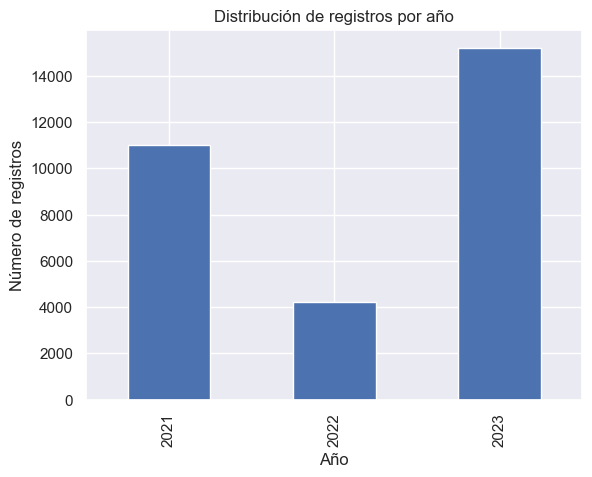

In [712]:
#GRÁFICOS
#Se analiza la distribución temporal del dataset para verificar la representatividad de cada año.
df_samur_features["anio"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de registros por año")
plt.xlabel("Año")
plt.ylabel("Número de registros")
plt.show()

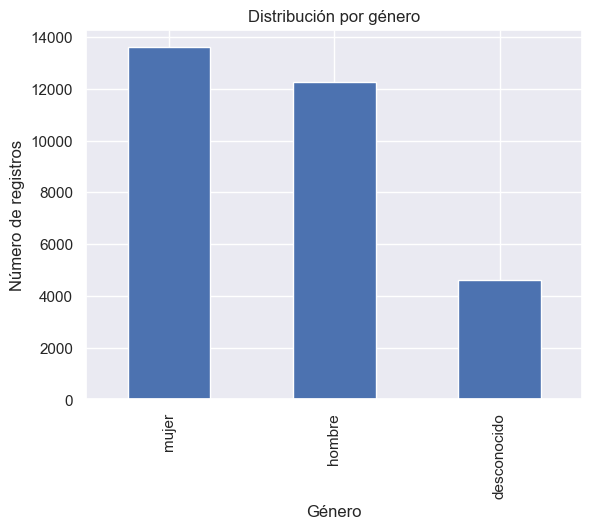

In [713]:
#GRÁFICO 2: Género para analizar el perfil del usuario
df_samur_features["genero"].value_counts().plot(kind="bar")
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Número de registros")
plt.show()

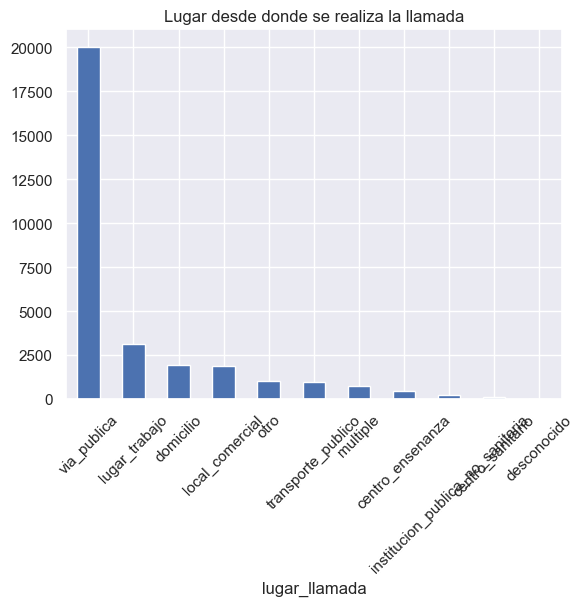

In [714]:
#GRÁFUCI 3: LUGAR DE LLAMADA
df_samur_features["lugar_llamada"].value_counts().plot(kind="bar")
plt.title("Lugar desde donde se realiza la llamada")
plt.xticks(rotation=45)
plt.show()

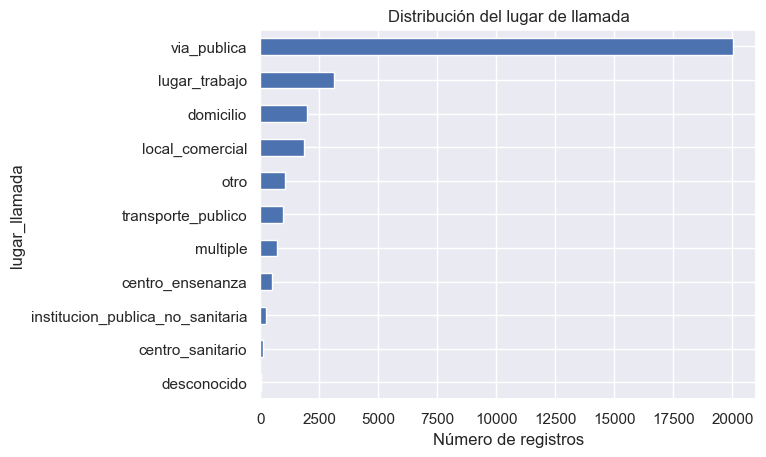

In [715]:
#GRAAFICO 3: lugar llamada para que se vea bien
df_samur_features["lugar_llamada"].value_counts().sort_values().plot(kind="barh")

plt.title("Distribución del lugar de llamada")
plt.xlabel("Número de registros")

plt.show()

In [716]:
#Se observa que la mayoría de las llamadas se realizan desde la vía pública, lo que resulta coherente con la naturaleza de las emergencias atendidas por el servicio SAMUR.

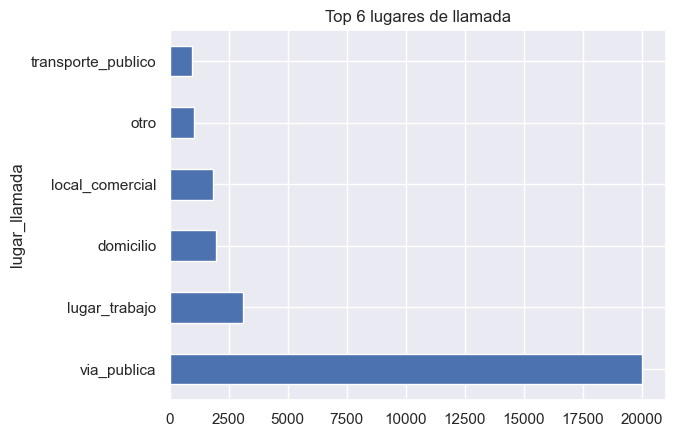

In [717]:
top = df_samur_features["lugar_llamada"].value_counts().nlargest(6)
top.plot(kind="barh")

plt.title("Top 6 lugares de llamada")
plt.show()

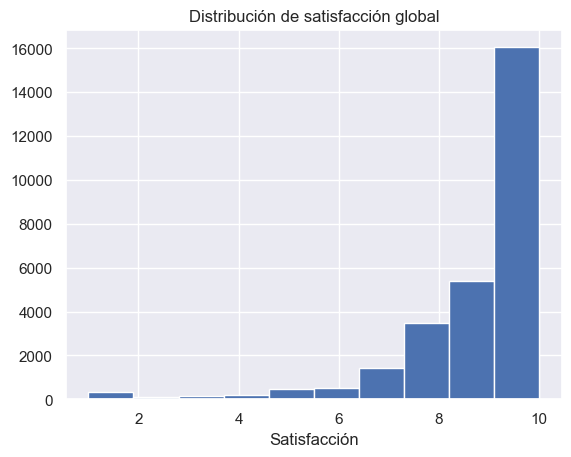

In [718]:
#GRAFICO 4: satisfacción global
df_samur_features["satisfaccion_global"].hist()
plt.title("Distribución de satisfacción global")
plt.xlabel("Satisfacción")
plt.show()

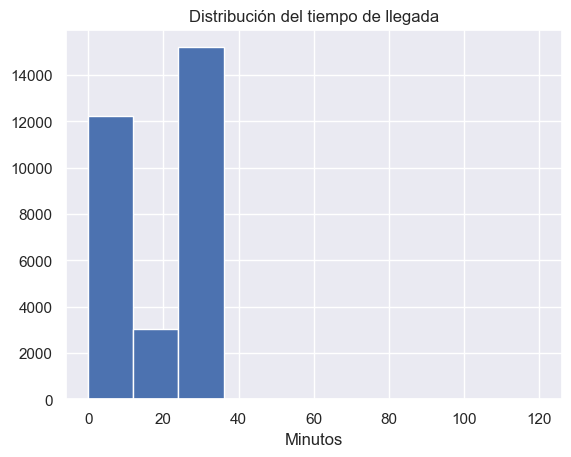

In [719]:
#GRAFICO 5: TIEMPO DE LLEGADA
df_samur_features["tiempo_llegada_final_min"].hist()
plt.title("Distribución del tiempo de llegada")
plt.xlabel("Minutos")
plt.show()

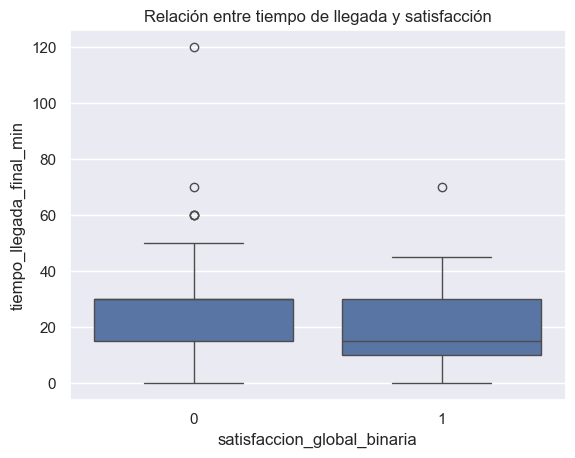

In [720]:
#GRÁFICO 6: RELACION SATISFACCION Y TIEMPO LLEGADA
sns.boxplot(
    x="satisfaccion_global_binaria",
    y="tiempo_llegada_final_min",
    data=df_samur_features
)
plt.title("Relación entre tiempo de llegada y satisfacción")
plt.show()

In [721]:
#observa una relación inversa entre el tiempo de llegada del servicio y la satisfacción global del usuario. Los registros con mayor nivel de satisfacción presentan tiempos de llegada significativamente menores en comparación con aquellos con menor satisfacción.

#Asimismo, los casos de baja satisfacción muestran una mayor dispersión en los tiempos, incluyendo valores extremos, lo que sugiere que la variabilidad y los retrasos prolongados impactan negativamente en la percepción del servicio.

In [726]:
#Se observa que los tiempos de llegada más bajos se asocian con mayores niveles de satisfacción, lo que sugiere que la rapidez del servicio es un factor clave en la percepción del usuario.

In [723]:
#Si bien no se puede afirmar causalidad directa, la evidencia apunta a una asociación relevante entre ambas variables.

In [724]:
#En promedio, los tiempos de llegada en los casos de alta satisfacción son inferiores a los de baja satisfacción.
df_samur_features.groupby("satisfaccion_global_binaria")["tiempo_llegada_final_min"].mean()

satisfaccion_global_binaria
0    23.880841
1    18.886972
Name: tiempo_llegada_final_min, dtype: float64

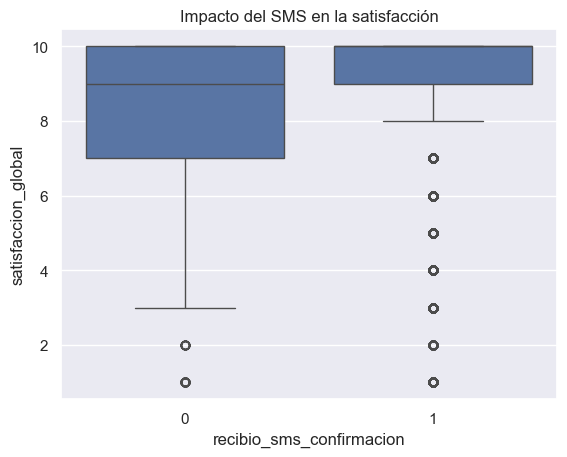

In [725]:
#GRAFICO 7: SMS vs SATISFACCION
sns.boxplot(
    x="recibio_sms_confirmacion",
    y="satisfaccion_global",
    data=df_samur_features
)
plt.title("Impacto del SMS en la satisfacción")
plt.show()

In [727]:
#se observa que los usuarios que recibieron un SMS de confirmación presentan, en general, niveles de satisfacción más elevados que aquellos que no lo recibieron. En particular, la mediana de satisfacción es superior en el grupo que recibió SMS, y la distribución se concentra en valores altos.

#Por el contrario, en los casos en los que no se envió SMS se aprecia una mayor dispersión, incluyendo valores de satisfacción significativamente más bajos. Esto sugiere que la comunicación mediante SMS contribuye positivamente a la percepción del servicio.

In [728]:
#Este resultado indica que la comunicación proactiva con el usuario, incluso mediante mecanismos simples como el envío de SMS, puede influir positivamente en su experiencia, constituyendo una mejora operativa de bajo coste con impacto relevante en la satisfacción.

In [729]:
#Este resultado indica que la comunicación proactiva con el usuario, incluso mediante mecanismos simples como el envío de SMS, puede influir positivamente en su experiencia, constituyendo una mejora operativa de bajo coste con impacto relevante en la satisfacción.

In [730]:
#en promedio, la satisfaccion es mayor en usuarios que recibieron SMS
df_samur_features.groupby("recibio_sms_confirmacion")["satisfaccion_global"].mean()

recibio_sms_confirmacion
0    8.057971
1    9.067722
Name: satisfaccion_global, dtype: float64

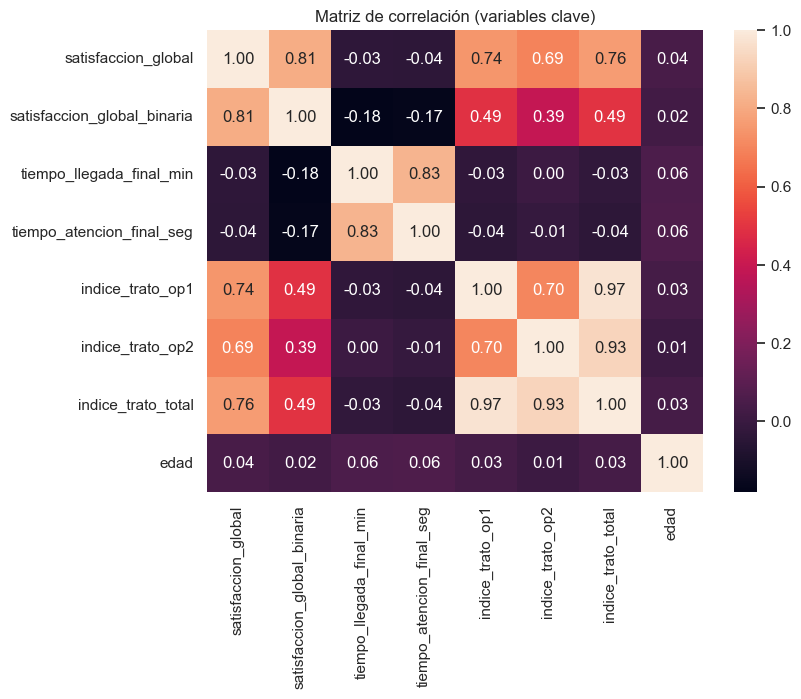

In [732]:
#GRAFICO 8:
cols_importantes = [
    "satisfaccion_global",
    "satisfaccion_global_binaria",
    "tiempo_llegada_final_min",
    "tiempo_atencion_final_seg",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total",
    "edad"
]

corr = df_samur_features[cols_importantes].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación (variables clave)")
plt.show()

In [733]:
#Se construyó una matriz de correlación entre las variables numéricas clave con el objetivo de identificar relaciones lineales entre ellas.

#Se observa una correlación positiva entre los índices de trato y la satisfacción global, lo que sugiere que la percepción del trato recibido influye directamente en la valoración del servicio.

#Asimismo, se identifica una correlación negativa entre los tiempos de respuesta y la satisfacción, indicando que mayores tiempos de espera se asocian a una peor experiencia del usuario.

#Por último, los distintos indicadores de trato presentan alta correlación entre sí, lo que evidencia consistencia en la medición de este constructo.

<Axes: >

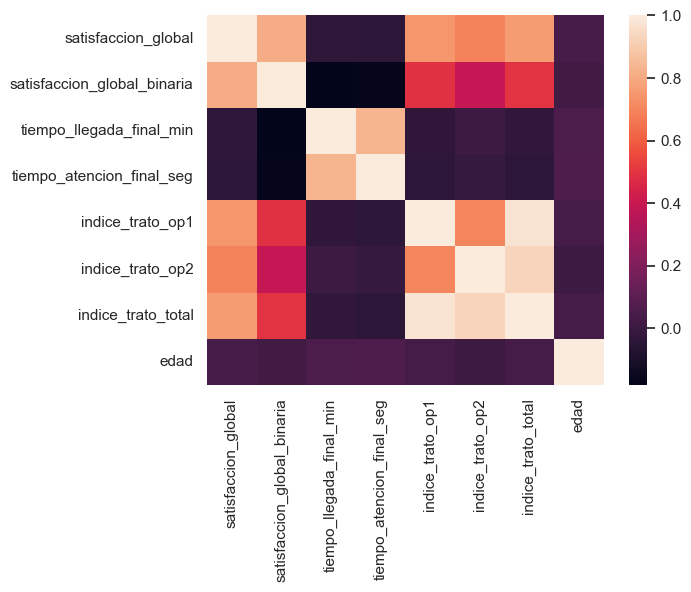

In [734]:
sns.heatmap(corr, annot=False)

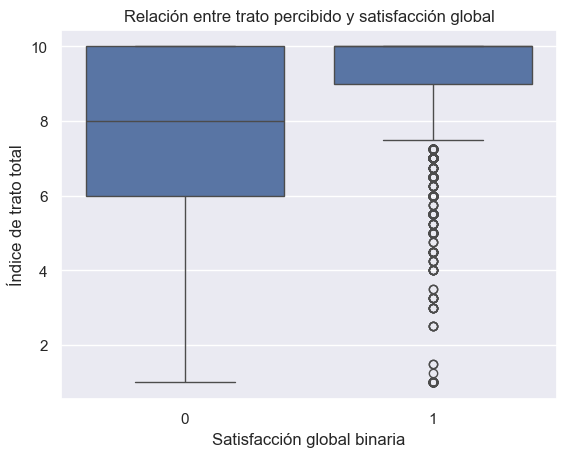

In [735]:
#GRAFICO 8
sns.boxplot(
    x="satisfaccion_global_binaria",
    y="indice_trato_total",
    data=df_samur_features
)

plt.title("Relación entre trato percibido y satisfacción global")
plt.xlabel("Satisfacción global binaria")
plt.ylabel("Índice de trato total")

plt.show()

In [736]:
from pathlib import Path

graficos = Path(r"C:\Users\marta\Downloads\TFG Business Analytics\03. BBDD\outputs\graficos")
graficos.mkdir(parents=True, exist_ok=True)

In [737]:
#Se observa una clara relación positiva entre el índice de trato percibido y la satisfacción global del usuario. Los casos con alta satisfacción presentan valores significativamente superiores en el índice de trato total, concentrándose en niveles cercanos al máximo.

#Por el contrario, los casos con menor satisfacción muestran una mayor dispersión y valores inferiores en el índice de trato, lo que sugiere una experiencia más heterogénea.

#Este resultado indica que la calidad percibida en la interacción con los operadores constituye uno de los principales determinantes de la satisfacción del usuario.

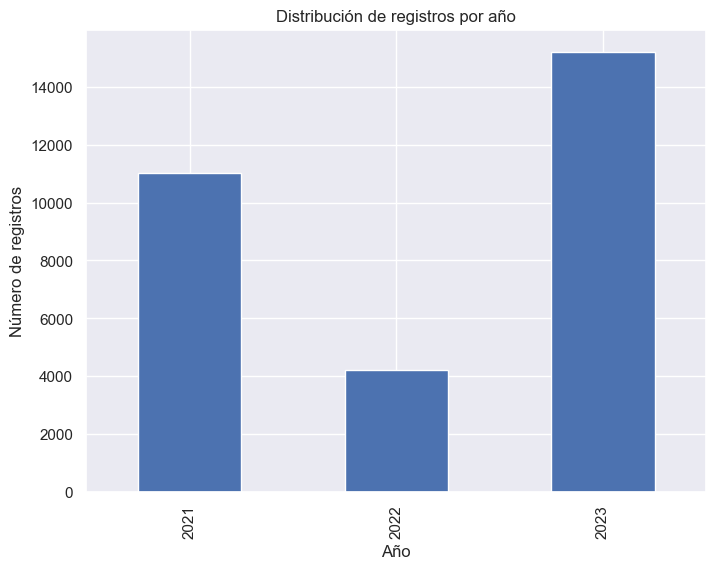

In [738]:
plt.figure(figsize=(8,6))
df_samur_features["anio"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de registros por año")
plt.xlabel("Año")
plt.ylabel("Número de registros")
plt.savefig(graficos / "registros_por_anio.png", dpi=300, bbox_inches="tight")
plt.show()

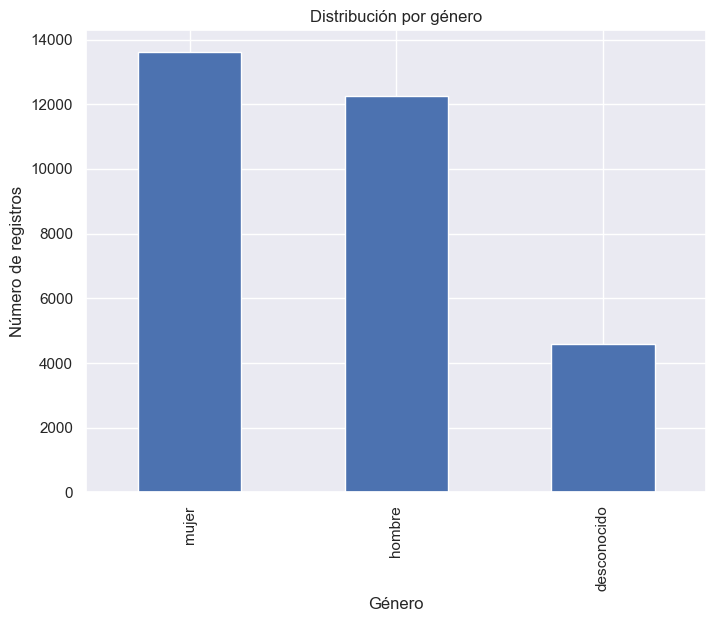

In [739]:
plt.figure(figsize=(8,6))
df_samur_features["genero"].value_counts().plot(kind="bar")
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Número de registros")
plt.savefig(graficos / "distribucion_genero.png", dpi=300, bbox_inches="tight")
plt.show()

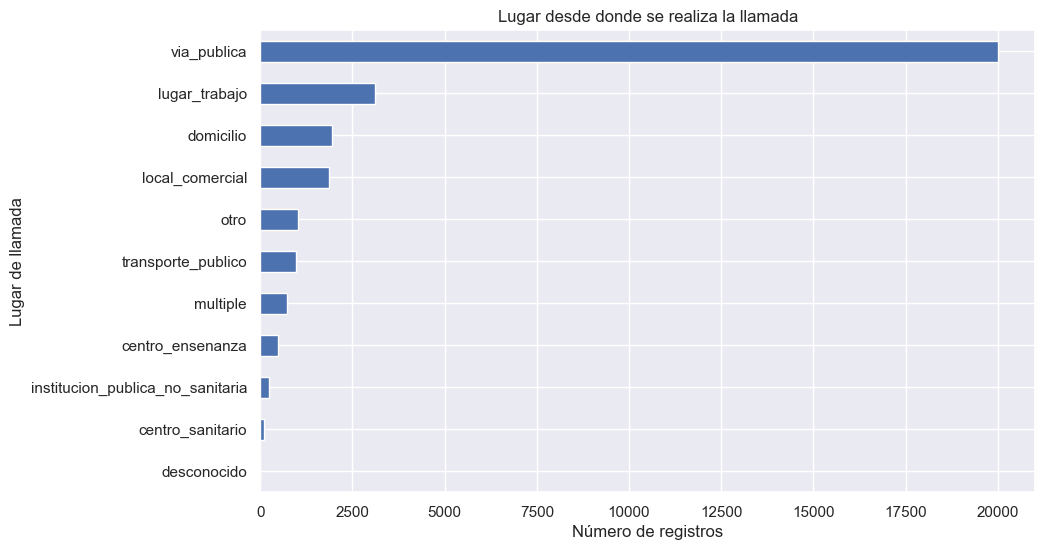

In [740]:
plt.figure(figsize=(10,6))
df_samur_features["lugar_llamada"].value_counts().sort_values().plot(kind="barh")
plt.title("Lugar desde donde se realiza la llamada")
plt.xlabel("Número de registros")
plt.ylabel("Lugar de llamada")
plt.savefig(graficos / "lugar_llamada.png", dpi=300, bbox_inches="tight")
plt.show()

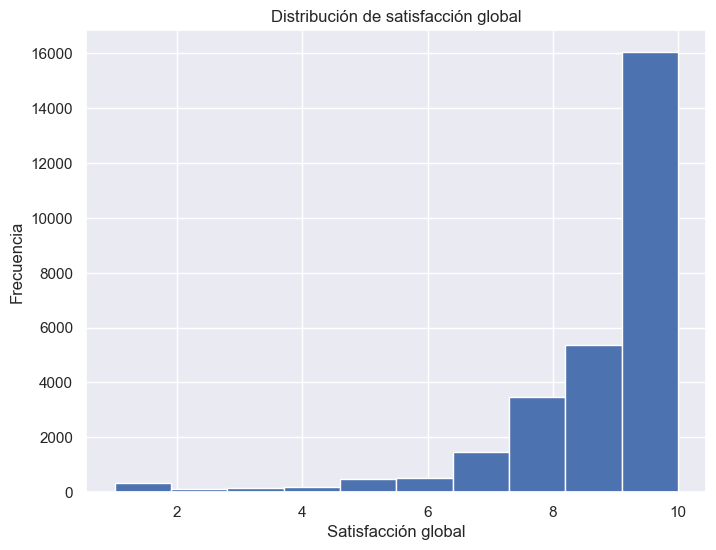

In [741]:
plt.figure(figsize=(8,6))
df_samur_features["satisfaccion_global"].hist()
plt.title("Distribución de satisfacción global")
plt.xlabel("Satisfacción global")
plt.ylabel("Frecuencia")
plt.savefig(graficos / "distribucion_satisfaccion_global.png", dpi=300, bbox_inches="tight")
plt.show()

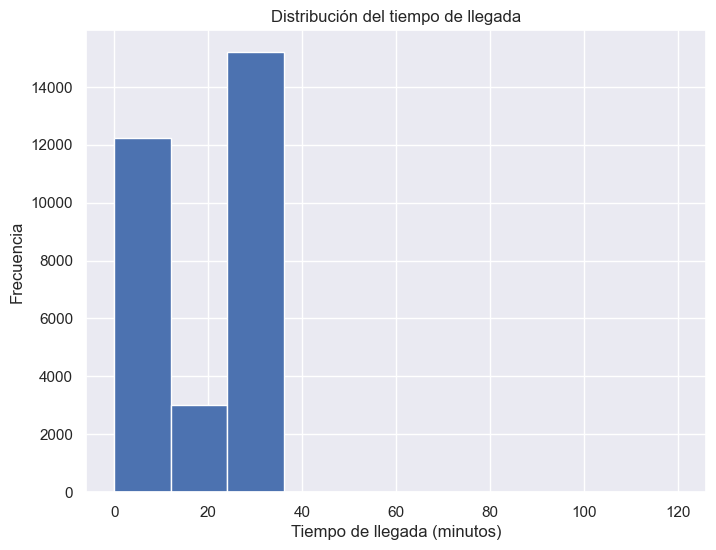

In [742]:
plt.figure(figsize=(8,6))
df_samur_features["tiempo_llegada_final_min"].hist()
plt.title("Distribución del tiempo de llegada")
plt.xlabel("Tiempo de llegada (minutos)")
plt.ylabel("Frecuencia")
plt.savefig(graficos / "distribucion_tiempo_llegada.png", dpi=300, bbox_inches="tight")
plt.show()

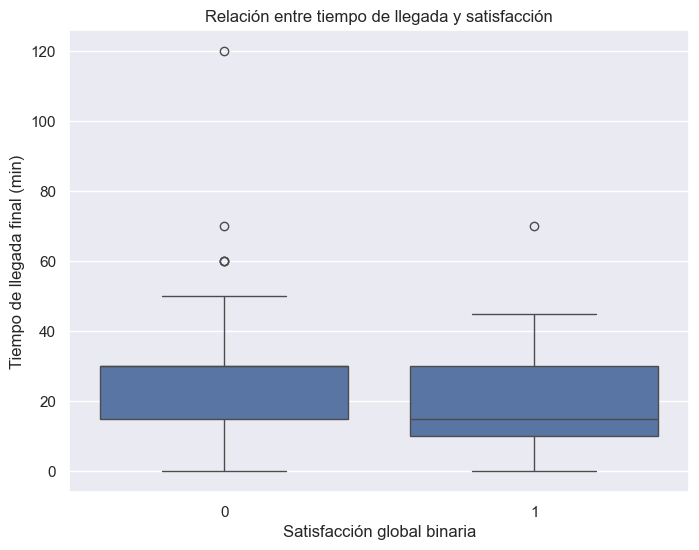

In [744]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x="satisfaccion_global_binaria",
    y="tiempo_llegada_final_min",
    data=df_samur_features
)
plt.title("Relación entre tiempo de llegada y satisfacción")
plt.xlabel("Satisfacción global binaria")
plt.ylabel("Tiempo de llegada final (min)")
plt.savefig(graficos / "tiempo_llegada_vs_satisfaccion.png", dpi=300, bbox_inches="tight")
plt.show()

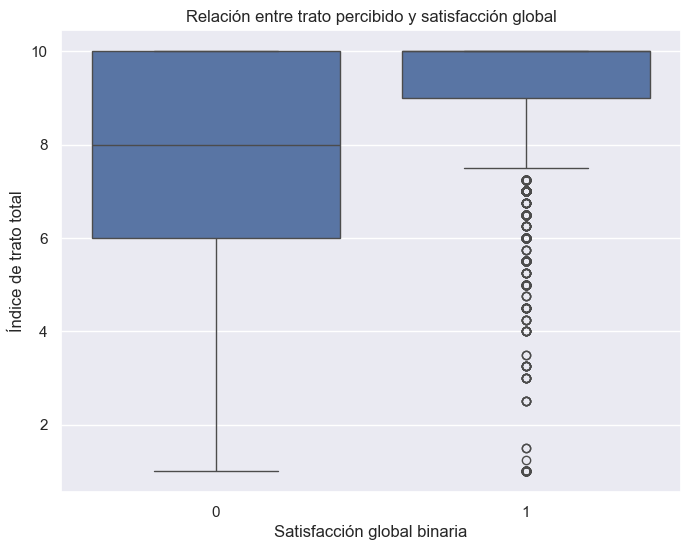

In [745]:
plt.figure(figsize=(8,6))
sns.boxplot(
    x="satisfaccion_global_binaria",
    y="indice_trato_total",
    data=df_samur_features
)
plt.title("Relación entre trato percibido y satisfacción global")
plt.xlabel("Satisfacción global binaria")
plt.ylabel("Índice de trato total")
plt.savefig(graficos / "trato_vs_satisfaccion.png", dpi=300, bbox_inches="tight")
plt.show()

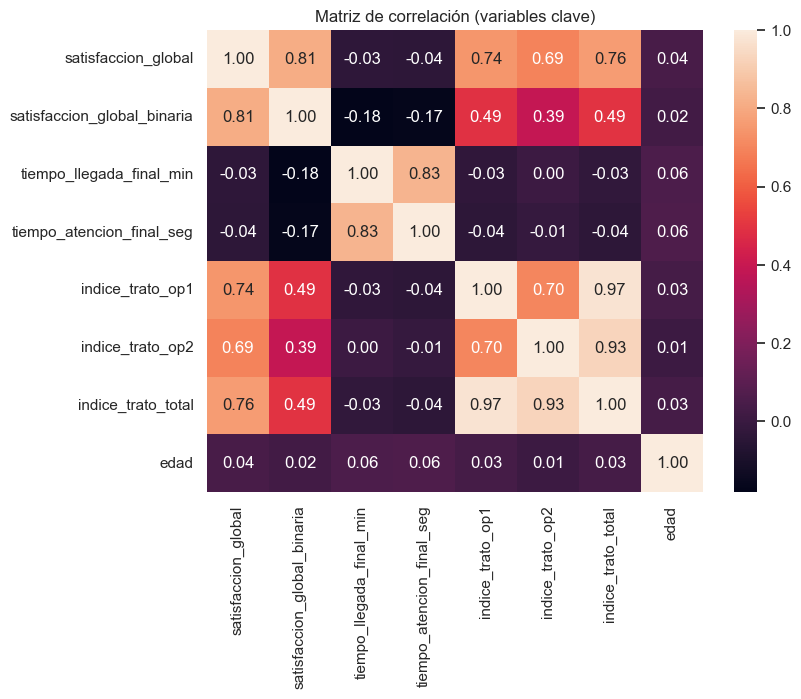

In [746]:
cols_importantes = [
    "satisfaccion_global",
    "satisfaccion_global_binaria",
    "tiempo_llegada_final_min",
    "tiempo_atencion_final_seg",
    "indice_trato_op1",
    "indice_trato_op2",
    "indice_trato_total",
    "edad"
]

corr = df_samur_features[cols_importantes].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación (variables clave)")
plt.savefig(graficos / "matriz_correlacion.png", dpi=300, bbox_inches="tight")
plt.show()

In [747]:
list(graficos.iterdir())

[WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/distribucion_genero.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/distribucion_satisfaccion_global.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/distribucion_tiempo_llegada.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/lugar_llamada.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/matriz_correlacion.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/registros_por_anio.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/tiempo_llegada_vs_satisfaccion.png'),
 WindowsPath('C:/Users/marta/Downloads/TFG Business Analytics/03. BBDD/outputs/graficos/trato_vs_satisfaccion.png')]